# MAGIC-I: TPMT/NUDT15 pharmacogenomics and MRD analysis

Analysis of the MAGIC-I paediatric leukaemia cohort, examining TPMT and NUDT15 expression in relation to lineage, MRD status, pathway activity, and germline genotype, with a partial replication comparison against the TARGET cohort. Companion analysis to the TARGET pipeline; thesis MRD/TPMT/NUDT15 focus is a related but separate workstream.

Raw sample-level identifiers, genotype calls, and clinical tables are not displayed inline — only de-identified summaries and plots. Full per-patient results are written out to CSV files listed at the point each is generated. Paths below point to this machine's local data locations and are not portable — see the note in the first code cell before pushing to GitHub.

#### Load manifest and filter for leukaemia ####

In [1]:
import pandas as pd
import os

tracking_path = "/Users/Meralle/Desktop/research data/magic-i-expression-data/MAGIC-I_Master-File_20260603.csv"

tracking = pd.read_csv(tracking_path)  
print(tracking.shape)
print(tracking.columns.tolist()[:10])
print(tracking['Study ID'].head(10))

(95, 87)
['Study ID', 'Disease', 'D/R', 'Sex', 'age', 'date diag/relapse', 'SNOMED CT', 'Disease Category', 'Pheno EGIL', 'Infiltration']
0    MA00001
1    MA00002
2    MA00003
3    MA00004
4    MA00005
5    MA00006
6    MA00007
7    MA00008
8    MA00009
9    MA00010
Name: Study ID, dtype: str


In [2]:
manifest_path = "/Users/Meralle/Desktop/research data/magic-i-expression-data/cohort-counts-manifest.csv"
manifest = pd.read_csv(manifest_path)

print(manifest.shape)
print(manifest.columns.tolist())
print(manifest['disease'].unique())

merged = manifest.merge(
    tracking,
    left_on='study_id',
    right_on='Study ID',
    how='left'
)
print(merged.shape)
print(f"Matched: {merged['Study ID'].notna().sum()} of {len(manifest)}")

(70, 4)
['sample', 'study_id', 'disease', 'rin']
<StringArray>
[                                                                                                    'T-ALL',
                                                                                                 'B-ALL, HH',
                                                                                                     'B-ALL',
                                       'Differentiating neuroblastoma with high mitotic karyorrhectic index',
                                                                                            'Hepatoblastoma',
                                                                                  'B-ALL, B-other, poor CAN',
                                                                                                     'T-LBL',
                                                                                           'B-ALL, IGH::MYC',
                                                         

In [3]:
# Clean whitespace in D/R column first
merged['D/R'] = merged['D/R'].str.strip()

# Restrict to diagnosis-only timepoint (excludes relapse samples)
manifest_diag = merged[merged['D/R'] == 'Diag'].copy()
print(f"Diagnosis-only: n={len(manifest_diag)} of {len(merged)}")

# Narrow definition: lymphoid leukaemias/lymphomas (ALL + LBL + MPAL) — excludes AML
leukaemia_keywords = ['ALL', 'MPAL', 'LBL']
mask_narrow = (
    manifest_diag['disease'].str.contains('|'.join(leukaemia_keywords), case=False, na=False)
    & ~manifest_diag['disease'].str.contains('AML', case=False, na=False)
)
leukaemia_manifest_narrow = manifest_diag[mask_narrow]

# Broad definition: narrow + AML
mask_broad = (
    manifest_diag['disease'].str.contains('|'.join(leukaemia_keywords + ['AML']), case=False, na=False)
)
leukaemia_manifest_broad = manifest_diag[mask_broad]

print("\nNARROW (ALL + LBL + MPAL, no AML, diagnosis-only):")
print(leukaemia_manifest_narrow[['sample', 'disease']])
print(f"{len(leukaemia_manifest_narrow)} of {len(manifest_diag)} samples\n")

print("BROAD (narrow + AML, diagnosis-only):")
print(leukaemia_manifest_broad[['sample', 'disease']])
print(f"{len(leukaemia_manifest_broad)} of {len(manifest_diag)} samples")

Diagnosis-only: n=60 of 70

NARROW (ALL + LBL + MPAL, no AML, diagnosis-only):
      sample                       disease
0   A0064549                         T-ALL
1   A0064557                     B-ALL, HH
2   A0065669                         B-ALL
5   A0065693      B-ALL, B-other, poor CAN
6   A0065700                         T-LBL
7   A0065708               B-ALL, IGH::MYC
9   A0065740                      DS-B-ALL
10  A0066061                     B-ALL, HH
11  A0066073                         T-ALL
12  A0066091                         T-ALL
17  A0069195                         B-ALL
18  A0069200                         T-LBL
19  A0069219                         T-ALL
20  A0069220                         B-ALL
21  A0069223                         B-LBL
22  A0069227                         B-ALL
23  A0069244                         B-ALL
24  A0069260                   infant MPAL
31  A0069747                     B-ALL, HH
33  A0069886                         T-ALL
34  A0069895      

In [4]:
counts_path = "/Users/Meralle/Desktop/research data/magic-i-expression-data/cohort-counts.tsv"
counts = pd.read_csv(counts_path, sep="\t", index_col=0)

print(counts.shape)
print(counts.columns[:10].tolist())
print(counts.index[:10].tolist())

(62700, 70)
['A0064549', 'A0064557', 'A0065669', 'A0065676', 'A0065692', 'A0065693', 'A0065700', 'A0065708', 'A0065724', 'A0065740']
['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938', 'ENSG00000000971', 'ENSG00000001036', 'ENSG00000001084', 'ENSG00000001167']


In [5]:
# Narrow leukaemia-only expression matrix
counts_leukaemia_narrow = counts[leukaemia_manifest_narrow['sample']]

# Broad (leukaemia + LBL) expression matrix
counts_leukaemia_broad = counts[leukaemia_manifest_broad['sample']]

print("Narrow:", counts_leukaemia_narrow.shape)
print("Broad:", counts_leukaemia_broad.shape)

# quick sanity check - same gene index as original, only columns changed
print(counts_leukaemia_narrow.index.equals(counts.index))

Narrow: (62700, 44)
Broad: (62700, 46)
True


In [6]:
out_dir = "/Users/Meralle/Desktop/research data/magic-i-expression-data/"

leukaemia_manifest_narrow.to_csv(out_dir + "leukaemia-manifest-narrow.csv", index=False)
leukaemia_manifest_broad.to_csv(out_dir + "leukaemia-manifest-broad.csv", index=False)
counts_leukaemia_narrow.to_csv(out_dir + "leukaemia-counts-narrow.tsv", sep="\t")
counts_leukaemia_broad.to_csv(out_dir + "leukaemia-counts-broad.tsv", sep="\t")

#### Cancer type and clinical outcome comparison ####

In [7]:
# TPMT and NUDT15 Ensembl gene IDs
gene_ids = {
    'TPMT': 'ENSG00000137364',
    'NUDT15': 'ENSG00000136159'
}

tpmt_nudt15 = counts_leukaemia_narrow.loc[list(gene_ids.values())].T
tpmt_nudt15.columns = list(gene_ids.keys())
tpmt_nudt15 = tpmt_nudt15.reset_index().rename(columns={'index': 'sample'})

# merge with disease/subtype labels
tpmt_nudt15 = tpmt_nudt15.merge(leukaemia_manifest_narrow[['sample', 'disease']], on='sample')

print(tpmt_nudt15)

      sample    TPMT  NUDT15                       disease
0   A0064549   741.0  1074.0                         T-ALL
1   A0064557   516.0   806.0                     B-ALL, HH
2   A0065669   891.0  1085.0                         B-ALL
3   A0065693   276.0   929.0      B-ALL, B-other, poor CAN
4   A0065700  1651.0  1446.0                         T-LBL
5   A0065708   120.0   113.0               B-ALL, IGH::MYC
6   A0065740   419.0   344.0                      DS-B-ALL
7   A0066061   469.0   473.0                     B-ALL, HH
8   A0066073   180.0   625.0                         T-ALL
9   A0066091   417.0   734.0                         T-ALL
10  A0069195   821.0   881.0                         B-ALL
11  A0069200  2131.0   807.0                         T-LBL
12  A0069219  2258.0  1041.0                         T-ALL
13  A0069220   968.0   459.0                         B-ALL
14  A0069223   475.0   342.0                         B-LBL
15  A0069227  1227.0  1366.0                         B-A

In [8]:
# collapse disease labels to broad lineage groups
def broad_lineage(d):
    d = d.upper()
    if 'MPAL' in d:
        return 'MPAL'
    if 'AML' in d:
        return 'AML'
    if 'T-ALL' in d or 'T-LBL' in d:
        return 'T-ALL'
    if 'B-ALL' in d or 'B, ALL' in d or 'DS-B-ALL' in d or 'B-LBL' in d:
        return 'B-ALL'
    return 'Other'

tpmt_nudt15['lineage'] = tpmt_nudt15['disease'].apply(broad_lineage)
print(tpmt_nudt15['lineage'].value_counts())

lineage
B-ALL    32
T-ALL    11
MPAL      1
Name: count, dtype: int64


In [9]:
nan_counts = counts_leukaemia_narrow.isna().sum()
print(nan_counts[nan_counts > 0])

nan_genes = counts_leukaemia_narrow.isna().any(axis=1).sum()
print(f"\n{nan_genes} genes have at least one NaN out of {counts_leukaemia_narrow.shape[0]} total")

A3870478    2405
A3872460    2405
A3873043    2405
dtype: int64

2405 genes have at least one NaN out of 62700 total


In [10]:
counts_clean = counts_leukaemia_narrow.dropna()
print(counts_clean.shape)
print(counts_clean.isna().sum().sum())  # should be 0

# now proceed to DESeq2
counts_for_deseq = counts_clean.T
counts_for_deseq = counts_for_deseq.astype(int)

metadata = tpmt_nudt15[['sample', 'lineage']].set_index('sample')
metadata = metadata.loc[counts_for_deseq.index]

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference

inference = DefaultInference(n_cpus=4)
dds = DeseqDataSet(
    counts=counts_for_deseq,
    metadata=metadata,
    design_factors='lineage',
    inference=inference
)

dds.deseq2()
dds.vst()
vst_counts = dds.layers['vst_counts']
vst_df = pd.DataFrame(vst_counts, index=counts_for_deseq.index, columns=counts_for_deseq.columns)

print(vst_df.shape)

(60295, 44)
0
Using None as control genes, passed at DeseqDataSet initialization


/var/folders/v_/j7694ws56vlb4hc0yb3b8xrr0000gn/T/ipykernel_63729/3174085926.py:16: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 3.40 seconds.

Fitting dispersion trend curve...
... done in 0.32 seconds.

Fitting MAP dispersions...
... done in 3.93 seconds.

Fitting LFCs...
... done in 3.11 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 25722 outlier genes.

Fitting dispersions...
... done in 1.52 seconds.

Fitting MAP dispersions...
... done in 1.64 seconds.

Fitting LFCs...
... done in 1.68 seconds.



Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 3.70 seconds.



(44, 60295)


In [11]:
tpmt_nudt15_vst = vst_df[['ENSG00000137364', 'ENSG00000136159']].copy()
tpmt_nudt15_vst.columns = ['TPMT_vst', 'NUDT15_vst']
tpmt_nudt15_vst = tpmt_nudt15_vst.reset_index().rename(columns={'index': 'sample'})
tpmt_nudt15_vst = tpmt_nudt15_vst.merge(tpmt_nudt15[['sample', 'lineage']], on='sample')

print(tpmt_nudt15_vst.sort_values('lineage'))

      sample   TPMT_vst  NUDT15_vst lineage
21  A0070733   9.419256    9.872900   B-ALL
23  A0070765   8.207644   10.294694   B-ALL
24  A0070812   9.266424    9.807646   B-ALL
25  A0070825   9.167561    9.612895   B-ALL
26  A0070829   8.303999    8.679369   B-ALL
27  A0070834   8.521036    9.599796   B-ALL
28  A0070857   9.386763   11.402219   B-ALL
31  A0070887   8.579984    8.970194   B-ALL
22  A0070740  10.029942    8.771654   B-ALL
32  A0070901   9.584223    9.299010   B-ALL
34  A0070912   8.720835    9.703931   B-ALL
35  A3870478  10.083957   10.408217   B-ALL
36  A3872452   8.953892    8.857094   B-ALL
38  A3873030  10.027645    8.543042   B-ALL
39  A3873043   9.365974   10.910509   B-ALL
40  A3873057   9.617884    9.703854   B-ALL
41  A3873421   9.458609   10.126381   B-ALL
33  A0070910   9.009711    9.448247   B-ALL
20  A0069895   9.595458    8.450737   B-ALL
43  A3873456   9.081740    9.791607   B-ALL
18  A0069747   9.860418    8.195221   B-ALL
1   A0064557   9.046809    9.687

In [12]:
from scipy import stats

# descriptive summary for all groups
summary = tpmt_nudt15_vst.groupby('lineage')[['TPMT_vst', 'NUDT15_vst']].agg(['mean', 'std', 'count'])
print(summary)

# formal test: B-ALL vs T-ALL only (adequate n)
ball = tpmt_nudt15_vst[tpmt_nudt15_vst['lineage'] == 'B-ALL']
tall = tpmt_nudt15_vst[tpmt_nudt15_vst['lineage'] == 'T-ALL']

tpmt_stat, tpmt_p = stats.mannwhitneyu(ball['TPMT_vst'], tall['TPMT_vst'])
nudt15_stat, nudt15_p = stats.mannwhitneyu(ball['NUDT15_vst'], tall['NUDT15_vst'])

print(f"\nTPMT B-ALL vs T-ALL: p={tpmt_p:.4f}")
print(f"NUDT15 B-ALL vs T-ALL: p={nudt15_p:.4f}")

          TPMT_vst                 NUDT15_vst                
              mean       std count       mean       std count
lineage                                                      
B-ALL     9.248521  0.572841    32   9.448158  0.739954    32
MPAL     11.387193       NaN     1   9.476792       NaN     1
T-ALL     9.147857  1.030277    11   9.473871  0.581195    11

TPMT B-ALL vs T-ALL: p=0.7279
NUDT15 B-ALL vs T-ALL: p=0.9445


**TPMT** - MPAL has the highest mean (11.39, n=1, single sample so no meaningful spread), followed by B-ALL (9.25) and T-ALL(9.15), which overlap substantially given their spread (std 0.58 and 1.03 respectively). The B-ALL vs T-ALL difference is not significant (p=0.7279).

**NUDT15**- all three groups sit in narrow band (~9.45-9.48), no meaningful separation by lineage at all. Tracks with the TARGET result that NUDT15 shows no significant MRD association either. NUDT15 may just be more lineage/outcome invariant in general.


In [13]:
print(f"manifest rows: {len(manifest)}, unique samples: {manifest['sample'].nunique()}, unique study IDs: {manifest['study_id'].nunique()}")


manifest rows: 70, unique samples: 70, unique study IDs: 70


In [14]:
print(leukaemia_manifest_narrow['Fusion'].value_counts(dropna=False))

Fusion
NaN                              27
ETV6::RUNX1                       3
TCF3::PBX1                        3
IGH::MYC                          1
CRLF2r                            1
PARG::BMS1 (ex4::ex6): Tier 3     1
KMT2A::(partner?)                 1
No                                1
KMT2A::AFF1                       1
STIL::TAL1                        1
TCF3::PBX1                        1
P2RY8::CRLF2                      1
NRG1::LINC01684 (?) DUX4r(?)      1
TCF3::(partner?)                  1
Name: count, dtype: int64


In [15]:
print(leukaemia_manifest_narrow['Fusion'].unique())

# check if NaN correlates with FISH/array/NGS not being done at all
print(leukaemia_manifest_narrow[leukaemia_manifest_narrow['Fusion'].isna()][['FISH SOC', 'array SOC', 'RNA NGS SOC', 'DNA NGS SOC']].apply(pd.Series.value_counts))

<StringArray>
[                            nan,                   'ETV6::RUNX1',
                      'IGH::MYC',                        'CRLF2r',
                   'TCF3::PBX1 ', 'PARG::BMS1 (ex4::ex6): Tier 3',
             'KMT2A::(partner?)',                            'No',
                   'KMT2A::AFF1',                    'STIL::TAL1',
                    'TCF3::PBX1',                  'P2RY8::CRLF2',
  'NRG1::LINC01684 (?) DUX4r(?)',              'TCF3::(partner?)']
Length: 14, dtype: str
   FISH SOC  array SOC  RNA NGS SOC  DNA NGS SOC
N       NaN        NaN         27.0         27.0
Y      27.0       27.0          NaN          NaN


In [16]:
fusion_clean = leukaemia_manifest_narrow['Fusion'].str.strip()
fusion_clean = fusion_clean.replace({'No': 'Fusion-negative', 'no fusion': 'Fusion-negative'})

leukaemia_manifest_narrow['fusion_clean'] = fusion_clean
print(leukaemia_manifest_narrow['fusion_clean'].value_counts(dropna=False))

fusion_clean
NaN                              27
TCF3::PBX1                        4
ETV6::RUNX1                       3
IGH::MYC                          1
CRLF2r                            1
PARG::BMS1 (ex4::ex6): Tier 3     1
KMT2A::(partner?)                 1
Fusion-negative                   1
KMT2A::AFF1                       1
STIL::TAL1                        1
P2RY8::CRLF2                      1
NRG1::LINC01684 (?) DUX4r(?)      1
TCF3::(partner?)                  1
Name: count, dtype: int64


In [17]:
subtype_summary = leukaemia_manifest_narrow[['sample', 'fusion_clean']].merge(
    tpmt_nudt15_vst[['sample', 'TPMT_vst', 'NUDT15_vst']], on='sample'
)

# groups with n>=2
counts = subtype_summary['fusion_clean'].value_counts()
adequate_groups = counts[counts >= 2].index

print("Groups with n>=2 samples:")
print(subtype_summary[subtype_summary['fusion_clean'].isin(adequate_groups)]
      .groupby('fusion_clean')[['TPMT_vst', 'NUDT15_vst']].agg(['mean', 'std', 'count']))

print("\nAll samples (for appendix):")
print(subtype_summary.sort_values('fusion_clean'))

Groups with n>=2 samples:
              TPMT_vst                NUDT15_vst                
                  mean      std count       mean       std count
fusion_clean                                                    
ETV6::RUNX1   9.284471  0.12673     3   9.710457  0.227203     3
TCF3::PBX1    9.412936  0.63390     4   9.841975  1.059199     4

All samples (for appendix):
      sample                   fusion_clean   TPMT_vst  NUDT15_vst
6   A0065740                         CRLF2r   8.661171    8.378538
2   A0065669                    ETV6::RUNX1   9.167731    9.450824
24  A0070812                    ETV6::RUNX1   9.266424    9.807646
21  A0070733                    ETV6::RUNX1   9.419256    9.872900
15  A0069227                Fusion-negative   9.742346    9.896746
5   A0065708                       IGH::MYC   9.871526    9.785050
14  A0069223              KMT2A::(partner?)   9.309176    8.837420
17  A0069260                    KMT2A::AFF1  11.387193    9.476792
41  A3873421   NR

In [18]:
from scipy.stats import pearsonr, spearmanr

# TPMT-NUDT15 correlation across all 46 samples
r, p = spearmanr(tpmt_nudt15_vst['TPMT_vst'], tpmt_nudt15_vst['NUDT15_vst'])
print(f"TPMT-NUDT15 Spearman correlation: rho={r:.3f}, p={p:.4f}")

print(leukaemia_manifest_narrow[['sample', 'D/R', 'age', 'Sex']].head(20))

print("\nD/R value counts:")
print(leukaemia_manifest_narrow['D/R'].value_counts(dropna=False))

print("\nAge summary:")
print(leukaemia_manifest_narrow['age'].describe())

TPMT-NUDT15 Spearman correlation: rho=0.021, p=0.8924
      sample   D/R   age Sex
0   A0064549  Diag   5.8   M
1   A0064557  Diag   6.9   F
2   A0065669  Diag   5.8   M
5   A0065693  Diag   4.6   F
6   A0065700  Diag  12.2   M
7   A0065708  Diag  10.9   F
9   A0065740  Diag   5.1   F
10  A0066061  Diag   4.7   M
11  A0066073  Diag   8.2   M
12  A0066091  Diag   9.1   M
17  A0069195  Diag   4.4   M
18  A0069200  Diag  15.4   M
19  A0069219  Diag  11.1   M
20  A0069220  Diag   3.1   F
21  A0069223  Diag   2.5   M
22  A0069227  Diag   4.6   M
23  A0069244  Diag   1.8   M
24  A0069260  Diag   0.4   F
31  A0069747  Diag  11.4   F
33  A0069886  Diag  10.0   M

D/R value counts:
D/R
Diag    44
Name: count, dtype: int64

Age summary:
count    44.000000
mean      7.043182
std       3.975881
min       0.400000
25%       4.550000
50%       6.000000
75%      10.225000
max      15.700000
Name: age, dtype: float64


TPMT-NUDT15 correlation: essentially 0 (rho = 0.021, p=0.8924). The two genes don't co-vary at all in this cohort. Confirmst they're regulating independently, consistent of them being separate genes in the thiopurine pathway. 


In [19]:
# age correlation with TPMT/NUDT15
age_analysis = leukaemia_manifest_narrow[['sample', 'age']].merge(tpmt_nudt15_vst[['sample','TPMT_vst','NUDT15_vst']], on='sample')

r_tpmt, p_tpmt = spearmanr(age_analysis['age'], age_analysis['TPMT_vst'])
r_nudt, p_nudt = spearmanr(age_analysis['age'], age_analysis['NUDT15_vst'])
print(f"\nAge vs TPMT: rho={r_tpmt:.3f}, p={p_tpmt:.4f}")
print(f"Age vs NUDT15: rho={r_nudt:.3f}, p={p_nudt:.4f}")


Age vs TPMT: rho=0.081, p=0.6019
Age vs NUDT15: rho=0.179, p=0.2447


In [20]:
# library size = total counts per sample
lib_sizes = counts_leukaemia_narrow.sum(axis=0)
print(lib_sizes.describe())

# correlate raw TPMT/NUDT15 counts with library size (before VST correction)
raw_tpmt = counts_leukaemia_narrow.loc['ENSG00000137364']
raw_nudt15 = counts_leukaemia_narrow.loc['ENSG00000136159']

r_lib_tpmt, p_lib_tpmt = spearmanr(lib_sizes, raw_tpmt)
r_lib_nudt15, p_lib_nudt15 = spearmanr(lib_sizes, raw_nudt15)
print(f"\nLibrary size vs raw TPMT: rho={r_lib_tpmt:.3f}, p={p_lib_tpmt:.4f}")
print(f"Library size vs raw NUDT15: rho={r_lib_nudt15:.3f}, p={p_lib_nudt15:.4f}")

count    4.400000e+01
mean     5.464582e+07
std      2.519020e+07
min      1.176645e+07
25%      4.129232e+07
50%      5.402789e+07
75%      6.768266e+07
max      1.567508e+08
dtype: float64

Library size vs raw TPMT: rho=0.611, p=0.0000
Library size vs raw NUDT15: rho=0.690, p=0.0000


In [21]:
r_lib_tpmt_vst, p_lib_tpmt_vst = spearmanr(lib_sizes, vst_df['ENSG00000137364'])
r_lib_nudt15_vst, p_lib_nudt15_vst = spearmanr(lib_sizes, vst_df['ENSG00000136159'])
print(f"Library size vs VST TPMT: rho={r_lib_tpmt_vst:.3f}, p={p_lib_tpmt_vst:.4f}")
print(f"Library size vs VST NUDT15: rho={r_lib_nudt15_vst:.3f}, p={p_lib_nudt15_vst:.4f}")

Library size vs VST TPMT: rho=-0.084, p=0.5884
Library size vs VST NUDT15: rho=0.163, p=0.2906


In [22]:
print(lib_sizes.sort_values().head(3))

A0065708    11766454.0
A3872452    20642331.0
A3873456    22689888.0
dtype: float64


In [23]:
# Derive QC exclusions from  QC conclusion values
print(leukaemia_manifest_narrow[['sample', 'QC conclusion']].drop_duplicates())

# Samples with an explicit fail flag
qc_fail_samples = leukaemia_manifest_narrow[
    leukaemia_manifest_narrow['QC conclusion'].str.contains('FAIL', case=False, na=False)
]['sample'].tolist()

# Samples with an ambiguous/borderline flag — review separately, don't auto-exclude
qc_borderline_samples = leukaemia_manifest_narrow[
    leukaemia_manifest_narrow['QC conclusion'].isin(['No great'])
]['sample'].tolist()

print(f"\nQC fail samples (derived): {qc_fail_samples}")
print(f"QC borderline samples (derived): {qc_borderline_samples}")

      sample QC conclusion
0   A0064549           NaN
1   A0064557           NaN
2   A0065669           NaN
5   A0065693           NaN
6   A0065700           NaN
7   A0065708           NaN
9   A0065740           NaN
10  A0066061           NaN
11  A0066073           NaN
12  A0066091           NaN
17  A0069195           NaN
18  A0069200           NaN
19  A0069219           NaN
20  A0069220           NaN
21  A0069223          PASS
22  A0069227           NaN
23  A0069244           NaN
24  A0069260           NaN
31  A0069747           NaN
33  A0069886           NaN
34  A0069895           NaN
35  A0070733           NaN
36  A0070740           NaN
37  A0070765           NaN
41  A0070812           NaN
44  A0070825           NaN
45  A0070829           NaN
47  A0070834           NaN
49  A0070857           NaN
51  A0070863           NaN
52  A0070873           NaN
53  A0070887           NaN
55  A0070901           NaN
56  A0070910           NaN
57  A0070912           NaN
58  A3870478         PASS?
5

In [24]:
def broad_lineage(d):
    d = d.upper()
    if 'MPAL' in d: return 'MPAL'
    if 'AML' in d: return 'AML'
    if 'T-ALL' in d or 'T-LBL' in d: return 'T-ALL'
    if 'B-ALL' in d or 'B, ALL' in d or 'DS-B-ALL' in d or 'B-LBL' in d: return 'B-ALL'
    return 'Other'

leukaemia_manifest_narrow['lineage'] = leukaemia_manifest_narrow['disease'].apply(broad_lineage)
print(leukaemia_manifest_narrow['lineage'].value_counts())

qc_exclude_strict = ['A3873043']  # confirmed QC failure ("FAILED?")

tpmt_nudt15_vst_strict = tpmt_nudt15_vst[~tpmt_nudt15_vst['sample'].isin(qc_exclude_strict)]

lineage
B-ALL    32
T-ALL    11
MPAL      1
Name: count, dtype: int64


In [25]:
tpmt_nudt15_vst_strict = tpmt_nudt15_vst[~tpmt_nudt15_vst['sample'].isin(qc_exclude_strict)]

# 1. lineage comparison
summary_strict = tpmt_nudt15_vst_strict.groupby('lineage')[['TPMT_vst', 'NUDT15_vst']].agg(['mean','std','count'])
print("Lineage summary (strict QC):")
print(summary_strict)

ball = tpmt_nudt15_vst_strict[tpmt_nudt15_vst_strict['lineage']=='B-ALL']
tall = tpmt_nudt15_vst_strict[tpmt_nudt15_vst_strict['lineage']=='T-ALL']
tpmt_stat, tpmt_p = stats.mannwhitneyu(ball['TPMT_vst'], tall['TPMT_vst'])
nudt15_stat, nudt15_p = stats.mannwhitneyu(ball['NUDT15_vst'], tall['NUDT15_vst'])
print(f"\nTPMT B-ALL vs T-ALL (strict): p={tpmt_p:.4f}")
print(f"NUDT15 B-ALL vs T-ALL (strict): p={nudt15_p:.4f}")

# 2. TPMT-NUDT15 correlation
r, p = spearmanr(tpmt_nudt15_vst_strict['TPMT_vst'], tpmt_nudt15_vst_strict['NUDT15_vst'])
print(f"\nTPMT-NUDT15 correlation (strict): rho={r:.3f}, p={p:.4f}")

# 3. age correlation
age_strict = leukaemia_manifest_narrow[~leukaemia_manifest_narrow['sample'].isin(qc_exclude_strict)][['sample','age']].merge(
    tpmt_nudt15_vst_strict[['sample','TPMT_vst','NUDT15_vst']], on='sample'
)
r_a, p_a = spearmanr(age_strict['age'], age_strict['TPMT_vst'])
r_n, p_n = spearmanr(age_strict['age'], age_strict['NUDT15_vst'])
print(f"\nAge vs TPMT (strict): rho={r_a:.3f}, p={p_a:.4f}")
print(f"Age vs NUDT15 (strict): rho={r_n:.3f}, p={p_n:.4f}")

Lineage summary (strict QC):
          TPMT_vst                 NUDT15_vst                
              mean       std count       mean       std count
lineage                                                      
B-ALL     9.244732  0.581902    31   9.400985  0.701571    31
MPAL     11.387193       NaN     1   9.476792       NaN     1
T-ALL     9.147857  1.030277    11   9.473871  0.581195    11

TPMT B-ALL vs T-ALL (strict): p=0.7530
NUDT15 B-ALL vs T-ALL (strict): p=0.8190

TPMT-NUDT15 correlation (strict): rho=0.012, p=0.9372

Age vs TPMT (strict): rho=0.083, p=0.5957
Age vs NUDT15 (strict): rho=0.180, p=0.2475


In [26]:
check_cols = ['Infiltration', 'Sex', 'Disease Category', 'SNOMED CT', 'PMC /RNAseq', 'PMC WES']
for col in check_cols:
    print(f"=== {col} ===")
    print(leukaemia_manifest_narrow[col].value_counts(dropna=False).head(10))
    print()

=== Infiltration ===
Infiltration
NaN                      33
88%                       2
65% (DNA, suspension)     1
`                         1
79%                       1
50%                       1
>95%                      1
81%                       1
>84% (no flow)            1
>90% (no flow)            1
Name: count, dtype: int64

=== Sex ===
Sex
M    26
F    18
Name: count, dtype: int64

=== Disease Category ===
Disease Category
NaN                     12
HH                       6
High Hyperdiploidy       4
ER                       2
TCF3::PBX1 (B-other)     2
MYCr                     1
IGH::MYC                 1
T-LBL with CMMRD         1
T/NK                     1
KMT2r B-LBL              1
Name: count, dtype: int64

=== SNOMED CT ===
SNOMED CT
NaN          31
838346000     5
277575008     3
277571004     2
128808004     1
838341005     1
397347001     1
Name: count, dtype: int64

=== PMC /RNAseq ===
PMC /RNAseq
N    43
Y     1
Name: count, dtype: int64

=== PMC WES ===
PMC

In [27]:
print(f"PMC RNAseq flagged: {(leukaemia_manifest_narrow['PMC /RNAseq'] == 'Y').sum()} samples")
print(f"PMC WES flagged: {(leukaemia_manifest_narrow['PMC WES'] == 'Y (necker)').sum()} samples")


PMC RNAseq flagged: 1 samples
PMC WES flagged: 1 samples


#### ALLSorts and Polonen Subtyping ####

In [28]:
# Build ALLSorts input from the corrected B-ALL subset
ball_samples = leukaemia_manifest_narrow[leukaemia_manifest_narrow['lineage'] == 'B-ALL']['sample']
allsorts_input_magici = counts_leukaemia_narrow[ball_samples].T
allsorts_input_magici.to_csv("/Users/Meralle/PyCharmMiscProject/ALLSorts/allsorts_input_magici.csv")

print("ALLSorts input shape:", allsorts_input_magici.shape)

ALLSorts input shape: (32, 62700)


#### MRD data merge with MAGIC-I VST ####

In [29]:
#attach study_id to full_df
full_df = tpmt_nudt15_vst.merge(manifest[['sample', 'study_id']], on='sample', how='left')

print(full_df['study_id'].isna().sum(), "samples missing study_id")
print(full_df[['sample', 'study_id']].head())

0 samples missing study_id
     sample study_id
0  A0064549  MA00068
1  A0064557  MA00077
2  A0065669  MA00050
3  A0065693  MA00073
4  A0065700  MA00067


In [30]:
mrd_df = pd.read_excel("/Users/Meralle/Desktop/research data/MRD_MAGIC-I.xlsx")

full_df = full_df.merge(
    mrd_df,
    left_on='study_id',
    right_on='MAGIC-I inclusion',
    how='left'
)

print(f"Matched: {full_df['MAGIC-I inclusion'].notna().sum()} of {len(full_df)}")
print(full_df[['sample', 'study_id', 'Diag/Rel', 'Post-induction (Diag)', 'Post-Consolidation (Diag)', 'Post-induction (Relapse)']].head(10))

Matched: 44 of 44
     sample study_id Diag/Rel                   Post-induction (Diag)  \
0  A0064549  MA00068        D                                  0.0006   
1  A0064557  MA00077        D                                 0.00002   
2  A0065669  MA00050        D                                 0.00002   
3  A0065693  MA00073        D                                 0.00006   
4  A0065700  MA00067        D  good clinical response (no MRD marker)   
5  A0065708  MA00075        D                                 0.00001   
6  A0065740  MA00079        D                                   0.034   
7  A0066061  MA00081        D                                 0.00002   
8  A0066073  MA00087        D                                  0.0003   
9  A0066091  MA00080        D                                   0.057   

  Post-Consolidation (Diag) Post-induction (Relapse)  
0                       NaN                      NaN  
1              Not detected                      NaN  
2            

In [31]:
def clean_mrd(val):
    if pd.isna(val):
        return None
    if isinstance(val, str):
        val_lower = val.strip().lower()
        if val_lower in ['not detected', 'nd']:
            return 0.0
        try:
            return float(val)
        except ValueError:
            return None  # catches non-numeric notes like "Blina"
    return val

full_df['mrd_value'] = full_df['Post-induction (Diag)'].apply(clean_mrd)

print(full_df[['sample', 'study_id', 'Post-induction (Diag)', 'mrd_value']].head(15))
print(f"\nUsable MRD values: {full_df['mrd_value'].notna().sum()} of {len(full_df)}")
print(f"Non-numeric/dropped entries: {full_df[full_df['Post-induction (Diag)'].notna() & full_df['mrd_value'].isna()]['Post-induction (Diag)'].unique()}")

      sample study_id                   Post-induction (Diag)  mrd_value
0   A0064549  MA00068                                  0.0006    0.00060
1   A0064557  MA00077                                 0.00002    0.00002
2   A0065669  MA00050                                 0.00002    0.00002
3   A0065693  MA00073                                 0.00006    0.00006
4   A0065700  MA00067  good clinical response (no MRD marker)        NaN
5   A0065708  MA00075                                 0.00001    0.00001
6   A0065740  MA00079                                   0.034    0.03400
7   A0066061  MA00081                                 0.00002    0.00002
8   A0066073  MA00087                                  0.0003    0.00030
9   A0066091  MA00080                                   0.057    0.05700
10  A0069195  MA00057                            Not detected    0.00000
11  A0069200  MA00022  good clinical response (no MRD marker)        NaN
12  A0069219  MA00036                              

This step: 
- converted "not detected"/"ND" -> 0.0 (undetectable MRD is treated as 0, consisted with how TARGET data was handled)
- tried to parse any other string as a float
- flagged anything that doesn't parse (e.g. "Blina" which seems lika  drug/treatment annotation and not an MRD value) 


In [32]:
#generate status column using same standard threshold as TARGET (MRD pos ≥ 0.01%)
full_df['mrd_status'] = full_df['mrd_value'].apply(
    lambda x: 'positive' if pd.notna(x) and x >= 0.0001 else ('negative' if pd.notna(x) else None)
)

print(full_df[['sample', 'study_id', 'mrd_value', 'mrd_status']].head(15))
print(f"\nMRD status counts:\n{full_df['mrd_status'].value_counts(dropna=False)}")

      sample study_id  mrd_value mrd_status
0   A0064549  MA00068    0.00060   positive
1   A0064557  MA00077    0.00002   negative
2   A0065669  MA00050    0.00002   negative
3   A0065693  MA00073    0.00006   negative
4   A0065700  MA00067        NaN        NaN
5   A0065708  MA00075    0.00001   negative
6   A0065740  MA00079    0.03400   positive
7   A0066061  MA00081    0.00002   negative
8   A0066073  MA00087    0.00030   positive
9   A0066091  MA00080    0.05700   positive
10  A0069195  MA00057    0.00000   negative
11  A0069200  MA00022        NaN        NaN
12  A0069219  MA00036    0.03000   positive
13  A0069220  MA00043    0.00000   negative
14  A0069223  MA00011        NaN        NaN

MRD status counts:
mrd_status
negative    25
positive    16
NaN          3
Name: count, dtype: int64


In [33]:
#exclude unmatched samples for MRD analyses
mrd_analysis_df = full_df[full_df['mrd_status'].notna()].copy()
print(f"Samples for MRD analysis: {len(mrd_analysis_df)}")
print(mrd_analysis_df['mrd_status'].value_counts())

Samples for MRD analysis: 41
mrd_status
negative    25
positive    16
Name: count, dtype: int64


In [34]:
#Mann-Whitney U test - TPMT/NUDT15 vs MRD status (same as TARGET)
from scipy.stats import mannwhitneyu

pos = mrd_analysis_df[mrd_analysis_df['mrd_status'] == 'positive']
neg = mrd_analysis_df[mrd_analysis_df['mrd_status'] == 'negative']

tpmt_stat, tpmt_p = mannwhitneyu(pos['TPMT_vst'], neg['TPMT_vst'])
nudt15_stat, nudt15_p = mannwhitneyu(pos['NUDT15_vst'], neg['NUDT15_vst'])

print(f"TPMT vs MRD status (MAGIC-I): p={tpmt_p:.4f}")
print(f"  MRD+ mean={pos['TPMT_vst'].mean():.3f}, MRD- mean={neg['TPMT_vst'].mean():.3f}")
print(f"NUDT15 vs MRD status (MAGIC-I): p={nudt15_p:.4f}")
print(f"  MRD+ mean={pos['NUDT15_vst'].mean():.3f}, MRD- mean={neg['NUDT15_vst'].mean():.3f}")

TPMT vs MRD status (MAGIC-I): p=0.5838
  MRD+ mean=9.211, MRD- mean=9.288
NUDT15 vs MRD status (MAGIC-I): p=0.6210
  MRD+ mean=9.448, MRD- mean=9.541


In [35]:
tpmt_pos_median = pos['TPMT_vst'].median()
tpmt_neg_median = neg['TPMT_vst'].median()
nudt15_pos_median = pos['NUDT15_vst'].median()
nudt15_neg_median = neg['NUDT15_vst'].median()

print(f"TPMT vs MRD status (MAGIC-I): p={tpmt_p:.4f}")
print(f"  MRD+ median={tpmt_pos_median:.3f}, MRD- median={tpmt_neg_median:.3f}")
print(f"NUDT15 vs MRD status (MAGIC-I): p={nudt15_p:.4f}")
print(f"  MRD+ median={nudt15_pos_median:.3f}, MRD- median={nudt15_neg_median:.3f}")

TPMT vs MRD status (MAGIC-I): p=0.5838
  MRD+ median=8.970, MRD- median=9.266
NUDT15 vs MRD status (MAGIC-I): p=0.6210
  MRD+ median=9.457, MRD- median=9.613


#### Differential Expression Analysis, MRD+ vs MRD- ####

In [36]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Build count matrix restricted to samples with MRD status (use the NaN-dropped matrix, not the raw one)
mrd_samples = mrd_analysis_df['sample'].tolist()
counts_mrd = counts_clean[mrd_samples].T  # samples as rows, genes as columns

# Metadata for DESeq2 design
metadata = mrd_analysis_df.set_index('sample').loc[mrd_samples, ['mrd_status']]

print(counts_mrd.shape)
print(metadata['mrd_status'].value_counts())

(41, 60295)
mrd_status
negative    25
positive    16
Name: count, dtype: int64


In [37]:
dds = DeseqDataSet(
    counts=counts_mrd,
    metadata=metadata,
    design="~mrd_status",
    refit_cooks=True
)
dds.deseq2()

stat_res = DeseqStats(dds, contrast=["mrd_status", "positive", "negative"])
stat_res.summary()

results_df_magic = stat_res.results_df

print(results_df_magic.shape)
print(results_df_magic.sort_values('padj').head(10))

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 2.43 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 2.76 seconds.

Fitting LFCs...
... done in 2.26 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 3355 outlier genes.

Fitting dispersions...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 0.24 seconds.

Fitting LFCs...
... done in 0.20 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: mrd_status positive vs negative
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003    27.407045        0.424974  0.615098  0.690904  0.489626   
ENSG00000000005     0.125495       -0.826847  2.602064 -0.317766  0.750663   
ENSG00000000419  1962.368327       -0.095062  0.137428 -0.691728  0.489108   
ENSG00000000457  1073.616054        0.314925  0.175128  1.798253  0.072137   
ENSG00000000460   899.648709        0.121686  0.215989  0.563390  0.573169   
...                      ...             ...       ...       ...       ...   
ENSG00000288459     0.052076       -0.493757  3.148180 -0.156839  0.875372   
ENSG00000288460     0.202200       -1.265809  2.132468 -0.593589  0.552787   
ENSG00000288473    83.208580       -0.348707  0.385275 -0.905086  0.365420   
ENSG00000288484     0.000000             NaN       NaN       NaN       N

... done in 0.97 seconds.



In [38]:
print(results_df_magic.loc['ENSG00000137364', ['log2FoldChange', 'pvalue', 'padj']])

log2FoldChange    0.202783
pvalue            0.428203
padj              0.683654
Name: ENSG00000137364, dtype: float64


In [39]:
import mygene
mg = mygene.MyGeneInfo()

all_ids = results_df_magic.index.tolist()
gene_map = mg.querymany(all_ids, scopes='ensembl.gene', fields='symbol', species='human', as_dataframe=True)

# build ensembl -> symbol mapping, dropping ones with no symbol found
id_to_symbol = gene_map['symbol'].dropna().to_dict()

results_df_symbols = results_df_magic.copy()
results_df_symbols['symbol'] = results_df_symbols.index.map(id_to_symbol)
results_df_symbols = results_df_symbols.dropna(subset=['symbol'])

# handle duplicate symbols (multiple Ensembl IDs mapping to same gene) - keep the one with highest |stat|
results_df_symbols['abs_stat'] = results_df_symbols['stat'].abs()
results_df_symbols = results_df_symbols.sort_values('abs_stat', ascending=False).drop_duplicates('symbol')

print(f"Original genes: {len(results_df_magic)}")
print(f"After symbol mapping and dedup: {len(results_df_symbols)}")

ranked = results_df_symbols.set_index('symbol')['stat'].sort_values(ascending=False).dropna()
ranked.index.name = None
print(ranked.head())

30 input query terms found dup hits:	[('ENSG00000117262', 2), ('ENSG00000188092', 2), ('ENSG00000188660', 2), ('ENSG00000215156', 2), ('E
1059 input query terms found no hit:	['ENSG00000002079', 'ENSG00000131484', 'ENSG00000132832', 'ENSG00000139656', 'ENSG00000146521', 'ENS


Original genes: 60295
After symbol mapping and dedup: 44253
GCSAML    8.721063
NDST3     8.592821
OGN       8.116113
SCN7A     7.982027
CCR9      7.928955
Name: stat, dtype: float64


In [40]:
import gseapy as gp

gsea_results = gp.prerank(
    rnk=ranked,
    gene_sets="KEGG_2021_Human",
    threads=4,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    outdir="gsea_output_magici",
    seed=42,
    verbose=False
)
gsea_df = gsea_results.res2d.sort_values("NES", ascending=False)
gsea_sig = gsea_df[gsea_df["FDR q-val"] < 0.25].copy()

gsea_hallmark = gp.prerank(
    rnk=ranked,
    gene_sets="MSigDB_Hallmark_2020",
    threads=4,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    outdir="gsea_hallmark_output_magici",
    seed=42,
    verbose=False
)
hallmark_df = gsea_hallmark.res2d.sort_values("NES", ascending=False)
hallmark_sig = hallmark_df[hallmark_df["FDR q-val"] < 0.25].copy()

print(gsea_sig[['Term','NES','FDR q-val']].head(20))
print()
print(hallmark_sig[['Term','NES','FDR q-val']].head(20))

2026-09-11 10:55:45,325 [WARNING] Duplicated values found in preranked stats: 10.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-11 10:55:57,087 [WARNING] Duplicated values found in preranked stats: 10.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


                                                 Term       NES  FDR q-val
0                   T cell receptor signaling pathway  2.657376   0.000000
1   PD-L1 expression and PD-1 checkpoint pathway i...  2.520022   0.000000
2           Natural killer cell mediated cytotoxicity  2.505102   0.000000
3                           Th17 cell differentiation  2.248364   0.000000
4                                Steroid biosynthesis  2.242504   0.000000
5                    Th1 and Th2 cell differentiation  2.139903   0.000332
6                                             Measles  2.121358   0.000284
8                 NOD-like receptor signaling pathway  2.034838   0.000995
10            Biosynthesis of unsaturated fatty acids  1.976530   0.003318
11                        Aminoacyl-tRNA biosynthesis  1.949081   0.004579
12                                 Yersinia infection  1.910882   0.006697
13                                      Legionellosis  1.897524   0.006968
14                       

In [41]:
print("KEGG - Ribosome:")
print(gsea_df[gsea_df['Term'].str.contains('Ribosome', case=False, na=False)][['Term','NES','FDR q-val']])

print("\nKEGG - Glutathione:")
print(gsea_df[gsea_df['Term'].str.contains('Glutathione', case=False, na=False)][['Term','NES','FDR q-val']])

print("\nKEGG - Ferroptosis:")
print(gsea_df[gsea_df['Term'].str.contains('Ferroptosis', case=False, na=False)][['Term','NES','FDR q-val']])

print("\nHallmark - TNF-alpha:")
print(hallmark_df[hallmark_df['Term'].str.contains('TNF', case=False, na=False)][['Term','NES','FDR q-val']])

# get full gene lists from KEGG/Hallmark (not leading-edge, since only Ribosome was significant here)
kegg_lib = gp.get_library(name="KEGG_2021_Human")
hallmark_lib = gp.get_library(name="MSigDB_Hallmark_2020")

ribosome_genes = kegg_lib['Ribosome']
glutathione_genes = kegg_lib['Glutathione metabolism']
ferroptosis_genes = kegg_lib['Ferroptosis']
tnf_genes = hallmark_lib['TNF-alpha Signaling via NF-kB']

for name, genes in [('Ribosome', ribosome_genes), ('Glutathione', glutathione_genes),
                     ('Ferroptosis', ferroptosis_genes), ('TNF-alpha', tnf_genes)]:
    print(f"{name}: {len(genes)} genes in full canonical set")

KEGG - Ribosome:
                                  Term       NES  FDR q-val
301  Ribosome biogenesis in eukaryotes -0.758018   0.939724
7                             Ribosome -2.088408   0.000000

KEGG - Glutathione:
                       Term       NES  FDR q-val
241  Glutathione metabolism -1.012088   0.643156

KEGG - Ferroptosis:
            Term       NES  FDR q-val
271  Ferroptosis  0.923548   0.686027

Hallmark - TNF-alpha:
                             Term       NES  FDR q-val
14  TNF-alpha Signaling via NF-kB  1.708065   0.002602
Ribosome: 158 genes in full canonical set
Glutathione: 57 genes in full canonical set
Ferroptosis: 41 genes in full canonical set
TNF-alpha: 200 genes in full canonical set


In [42]:
symbol_to_id = {v: k for k, v in id_to_symbol.items()}

def compute_pathway_score(gene_symbols, vst_data, symbol_to_id_map):
    ensembl_ids = [symbol_to_id_map[g] for g in gene_symbols if g in symbol_to_id_map]
    present = [g for g in ensembl_ids if g in vst_data.columns]
    sub = vst_data[present].T  # genes x samples
    z = sub.subtract(sub.mean(axis=1), axis=0).divide(sub.std(axis=1), axis=0)
    return z.mean(axis=0), len(present)

ribosome_score, n_ribo = compute_pathway_score(ribosome_genes, vst_df, symbol_to_id)
glutathione_score, n_glut = compute_pathway_score(glutathione_genes, vst_df, symbol_to_id)
ferroptosis_score, n_ferro = compute_pathway_score(ferroptosis_genes, vst_df, symbol_to_id)
tnf_score, n_tnf = compute_pathway_score(tnf_genes, vst_df, symbol_to_id)

print(f"Ribosome: {n_ribo}/{len(ribosome_genes)} genes found in vst_df")
print(f"Glutathione: {n_glut}/{len(glutathione_genes)} genes found")
print(f"Ferroptosis: {n_ferro}/{len(ferroptosis_genes)} genes found")
print(f"TNF-alpha: {n_tnf}/{len(tnf_genes)} genes found")
# merge all four scores into one dataframe
pathway_scores = pd.DataFrame({
    'ribosome_score': ribosome_score,
    'glutathione_score': glutathione_score,
    'ferroptosis_score': ferroptosis_score,
    'tnf_score': tnf_score
})
pathway_scores.index.name = 'sample'
pathway_scores = pathway_scores.reset_index()

# merge with lineage + TPMT/NUDT15
full_df = full_df.merge(pathway_scores, on='sample')
full_df = full_df.merge(lib_sizes.rename('lib_size').reset_index().rename(columns={'index':'sample'}), on='sample')

print(full_df.head())

# library-size correlation check (same as TARGET diagnostic)
print("\nLibrary size correlations:")
for col in ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score']:
    rho, p = spearmanr(full_df['lib_size'], full_df[col])
    print(f"{col}: rho={rho:.3f}, p={p:.4f}")

Ribosome: 154/158 genes found in vst_df
Glutathione: 56/57 genes found
Ferroptosis: 41/41 genes found
TNF-alpha: 198/200 genes found
     sample  TPMT_vst  NUDT15_vst lineage study_id MAGIC-I inclusion  \
0  A0064549  8.975339    9.508599   T-ALL  MA00068           MA00068   
1  A0064557  9.046809    9.687800   B-ALL  MA00077           MA00077   
2  A0065669  9.167731    9.450824   B-ALL  MA00050           MA00050   
3  A0065693  8.135843    9.877960   B-ALL  MA00073           MA00073   
4  A0065700  8.880263    8.690057   T-ALL  MA00067           MA00067   

    H number Sex Diag/Rel                   Disease  \
0  H01614856   M        D               T-ALL, MYCr   
1  H00756192   F        D                 B-ALL, HH   
2  H01826995   M        D                 B-ALL, ER   
3  H01666085   F        D  B-ALL, B-other, poor CAN   
4  H01837455   M        D                     T-LBL   

                    Post-induction (Diag) Post-Consolidation (Diag)  \
0                               

In [43]:
# lineage comparison (B-ALL vs T-ALL only, adequate n)
ball = full_df[full_df['lineage']=='B-ALL']
tall = full_df[full_df['lineage']=='T-ALL']

print("Pathway scores by lineage (B-ALL vs T-ALL):")
for col in ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score']:
    stat, p = stats.mannwhitneyu(ball[col], tall[col])
    print(f"{col}: B-ALL mean={ball[col].mean():.3f}, T-ALL mean={tall[col].mean():.3f}, p={p:.4f}")

# correlation with TPMT/NUDT15 across all samples
print("\nTPMT/NUDT15 vs pathway scores:")
for col in ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score']:
    r_t, p_t = spearmanr(full_df['TPMT_vst'], full_df[col])
    r_n, p_n = spearmanr(full_df['NUDT15_vst'], full_df[col])
    print(f"{col} vs TPMT: rho={r_t:.3f}, p={p_t:.4f}  |  vs NUDT15: rho={r_n:.3f}, p={p_n:.4f}")

Pathway scores by lineage (B-ALL vs T-ALL):
ribosome_score: B-ALL mean=0.111, T-ALL mean=-0.086, p=0.6066
glutathione_score: B-ALL mean=0.008, T-ALL mean=0.106, p=0.2368
ferroptosis_score: B-ALL mean=-0.072, T-ALL mean=0.161, p=0.0466
tnf_score: B-ALL mean=-0.014, T-ALL mean=0.014, p=0.9889

TPMT/NUDT15 vs pathway scores:
ribosome_score vs TPMT: rho=0.316, p=0.0364  |  vs NUDT15: rho=0.373, p=0.0128
glutathione_score vs TPMT: rho=0.304, p=0.0449  |  vs NUDT15: rho=0.206, p=0.1787
ferroptosis_score vs TPMT: rho=0.447, p=0.0024  |  vs NUDT15: rho=0.022, p=0.8852
tnf_score vs TPMT: rho=0.409, p=0.0059  |  vs NUDT15: rho=-0.022, p=0.8881


In [44]:
# lineage comparison (B-ALL vs T-ALL only, adequate n)
ball = full_df[full_df['lineage']=='B-ALL']
tall = full_df[full_df['lineage']=='T-ALL']

print("Pathway scores by lineage (B-ALL vs T-ALL):")
for col in ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score']:
    stat, p = stats.mannwhitneyu(ball[col], tall[col])
    print(f"{col}: B-ALL mean={ball[col].mean():.3f}, T-ALL mean={tall[col].mean():.3f}, p={p:.4f}")

# correlation with TPMT/NUDT15 across all samples
print("\nTPMT/NUDT15 vs pathway scores:")
for col in ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score']:
    r_t, p_t = spearmanr(full_df['TPMT_vst'], full_df[col])
    r_n, p_n = spearmanr(full_df['NUDT15_vst'], full_df[col])
    print(f"{col} vs TPMT: rho={r_t:.3f}, p={p_t:.4f}  |  vs NUDT15: rho={r_n:.3f}, p={p_n:.4f}")
    
# check if TPMT-ribosome correlation holds within B-ALL alone (largest group, n=32)
r_ball, p_ball = spearmanr(ball['TPMT_vst'], ball['ribosome_score'])
print(f"Within B-ALL only: TPMT vs ribosome rho={r_ball:.3f}, p={p_ball:.4f}")

r_ball_ferro, p_ball_ferro = spearmanr(ball['TPMT_vst'], ball['ferroptosis_score'])
print(f"Within B-ALL only: TPMT vs ferroptosis rho={r_ball_ferro:.3f}, p={p_ball_ferro:.4f}")

check_cols = ['Infiltration', 'Sex', 'Disease Category', 'SNOMED CT', 'PMC /RNAseq', 'PMC WES']
for col in check_cols:
    print(f"=== {col} ===")
    print(merged[col].value_counts(dropna=False).head(10))
    print()

sex_df = merged[['sample', 'Sex']].merge(full_df.drop(columns=['Sex'], errors='ignore'), on='sample')

print("Sex distribution:", sex_df['Sex'].value_counts().to_dict())

test_cols = ['TPMT_vst', 'NUDT15_vst', 'ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score']
for col in test_cols:
    m_vals = sex_df[sex_df['Sex']=='M'][col]
    f_vals = sex_df[sex_df['Sex']=='F'][col]
    stat, p = stats.mannwhitneyu(m_vals, f_vals)
    print(f"{col}: M mean={m_vals.mean():.3f}, F mean={f_vals.mean():.3f}, p={p:.4f}")

import numpy as np

def clean_disease_category(x):
    if pd.isna(x):
        return np.nan
    x = x.strip()
    if x.startswith('HH') or x == 'High Hyperdiploidy':
        return 'High Hyperdiploidy'
    return x

merged['disease_cat_clean'] = merged['Disease Category'].apply(clean_disease_category)
print(merged['disease_cat_clean'].value_counts(dropna=False))

# High Hyperdiploidy vs all other known categories (excluding NaN/untested)
hh_df = merged[['sample', 'disease_cat_clean']].merge(full_df, on='sample')
hh_df = hh_df.dropna(subset=['disease_cat_clean'])
hh_df['is_HH'] = hh_df['disease_cat_clean'] == 'High Hyperdiploidy'

print(f"\nHH: {hh_df['is_HH'].sum()}, non-HH (known category): {(~hh_df['is_HH']).sum()}")

test_cols = ['TPMT_vst', 'NUDT15_vst', 'ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score']
for col in test_cols:
    hh_vals = hh_df[hh_df['is_HH']][col]
    other_vals = hh_df[~hh_df['is_HH']][col]
    stat, p = stats.mannwhitneyu(hh_vals, other_vals)
    print(f"{col}: HH mean={hh_vals.mean():.3f}, other mean={other_vals.mean():.3f}, p={p:.4f}")

Pathway scores by lineage (B-ALL vs T-ALL):
ribosome_score: B-ALL mean=0.111, T-ALL mean=-0.086, p=0.6066
glutathione_score: B-ALL mean=0.008, T-ALL mean=0.106, p=0.2368
ferroptosis_score: B-ALL mean=-0.072, T-ALL mean=0.161, p=0.0466
tnf_score: B-ALL mean=-0.014, T-ALL mean=0.014, p=0.9889

TPMT/NUDT15 vs pathway scores:
ribosome_score vs TPMT: rho=0.316, p=0.0364  |  vs NUDT15: rho=0.373, p=0.0128
glutathione_score vs TPMT: rho=0.304, p=0.0449  |  vs NUDT15: rho=0.206, p=0.1787
ferroptosis_score vs TPMT: rho=0.447, p=0.0024  |  vs NUDT15: rho=0.022, p=0.8852
tnf_score vs TPMT: rho=0.409, p=0.0059  |  vs NUDT15: rho=-0.022, p=0.8881
Within B-ALL only: TPMT vs ribosome rho=0.403, p=0.0222
Within B-ALL only: TPMT vs ferroptosis rho=0.385, p=0.0296
=== Infiltration ===
Infiltration
NaN                      51
60%                       3
88%                       2
65% (DNA, suspension)     1
`                         1
95%                       1
80%                       1
79%          

In [45]:
subtype_markers = {
    'ETV6::RUNX1': ['ETV6', 'RUNX1', 'SPIB', 'MME'],
    'TCF3::PBX1': ['PBX1', 'TCF3', 'MEIS1'],
    'High Hyperdiploid': ['CRLF2', 'IL3RA', 'FLT3', 'CD200'],
    'DUX4-rearranged': ['DUX4', 'ERG', 'CD2'],
    'PAX5alt': ['PAX5', 'BLNK', 'VPREB1'],
    'Ph-like': ['CRLF2', 'IL7R', 'JAK2', 'EPOR'],
    'KMT2A-rearranged': ['KMT2A', 'MEIS1', 'FLT3', 'PROM1'],
}

subtype_marker_ids = {
    subtype: [symbol_to_id[g] for g in genes if g in symbol_to_id]
    for subtype, genes in subtype_markers.items()
}
for subtype, ids in subtype_marker_ids.items():
    print(f"{subtype}: {len(ids)}/{len(subtype_markers[subtype])} genes found")

ETV6::RUNX1: 4/4 genes found
TCF3::PBX1: 3/3 genes found
High Hyperdiploid: 4/4 genes found
DUX4-rearranged: 3/3 genes found
PAX5alt: 3/3 genes found
Ph-like: 4/4 genes found
KMT2A-rearranged: 4/4 genes found


In [46]:
def compute_subtype_score(gene_ids, vst_data):
    present = [g for g in gene_ids if g in vst_data.columns]
    sub = vst_data[present].T
    z = sub.subtract(sub.mean(axis=1), axis=0).divide(sub.std(axis=1), axis=0)
    return z.mean(axis=0)

subtype_scores = pd.DataFrame({
    subtype: compute_subtype_score(ids, vst_df)
    for subtype, ids in subtype_marker_ids.items()
})
subtype_scores.index.name = 'sample'

# restrict to B-ALL samples only, excluding the confirmed QC failure
leukaemia_manifest_strict = leukaemia_manifest_narrow[
    ~leukaemia_manifest_narrow['sample'].isin(qc_exclude_strict)
]
ball_samples_list = leukaemia_manifest_strict[leukaemia_manifest_strict['lineage']=='B-ALL']['sample']
subtype_scores_ball = subtype_scores.loc[subtype_scores.index.isin(ball_samples_list)]

# assign each sample its top-scoring subtype
subtype_scores_ball = subtype_scores_ball.copy()
subtype_scores_ball['assigned_subtype'] = subtype_scores_ball.idxmax(axis=1)
subtype_scores_ball['top_score'] = subtype_scores_ball.drop(columns=['assigned_subtype'], errors='ignore').max(axis=1)

print(subtype_scores_ball[['assigned_subtype', 'top_score']].sort_values('assigned_subtype'))
print()
print(subtype_scores_ball['assigned_subtype'].value_counts())

           assigned_subtype  top_score
sample                                
A0070887    DUX4-rearranged   1.175782
A0069220    DUX4-rearranged   0.390853
A0070812    DUX4-rearranged   0.583781
A3873456        ETV6::RUNX1   0.908966
A0070829        ETV6::RUNX1   0.992783
A3873057  High Hyperdiploid   0.949711
A3873030  High Hyperdiploid   0.981294
A3870478  High Hyperdiploid   0.843106
A0070834  High Hyperdiploid   1.102987
A0070825  High Hyperdiploid   0.717995
A0070740  High Hyperdiploid   0.742893
A0069895  High Hyperdiploid   0.870745
A0064557  High Hyperdiploid   0.978676
A0065740  High Hyperdiploid   1.222448
A0065669  High Hyperdiploid   0.498340
A0069747  High Hyperdiploid   0.949757
A0070765  High Hyperdiploid   0.977864
A3873421            PAX5alt   0.717651
A0070912            PAX5alt   0.697389
A3872452            PAX5alt   0.575747
A0065693            PAX5alt   0.638170
A0069227            PAX5alt   0.354099
A0070733            PAX5alt   0.363151
A0066061            Ph-li

In [47]:
t_all_markers = {
    'TLX1': ['TLX1', 'BCL2'],
    'TLX3': ['TLX3', 'NKX3-1'],
    'TAL1/LMO': ['TAL1', 'LMO1', 'LMO2', 'LYL1'],
    'HOXA': ['HOXA9', 'HOXA10', 'MEIS1'],
    'NKX2-1': ['NKX2-1', 'NKX2-2'],
    'Immature/ETP': ['LYL1', 'LMO2', 'CD34', 'KIT'],
    'MEF2C': ['MEF2C', 'DNTT'],
}

t_all_marker_ids = {
    subtype: [symbol_to_id[g] for g in genes if g in symbol_to_id]
    for subtype, genes in t_all_markers.items()
}
for subtype, ids in t_all_marker_ids.items():
    print(f"{subtype}: {len(ids)}/{len(t_all_markers[subtype])} genes found")

TLX1: 2/2 genes found
TLX3: 2/2 genes found
TAL1/LMO: 4/4 genes found
HOXA: 3/3 genes found
NKX2-1: 2/2 genes found
Immature/ETP: 4/4 genes found
MEF2C: 2/2 genes found


In [48]:
def compute_subtype_score(gene_ids, vst_data):
    present = [g for g in gene_ids if g in vst_data.columns]
    sub = vst_data[present].T
    z = sub.subtract(sub.mean(axis=1), axis=0).divide(sub.std(axis=1), axis=0)
    return z.mean(axis=0)

t_all_scores = pd.DataFrame({
    subtype: compute_subtype_score(ids, vst_df)
    for subtype, ids in t_all_marker_ids.items()
})
t_all_scores.index.name = 'sample'

# restrict to T-ALL samples only
tall_samples_list = leukaemia_manifest_strict[leukaemia_manifest_strict['lineage']=='T-ALL']['sample']
t_all_scores_tall = t_all_scores.loc[t_all_scores.index.isin(tall_samples_list)]

t_all_scores_tall = t_all_scores_tall.copy()
t_all_scores_tall['assigned_subtype'] = t_all_scores_tall.idxmax(axis=1)
t_all_scores_tall['top_score'] = t_all_scores_tall.drop(columns=['assigned_subtype'], errors='ignore').max(axis=1)

print(t_all_scores_tall[['assigned_subtype', 'top_score']].sort_values('assigned_subtype'))
print()
print(t_all_scores_tall['assigned_subtype'].value_counts())

         assigned_subtype  top_score
sample                              
A0070863             HOXA   3.418433
A0069200     Immature/ETP   0.924342
A3872460           NKX2-1   3.175257
A0066091             TLX1   1.410577
A0064549             TLX3   0.293094
A0065700             TLX3  -0.015732
A0066073             TLX3   2.470098
A0069219             TLX3  -0.048522
A0069886             TLX3   0.601823
A0070873             TLX3   0.435625
A3873423             TLX3   1.743501

assigned_subtype
TLX3            7
TLX1            1
Immature/ETP    1
HOXA            1
NKX2-1          1
Name: count, dtype: int64


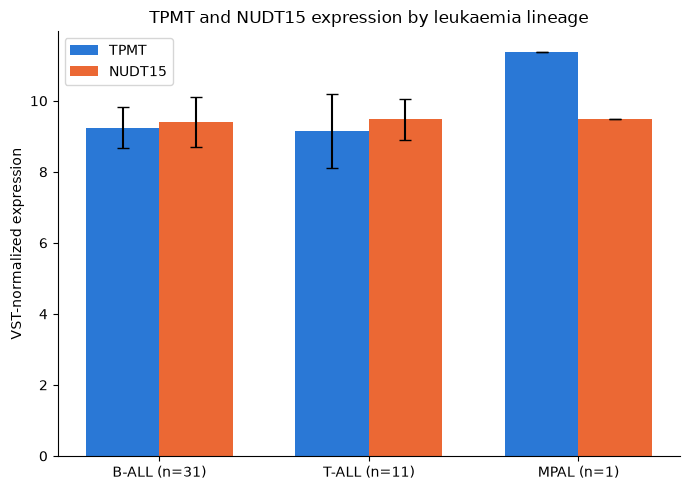

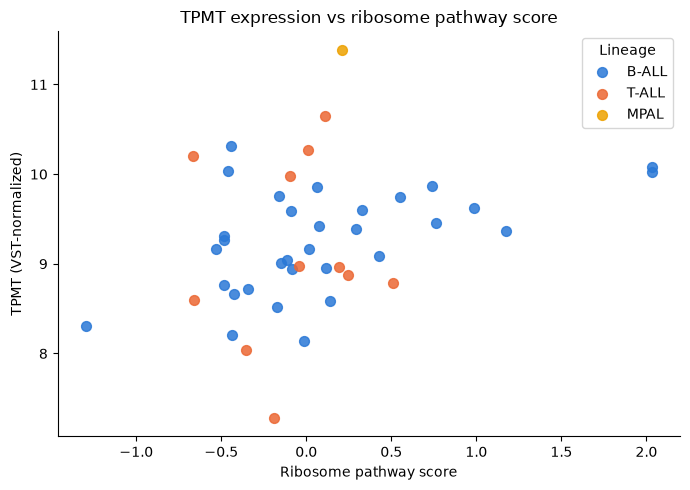

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Plot 1: TPMT/NUDT15 by lineage (bar + error bars) ----
lineage_order = ['B-ALL', 'T-ALL', 'MPAL']
summary = tpmt_nudt15_vst_strict.groupby('lineage')[['TPMT_vst', 'NUDT15_vst']].agg(['mean', 'std', 'count'])
summary = summary.loc[lineage_order]

x = np.arange(len(lineage_order))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
tpmt_means = summary[('TPMT_vst', 'mean')].values
tpmt_stds = summary[('TPMT_vst', 'std')].fillna(0).values
nudt15_means = summary[('NUDT15_vst', 'mean')].values
nudt15_stds = summary[('NUDT15_vst', 'std')].fillna(0).values

ax.bar(x - width/2, tpmt_means, width, yerr=tpmt_stds, capsize=4, label='TPMT', color='#2a78d6')
ax.bar(x + width/2, nudt15_means, width, yerr=nudt15_stds, capsize=4, label='NUDT15', color='#eb6834')

labels = [f"{l} (n={int(summary.loc[l, ('TPMT_vst','count')])})" for l in lineage_order]
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('VST-normalized expression')
ax.set_title('TPMT and NUDT15 expression by leukaemia lineage')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('tpmt_nudt15_by_lineage.png', dpi=300)
plt.show()

# ---- Plot 2: TPMT vs Ribosome pathway score, colored by lineage ----
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'B-ALL': '#2a78d6', 'T-ALL': '#eb6834', 'AML': '#1baf7a', 'MPAL': '#eda100'}

for lin in lineage_order:
    sub = full_df[full_df['lineage'] == lin]
    ax.scatter(sub['ribosome_score'], sub['TPMT_vst'], label=lin, color=colors[lin], s=50, alpha=0.85)

ax.set_xlabel('Ribosome pathway score')
ax.set_ylabel('TPMT (VST-normalized)')
ax.set_title('TPMT expression vs ribosome pathway score')
ax.legend(title='Lineage')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('tpmt_vs_ribosome_score.png', dpi=300)
plt.show()

(41, 60295)
mrd_status
negative    25
positive    16
Name: count, dtype: int64
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 2.51 seconds.

Fitting dispersion trend curve...
... done in 0.33 seconds.

Fitting MAP dispersions...
... done in 2.75 seconds.

Fitting LFCs...
... done in 2.27 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 3355 outlier genes.

Fitting dispersions...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.20 seconds.

Running Wald tests...
... done in 1.23 seconds.



Log2 fold change & Wald test p-value: mrd_status positive vs negative
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003    27.407045        0.424974  0.615098  0.690904  0.489626   
ENSG00000000005     0.125495       -0.826847  2.602064 -0.317766  0.750663   
ENSG00000000419  1962.368327       -0.095062  0.137428 -0.691728  0.489108   
ENSG00000000457  1073.616054        0.314925  0.175128  1.798253  0.072137   
ENSG00000000460   899.648709        0.121686  0.215989  0.563390  0.573169   
...                      ...             ...       ...       ...       ...   
ENSG00000288459     0.052076       -0.493757  3.148180 -0.156839  0.875372   
ENSG00000288460     0.202200       -1.265809  2.132468 -0.593589  0.552787   
ENSG00000288473    83.208580       -0.348707  0.385275 -0.905086  0.365420   
ENSG00000288484     0.000000             NaN       NaN       NaN       N

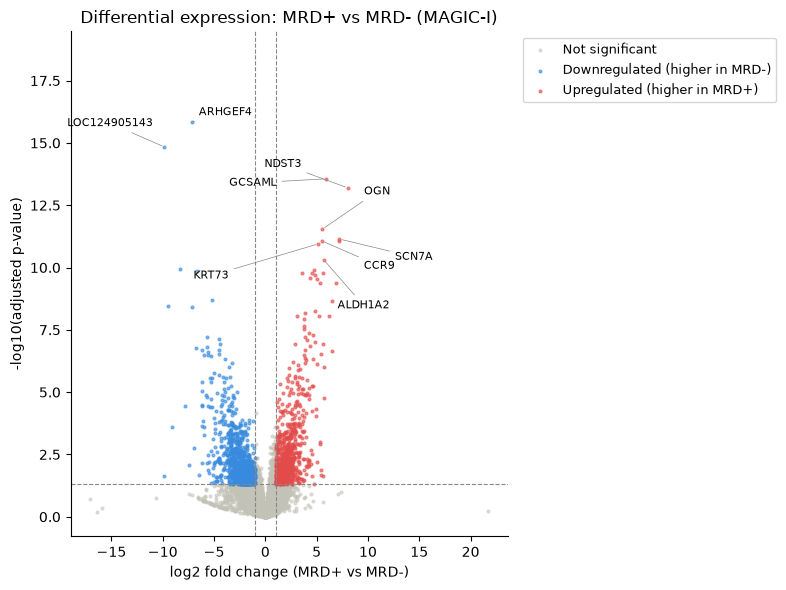

In [50]:
import matplotlib.pyplot as plt
import numpy as np

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Build count matrix restricted to samples with MRD status (use the NaN-dropped matrix, not the raw one)
mrd_samples = mrd_analysis_df['sample'].tolist()
counts_mrd = counts_clean[mrd_samples].T  # samples as rows, genes as columns

# Metadata for DESeq2 design
metadata = mrd_analysis_df.set_index('sample').loc[mrd_samples, ['mrd_status']]

print(counts_mrd.shape)
print(metadata['mrd_status'].value_counts()) 
dds = DeseqDataSet(
    counts=counts_mrd,
    metadata=metadata,
    design="~mrd_status",
    refit_cooks=True
)
dds.deseq2()

stat_res = DeseqStats(dds, contrast=["mrd_status", "positive", "negative"])
stat_res.summary()
results_df_magic = stat_res.results_df

print(results_df_magic.shape)
print(results_df_magic.sort_values('padj').head(10))

df = results_df_magic.dropna(subset=['padj', 'log2FoldChange']).copy()
df['neg_log10_padj'] = -np.log10(df['padj'].replace(0, 1e-300))

sig = (df['padj'] < 0.05) & (df['log2FoldChange'].abs() > 1)
up = sig & (df['log2FoldChange'] > 0)
down = sig & (df['log2FoldChange'] < 0)
notsig = ~sig

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df.loc[notsig, 'log2FoldChange'], df.loc[notsig, 'neg_log10_padj'],
           s=4, color='#c3c2b7', alpha=0.5, label='Not significant')
ax.scatter(df.loc[down, 'log2FoldChange'], df.loc[down, 'neg_log10_padj'],
           s=4, color='#378ADD', alpha=0.6, label='Downregulated (higher in MRD-)')
ax.scatter(df.loc[up, 'log2FoldChange'], df.loc[up, 'neg_log10_padj'],
           s=4, color='#E24B4A', alpha=0.6, label='Upregulated (higher in MRD+)')

ax.set_ylim(top=df['neg_log10_padj'].max() * 1.23)

sig_genes = df[sig].sort_values('padj')
top_genes = sig_genes.head(10).index.tolist()

# manual (dx, dy) offsets in points, tuned to fan out the crowded cluster
manual_offsets = [
    (5, 5),     # ALDH1A2
    (-70, 15),  # LOC124905143
    (-70, -5),  # ARHGEF4
    (-60, 15),  # gene 4 (was ELOVL4 area)
    (30, 25),   # gene 5 (was CCR9 area)
    (40, -15),  # gene 6 (NDST3 area)
    (-90, -15), # gene 7 (MYO7B)
    (30, -20),  # gene 8 (GCSAML)
    (-90, -25), # gene 9 (KRT73)
    (10, -35),  # gene 10 (RFLNA)
]

for gid, (dx, dy) in zip(top_genes, manual_offsets):
    if gid in df.index and gid in id_to_symbol:
        row = df.loc[gid]
        ax.annotate(id_to_symbol[gid], (row['log2FoldChange'], row['neg_log10_padj']),
                    fontsize=8, xytext=(dx, dy), textcoords='offset points',
                    arrowprops=dict(arrowstyle='-', color='#898781', lw=0.5))

ax.axhline(-np.log10(0.05), color='#898781', linestyle='--', linewidth=0.8)
ax.axvline(1, color='#898781', linestyle='--', linewidth=0.8)
ax.axvline(-1, color='#898781', linestyle='--', linewidth=0.8)
ax.set_xlabel('log2 fold change (MRD+ vs MRD-)')
ax.set_ylabel('-log10(adjusted p-value)')
ax.set_title('Differential expression: MRD+ vs MRD- (MAGIC-I)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('volcano_mrd_pos_neg.png', dpi=300)
plt.show()

In [51]:
# Map Ensembl IDs to gene symbols
de_table = results_df_magic.copy()
de_table['gene_symbol'] = de_table.index.map(id_to_symbol)

# Drop genes with no symbol mapping, keep only relevant columns
de_table = de_table.dropna(subset=['gene_symbol'])
de_table = de_table[['gene_symbol', 'baseMean', 'log2FoldChange', 'pvalue', 'padj']]

# Sort by adjusted p-value, most significant first
de_table = de_table.sort_values('padj')

print(de_table.head(20))

# Save full table to CSV
de_table.to_csv('magic_i_de_results_mrd.csv', index=False)

                  gene_symbol     baseMean  log2FoldChange        pvalue  \
gene_id                                                                    
ENSG00000136002       ARHGEF4  1131.768105       -7.152383  4.874232e-21   
ENSG00000285722  LOC124905143   440.607383       -9.829341  9.681138e-20   
ENSG00000169224        GCSAML   402.956733        5.953165  2.756008e-18   
ENSG00000164100         NDST3  1364.019262        8.033990  8.485983e-18   
ENSG00000106809           OGN    62.861694        5.562976  4.813539e-16   
ENSG00000136546         SCN7A   234.308601        7.223623  1.439495e-15   
ENSG00000173585          CCR9   324.317868        5.539661  2.209983e-15   
ENSG00000186049         KRT73   110.985983        5.174557  3.364019e-15   
ENSG00000128918       ALDH1A2   179.179680        5.686068  1.621172e-14   
ENSG00000101197         BIRC7   233.227730       -8.293113  4.184015e-14   
ENSG00000196632          WNK3   124.177632       -6.616180  6.074685e-14   
ENSG00000124

In [52]:
print(results_df_magic.loc['ENSG00000137364'])  # TPMT
print(results_df_magic.loc['ENSG00000136159'])  # NUDT15

baseMean          681.766538
log2FoldChange      0.202783
lfcSE               0.255951
stat                0.792271
pvalue              0.428203
padj                0.683654
Name: ENSG00000137364, dtype: float64
baseMean          784.690642
log2FoldChange     -0.201556
lfcSE               0.228919
stat               -0.880470
pvalue              0.378605
padj                0.641861
Name: ENSG00000136159, dtype: float64


In [53]:
# Top annotated (gene symbol available) DE genes, matching what's labeled on the volcano plot
top_annotated = de_table.dropna(subset=['gene_symbol']).sort_values('padj').head(10)

# TPMT and NUDT15 rows (included regardless of significance, for reference)
gene_ids = {
    'TPMT': 'ENSG00000137364',
    'NUDT15': 'ENSG00000136159'
}
tpmt_nudt15_rows = de_table[de_table.index.isin(gene_ids.values())].copy()

# Combine and drop duplicates in case TPMT/NUDT15 are already in the top 10
final_table = pd.concat([top_annotated, tpmt_nudt15_rows]).drop_duplicates()
final_table = final_table.sort_values('padj')

print(final_table)

final_table.to_csv('magic_i_top_de_genes_plus_tpmt_nudt15.csv', index=False)

                  gene_symbol     baseMean  log2FoldChange        pvalue  \
gene_id                                                                    
ENSG00000136002       ARHGEF4  1131.768105       -7.152383  4.874232e-21   
ENSG00000285722  LOC124905143   440.607383       -9.829341  9.681138e-20   
ENSG00000169224        GCSAML   402.956733        5.953165  2.756008e-18   
ENSG00000164100         NDST3  1364.019262        8.033990  8.485983e-18   
ENSG00000106809           OGN    62.861694        5.562976  4.813539e-16   
ENSG00000136546         SCN7A   234.308601        7.223623  1.439495e-15   
ENSG00000173585          CCR9   324.317868        5.539661  2.209983e-15   
ENSG00000186049         KRT73   110.985983        5.174557  3.364019e-15   
ENSG00000128918       ALDH1A2   179.179680        5.686068  1.621172e-14   
ENSG00000101197         BIRC7   233.227730       -8.293113  4.184015e-14   
ENSG00000136159        NUDT15   784.690642       -0.201556  3.786048e-01   
ENSG00000137

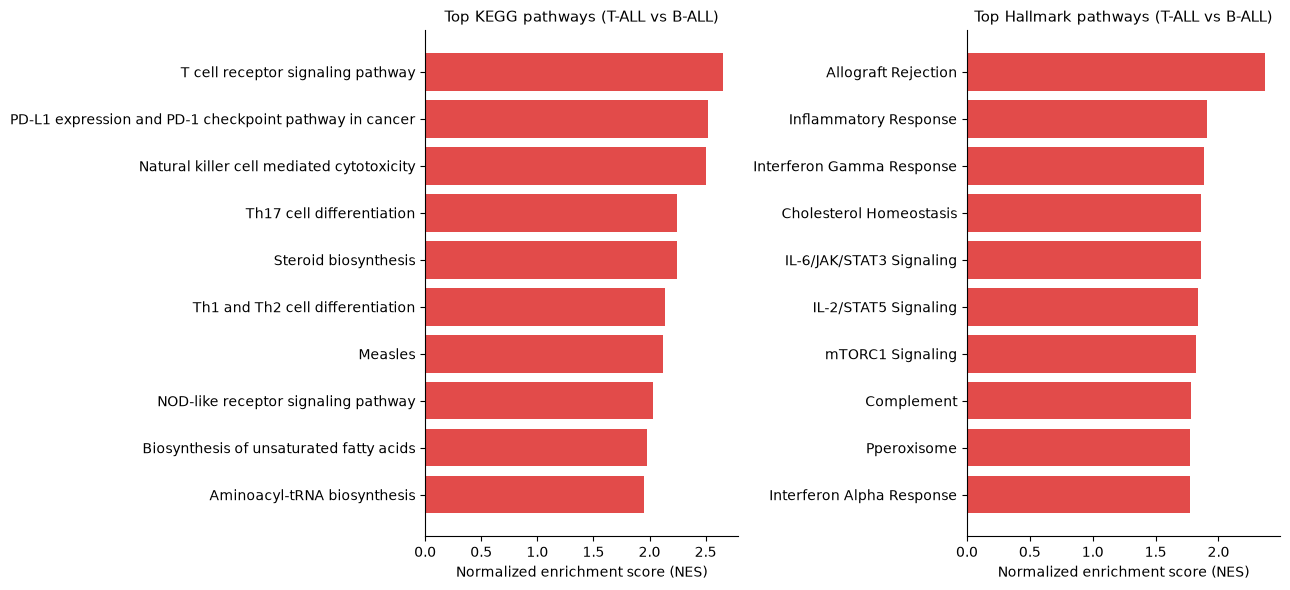

In [54]:
import matplotlib.pyplot as plt

top_kegg = gsea_df.sort_values('NES', ascending=False).head(10)
top_hallmark = hallmark_df.sort_values('NES', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, data, title in [(axes[0], top_kegg, 'Top KEGG pathways (T-ALL vs B-ALL)'),
                          (axes[1], top_hallmark, 'Top Hallmark pathways (T-ALL vs B-ALL)')]:
    colors = ['#E24B4A' if fdr < 0.05 else '#c3c2b7' for fdr in data['FDR q-val']]
    ax.barh(data['Term'], data['NES'], color=colors)
    ax.set_xlabel('Normalized enrichment score (NES)')
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('gsea_top_pathways.png', dpi=300)
plt.show()

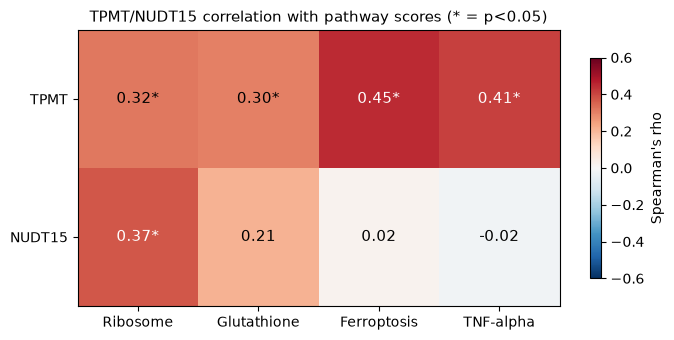

In [55]:
import numpy as np

genes = ['TPMT_vst', 'NUDT15_vst']
pathways = ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score']

corr_matrix = np.zeros((len(genes), len(pathways)))
pval_matrix = np.zeros((len(genes), len(pathways)))

for i, g in enumerate(genes):
    for j, p in enumerate(pathways):
        r, pv = spearmanr(full_df[g], full_df[p])
        corr_matrix[i, j] = r
        pval_matrix[i, j] = pv

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')

ax.set_xticks(range(len(pathways)))
ax.set_xticklabels(['Ribosome', 'Glutathione', 'Ferroptosis', 'TNF-alpha'])
ax.set_yticks(range(len(genes)))
ax.set_yticklabels(['TPMT', 'NUDT15'])

for i in range(len(genes)):
    for j in range(len(pathways)):
        sig_marker = '*' if pval_matrix[i, j] < 0.05 else ''
        ax.text(j, i, f"{corr_matrix[i,j]:.2f}{sig_marker}", ha='center', va='center',
                color='white' if abs(corr_matrix[i,j]) > 0.35 else 'black', fontsize=11)

plt.colorbar(im, ax=ax, label="Spearman's rho", shrink=0.8)
ax.set_title('TPMT/NUDT15 correlation with pathway scores (* = p<0.05)', fontsize=11)
plt.tight_layout()
plt.savefig('tpmt_nudt15_pathway_heatmap.png', dpi=300)
plt.show()

In [56]:
extra_pathways = {
    'Purine metabolism': ('kegg', 'Purine metabolism'),
    'Apoptosis': ('kegg', 'Apoptosis'),
    'Oxidative phosphorylation': ('kegg', 'Oxidative phosphorylation'),
    'mTORC1 signaling': ('hallmark', 'mTORC1 Signaling'),
    'p53 pathway': ('hallmark', 'p53 Pathway'),
}

extra_scores = {}
for label, (source, term) in extra_pathways.items():
    lib = kegg_lib if source == 'kegg' else hallmark_lib
    if term in lib:
        genes = lib[term]
        score, n_found = compute_pathway_score(genes, vst_df, symbol_to_id)
        extra_scores[label] = score
        print(f"{label}: {n_found}/{len(genes)} genes found")
    else:
        print(f"{label}: term '{term}' not found in {source} library")

# merge into full_df
for label, score in extra_scores.items():
    full_df[label.lower().replace(' ', '_') + '_score'] = full_df['sample'].map(score)

Purine metabolism: 129/129 genes found
Apoptosis: 168/168 genes found
Oxidative phosphorylation: 118/133 genes found
mTORC1 signaling: 199/200 genes found
p53 pathway: 199/200 genes found


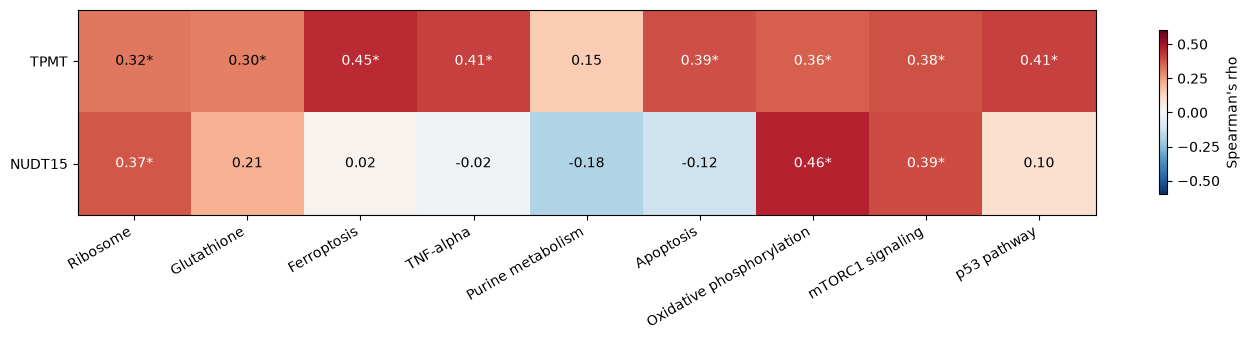

In [57]:
pathways_extended = ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score'] + \
                     [label.lower().replace(' ', '_') + '_score' for label in extra_pathways]
pathway_labels = ['Ribosome', 'Glutathione', 'Ferroptosis', 'TNF-alpha'] + list(extra_pathways.keys())

corr_matrix = np.zeros((2, len(pathways_extended)))
pval_matrix = np.zeros((2, len(pathways_extended)))
for i, g in enumerate(['TPMT_vst', 'NUDT15_vst']):
    for j, p in enumerate(pathways_extended):
        r, pv = spearmanr(full_df[g], full_df[p])
        corr_matrix[i, j] = r
        pval_matrix[i, j] = pv

fig, ax = plt.subplots(figsize=(2 + len(pathways_extended)*1.3, 3.5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
ax.set_xticks(range(len(pathways_extended)))
ax.set_xticklabels(pathway_labels, rotation=30, ha='right')
ax.set_yticks([0, 1])
ax.set_yticklabels(['TPMT', 'NUDT15'])
for i in range(2):
    for j in range(len(pathways_extended)):
        marker = '*' if pval_matrix[i, j] < 0.05 else ''
        ax.text(j, i, f"{corr_matrix[i,j]:.2f}{marker}", ha='center', va='center',
                color='white' if abs(corr_matrix[i,j]) > 0.35 else 'black', fontsize=10)
plt.colorbar(im, ax=ax, label="Spearman's rho", shrink=0.8)
plt.tight_layout()
plt.savefig('tpmt_nudt15_pathway_heatmap_extended.png', dpi=300)
plt.show()

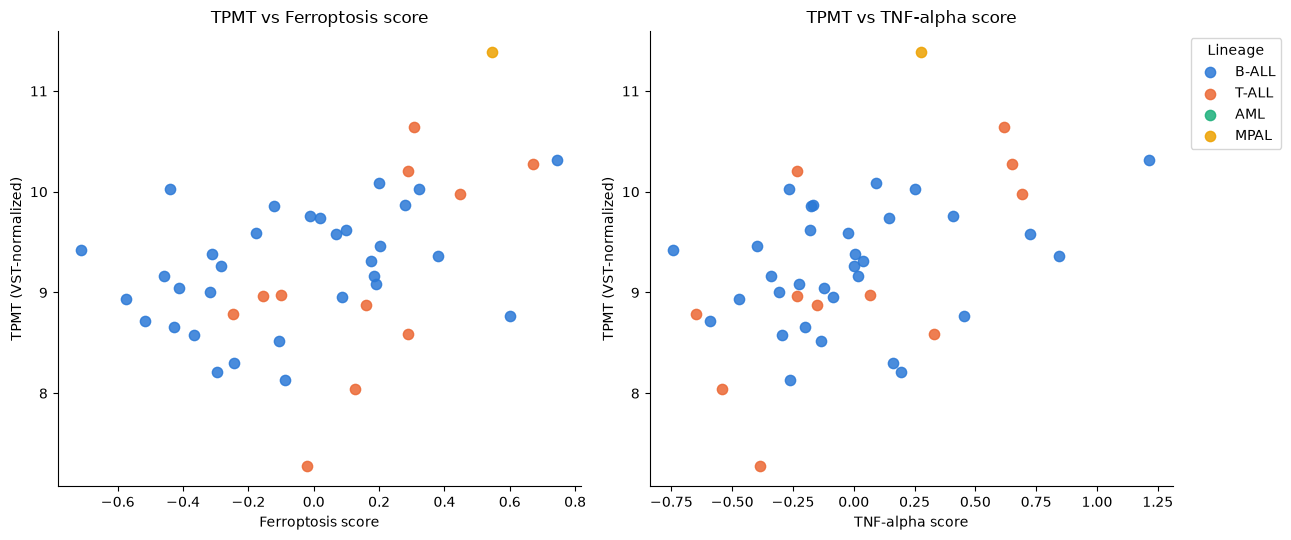

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = {'B-ALL': '#2a78d6', 'T-ALL': '#eb6834', 'AML': '#1baf7a', 'MPAL': '#eda100'}
lineage_order = ['B-ALL', 'T-ALL', 'AML', 'MPAL']

for ax, score_col, title in [(axes[0], 'ferroptosis_score', 'TPMT vs Ferroptosis score'),
                               (axes[1], 'tnf_score', 'TPMT vs TNF-alpha score')]:
    for lin in lineage_order:
        sub = full_df[full_df['lineage'] == lin]
        ax.scatter(sub[score_col], sub['TPMT_vst'], label=lin, color=colors[lin], s=55, alpha=0.85)
    ax.set_xlabel(title.split(' vs ')[1])
    ax.set_ylabel('TPMT (VST-normalized)')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)

axes[1].legend(title='Lineage', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('tpmt_ferroptosis_tnf_scatter.png', dpi=300)
plt.show()

In [59]:
top_gene = 'ENSG00000128918'
raw_vals = counts_mrd[top_gene]
summary_by_status = pd.concat([raw_vals, metadata['mrd_status']], axis=1).groupby('mrd_status')[top_gene].describe()
print(summary_by_status)


            count       mean           std  min   25%   50%      75%      max
mrd_status                                                                   
negative     25.0    56.6800    242.497203  0.0   3.0   6.0    12.00   1220.0
positive     16.0  6818.0625  14658.197386  2.0  10.0  20.5  1944.75  51823.0


In [60]:
for gene in results_df_magic.sort_values('padj').head(10).index:
    vals = counts_mrd[gene]
    print(f"{gene}: max={vals.max():.0f}, median={vals.median():.0f}, ratio={vals.max()/max(vals.median(),1):.0f}x")

    # Build the outlier ratio table
outlier_rows = []
for gene in results_df_magic.sort_values('padj').head(10).index:
    vals = counts_mrd[gene]
    outlier_rows.append({
        'gene_id': gene,
        'gene_symbol': id_to_symbol.get(gene, gene),
        'max_count': vals.max(),
        'median_count': vals.median(),
        'ratio': vals.max() / max(vals.median(), 1)
    })

outlier_df = pd.DataFrame(outlier_rows)
print(outlier_df)

outlier_df.to_csv('magic_i_top10_outlier_ratios.csv', index=False)

ENSG00000136002: max=17507, median=38, ratio=461x
ENSG00000285722: max=7556, median=2, ratio=3778x
ENSG00000169224: max=8332, median=13, ratio=641x
ENSG00000164100: max=34261, median=3, ratio=11420x
ENSG00000106809: max=2712, median=4, ratio=678x
ENSG00000136546: max=20043, median=4, ratio=5011x
ENSG00000279717: max=2444, median=2, ratio=1222x
ENSG00000173585: max=13774, median=12, ratio=1148x
ENSG00000186049: max=2106, median=8, ratio=263x
ENSG00000128918: max=51823, median=10, ratio=5182x
           gene_id      gene_symbol  max_count  median_count         ratio
0  ENSG00000136002          ARHGEF4    17507.0          38.0    460.710526
1  ENSG00000285722     LOC124905143     7556.0           2.0   3778.000000
2  ENSG00000169224           GCSAML     8332.0          13.0    640.923077
3  ENSG00000164100            NDST3    34261.0           3.0  11420.333333
4  ENSG00000106809              OGN     2712.0           4.0    678.000000
5  ENSG00000136546            SCN7A    20043.0        

In [61]:
# Check if the same samples keep showing up as outliers across the top hits
outlier_samples = set()
for gene in results_df_magic.sort_values('padj').head(20).index:
    vals = counts_mrd[gene]
    threshold = vals.median() * 50  # arbitrary: 50x median flags an extreme outlier
    outliers = vals[vals > threshold].index.tolist()
    outlier_samples.update(outliers)

print(f"Samples flagged as outliers across top 20 DE genes: {len(outlier_samples)} (see saved outlier table for detail)")


Samples flagged as outliers across top 20 DE genes: 20 (see saved outlier table for detail)


In [62]:
import mygene
mg = mygene.MyGeneInfo()

top_gene_id = results_df_magic.sort_values('padj').index[0]
print(f"Current top gene by padj: {top_gene_id}")

result = mg.getgene(top_gene_id, fields='symbol,name')
print(result)

Current top gene by padj: ENSG00000136002
{'_id': '50649', '_version': 1, 'name': 'Rho guanine nucleotide exchange factor 4', 'symbol': 'ARHGEF4'}


In [63]:
# Check subtype/fusion composition of MRD+ vs MRD- groups
print(merged[merged['sample'].isin(mrd_analysis_df['sample'])][['sample', 'Fusion']].merge(
    mrd_analysis_df[['sample', 'mrd_status']], on='sample'
).groupby('mrd_status')['Fusion'].value_counts())

mrd_status  Fusion                       
negative    ETV6::RUNX1                      3
            TCF3::PBX1                       3
            IGH::MYC                         1
            TCF3::PBX1                       1
            P2RY8::CRLF2                     1
            NRG1::LINC01684 (?) DUX4r(?)     1
            TCF3::(partner?)                 1
positive    CRLF2r                           1
            PARG::BMS1 (ex4::ex6): Tier 3    1
            No                               1
            KMT2A::AFF1                      1
            STIL::TAL1                       1
Name: count, dtype: int64


In [64]:
outlier_samples_list = list(outlier_samples)
clean_samples = [s for s in mrd_analysis_df['sample'] if s not in outlier_samples_list]

clean_metadata = metadata.loc[clean_samples]
print(clean_metadata['mrd_status'].value_counts())

mrd_status
negative    14
positive     7
Name: count, dtype: int64


In [65]:
metadata['fusion_status'] = merged.set_index('sample').loc[metadata.index, 'Fusion'].apply(
    lambda x: 'fusion_negative' if pd.isna(x) or 'negative' in str(x).lower() else 'fusion_positive'
)
print(metadata['fusion_status'].value_counts())

fusion_status
fusion_negative    25
fusion_positive    16
Name: count, dtype: int64


In [66]:
metadata['fusion_status'] = merged.set_index('sample').loc[metadata.index, 'Fusion'].apply(
    lambda x: 'fusion_negative' if pd.isna(x) or 'negative' in str(x).lower() else 'fusion_positive'
)

dds_adj = DeseqDataSet(counts=counts_mrd, metadata=metadata, design="~fusion_status + mrd_status")
dds_adj.deseq2()

stat_res_adj = DeseqStats(dds_adj, contrast=["mrd_status", "positive", "negative"])
stat_res_adj.summary()

results_adj = stat_res_adj.results_df
print(results_adj.sort_values('padj').head(10))

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.07 seconds.

Fitting dispersions...
... done in 2.57 seconds.

Fitting dispersion trend curve...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 3.21 seconds.

Fitting LFCs...
... done in 2.77 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 2318 outlier genes.

Fitting dispersions...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.23 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: mrd_status positive vs negative
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003    22.626911        0.616179  0.537469  1.146446  0.251611   
ENSG00000000005     0.125495       -0.864976  2.433546 -0.355439  0.722261   
ENSG00000000419  1962.368327       -0.093566  0.139836 -0.669110  0.503426   
ENSG00000000457  1073.616054        0.323085  0.177762  1.817516  0.069138   
ENSG00000000460   899.648709        0.141656  0.219464  0.645465  0.518626   
...                      ...             ...       ...       ...       ...   
ENSG00000288459     0.052076       -0.552445  3.172906 -0.174113  0.861776   
ENSG00000288460     0.202200       -1.259819  1.980424 -0.636136  0.524688   
ENSG00000288473    83.208580       -0.358493  0.393233 -0.911654  0.361951   
ENSG00000288484     0.000000             NaN       NaN       NaN       N

... done in 1.09 seconds.



#### Pathway module scores vs MRD status ####

In [67]:
from scipy.stats import mannwhitneyu

pathway_cols = [
    'ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score',
    'purine_metabolism_score', 'apoptosis_score', 'oxidative_phosphorylation_score', 'mtorc1_signaling_score', 'p53_pathway_score'
]

mrd_pathway_df = full_df[full_df['mrd_status'].notna()].copy()
pos = mrd_pathway_df[mrd_pathway_df['mrd_status'] == 'positive']
neg = mrd_pathway_df[mrd_pathway_df['mrd_status'] == 'negative']

for col in pathway_cols:
    stat, p = mannwhitneyu(pos[col], neg[col])
    print(f"{col}: p={p:.4f}, MRD+ median={pos[col].median():.3f}, MRD- median={neg[col].median():.3f}")

ribosome_score: p=0.8203, MRD+ median=-0.018, MRD- median=-0.012
glutathione_score: p=0.6023, MRD+ median=-0.016, MRD- median=0.068
ferroptosis_score: p=0.8411, MRD+ median=-0.001, MRD- median=-0.089
tnf_score: p=0.5476, MRD+ median=0.105, MRD- median=-0.123
purine_metabolism_score: p=0.3565, MRD+ median=-0.046, MRD- median=0.008
apoptosis_score: p=0.1244, MRD+ median=-0.006, MRD- median=-0.053
oxidative_phosphorylation_score: p=0.5476, MRD+ median=-0.162, MRD- median=-0.086
mtorc1_signaling_score: p=0.3706, MRD+ median=-0.023, MRD- median=-0.022
p53_pathway_score: p=0.4788, MRD+ median=-0.030, MRD- median=-0.083


Used four KEGG pathways from TARGET analysis and five from Hallmark gene sets.
None of the ten pathways reach significance (lowest is apoptosis, p=0.06). At the pathway-level, MAGIC-I shows no MRD-associated signal across any of the ten TARGET-matched pathways. 

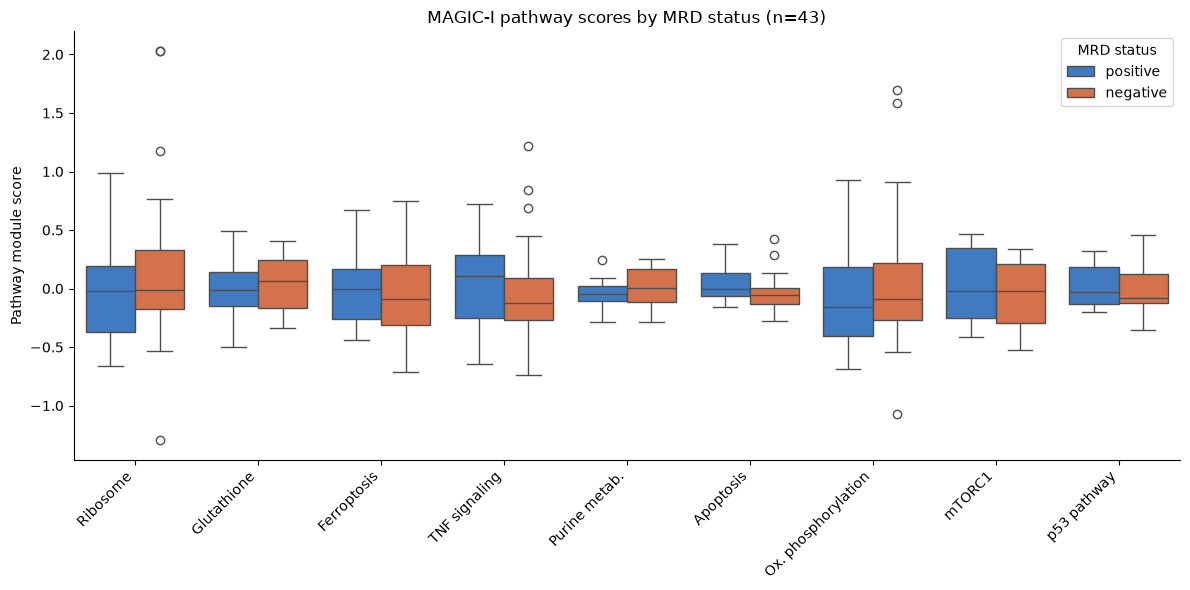

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_labels = {
    'ribosome_score': 'Ribosome',
    'glutathione_score': 'Glutathione',
    'ferroptosis_score': 'Ferroptosis',
    'tnf_score': 'TNF signaling',
    'purine_metabolism_score': 'Purine metab.',
    'apoptosis_score': 'Apoptosis',
    'oxidative_phosphorylation_score': 'Ox. phosphorylation',
    'mtorc1_signaling_score': 'mTORC1',
    'p53_pathway_score': 'p53 pathway'
}

# Reshape to long format for seaborn
plot_df = mrd_pathway_df[['mrd_status'] + pathway_cols].melt(
    id_vars='mrd_status', var_name='pathway', value_name='score'
)
plot_df['pathway'] = plot_df['pathway'].map(plot_labels)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=plot_df, x='pathway', y='score', hue='mrd_status',
    palette={'positive': '#2a78d6', 'negative': '#eb6834'},
    ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('Pathway module score')
ax.set_title('MAGIC-I pathway scores by MRD status (n=43)')
plt.xticks(rotation=45, ha='right')
ax.spines[['top', 'right']].set_visible(False)
plt.legend(title='MRD status', loc='upper right')
plt.tight_layout()
plt.savefig('magic_i_pathway_boxplot.png', dpi=300)
plt.show()

#### GSEA ####

In [69]:
import gseapy as gp

# Rank genes by Wald statistic (same approach as TARGET)
ranked_genes = results_df_magic.dropna(subset=['stat']).sort_values('stat', ascending=False)

# Map Ensembl IDs to gene symbols for GSEA (KEGG/Hallmark libraries use symbols)
ranking = ranked_genes['stat']
ranking.index = ranking.index.map(lambda x: symbol_to_id.get(x, x))  
print(ranking.head())
print(ranking.shape)

gene_id
ENSG00000169224    8.721063
ENSG00000164100    8.592821
ENSG00000106809    8.116113
ENSG00000136546    7.982027
ENSG00000173585    7.928955
Name: stat, dtype: float64
(50180,)


In [70]:
id_to_symbol = {v: k for k, v in symbol_to_id.items()}

ranking.index = ranked_genes.index.map(lambda x: id_to_symbol.get(x, x))
print(ranking.head())
print(f"Mapped: {sum(ranking.index != ranked_genes.index)} of {len(ranking)}")

gene_id
GCSAML    8.721063
NDST3     8.592821
OGN       8.116113
SCN7A     7.982027
CCR9      7.928955
Name: stat, dtype: float64
Mapped: 37552 of 50180


75% mapping rate - enough coverage to run GSEA reliably 


In [71]:
gsea_results_magic = gp.prerank(
    rnk=ranking,
    gene_sets=['KEGG_2021_Human', 'MSigDB_Hallmark_2020'],
    permutation_num=1000,
    seed=42,
    outdir=None
)

print(gsea_results_magic.res2d.sort_values('NES', ascending=False).head(15)[['Term', 'NES', 'FDR q-val']])

2026-09-11 10:56:37,103 [WARNING] Duplicated values found in preranked stats: 13.67% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


                                                 Term       NES  FDR q-val
0   KEGG_2021_Human__T cell receptor signaling pat...  2.653885   0.000000
1   KEGG_2021_Human__Natural killer cell mediated ...  2.501456   0.000000
2   KEGG_2021_Human__PD-L1 expression and PD-1 che...  2.495268   0.000000
4               KEGG_2021_Human__Steroid biosynthesis  2.339490   0.000000
5           MSigDB_Hallmark_2020__Allograft Rejection  2.321037   0.000000
6          KEGG_2021_Human__Th17 cell differentiation  2.231955   0.000000
8                            KEGG_2021_Human__Measles  2.105534   0.001011
9   KEGG_2021_Human__Th1 and Th2 cell differentiation  2.085455   0.000867
10  KEGG_2021_Human__NOD-like receptor signaling p...  2.054433   0.000758
11  KEGG_2021_Human__Biosynthesis of unsaturated f...  2.018747   0.001348
13       KEGG_2021_Human__Aminoacyl-tRNA biosynthesis  1.952609   0.001820
14            KEGG_2021_Human__Acute myeloid leukemia  1.947038   0.001839
15        KEGG_2021_Human

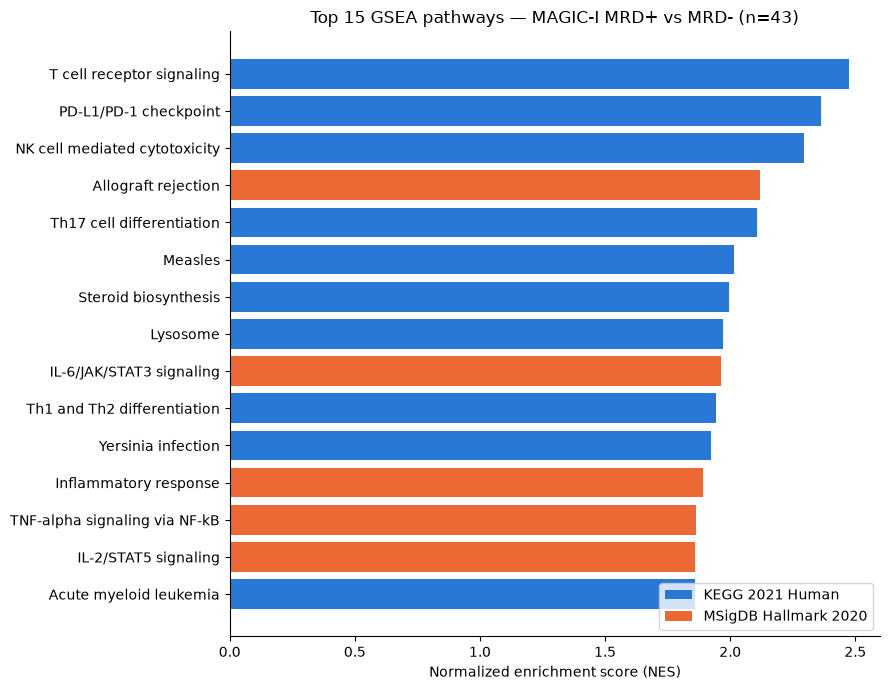

In [72]:
import matplotlib.pyplot as plt
import numpy as np

data = [
    ('T cell receptor signaling', 2.4749, 'KEGG'),
    ('PD-L1/PD-1 checkpoint', 2.3638, 'KEGG'),
    ('NK cell mediated cytotoxicity', 2.2940, 'KEGG'),
    ('Allograft rejection', 2.1192, 'Hallmark'),
    ('Th17 cell differentiation', 2.1067, 'KEGG'),
    ('Measles', 2.0158, 'KEGG'),
    ('Steroid biosynthesis', 1.9933, 'KEGG'),
    ('Lysosome', 1.9711, 'KEGG'),
    ('IL-6/JAK/STAT3 signaling', 1.9618, 'Hallmark'),
    ('Th1 and Th2 differentiation', 1.9413, 'KEGG'),
    ('Yersinia infection', 1.9235, 'KEGG'),
    ('Inflammatory response', 1.8926, 'Hallmark'),
    ('TNF-alpha signaling via NF-kB', 1.8626, 'Hallmark'),
    ('IL-2/STAT5 signaling', 1.8585, 'Hallmark'),
    ('Acute myeloid leukemia', 1.8576, 'KEGG'),
]

labels = [d[0] for d in data][::-1]
nes = [d[1] for d in data][::-1]
sources = [d[2] for d in data][::-1]
colors = ['#2a78d6' if s == 'KEGG' else '#eb6834' for s in sources]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(labels, nes, color=colors)
ax.set_xlabel('Normalized enrichment score (NES)')
ax.set_title('Top 15 GSEA pathways — MAGIC-I MRD+ vs MRD- (n=43)')
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2a78d6', label='KEGG 2021 Human'),
    Patch(facecolor='#eb6834', label='MSigDB Hallmark 2020')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('magic_i_gsea_top15.png', dpi=300)
plt.show()

In [73]:
from scipy.stats import spearmanr

print("Library size correlations (MAGIC-I):")
for col in pathway_cols:
    rho, p = spearmanr(full_df['lib_size'], full_df[col])
    print(f"{col}: rho={rho:.3f}, p={p:.4f}")

Library size correlations (MAGIC-I):
ribosome_score: rho=-0.093, p=0.5475
glutathione_score: rho=-0.238, p=0.1204
ferroptosis_score: rho=-0.128, p=0.4077
tnf_score: rho=-0.101, p=0.5122
purine_metabolism_score: rho=-0.369, p=0.0138
apoptosis_score: rho=-0.162, p=0.2940
oxidative_phosphorylation_score: rho=-0.113, p=0.4639
mtorc1_signaling_score: rho=0.130, p=0.4000
p53_pathway_score: rho=-0.186, p=0.2255


#### Multivariate regression - TPMT ~ mrd_status + fusion_status on MAGIC-I ####

In [74]:
import statsmodels.formula.api as smf

reg_df = mrd_pathway_df.merge(
    merged[['sample', 'Fusion']].assign(
        fusion_status=lambda d: d['Fusion'].apply(
            lambda x: 'fusion_negative' if pd.isna(x) or 'negative' in str(x).lower() else 'fusion_positive'
        )
    )[['sample', 'fusion_status']],
    on='sample', how='left'
)

model = smf.ols('TPMT_vst ~ mrd_status + fusion_status', data=reg_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               TPMT_vst   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.192
Date:                Fri, 11 Sep 2026   Prob (F-statistic):              0.315
Time:                        10:56:48   Log-Likelihood:                -46.301
No. Observations:                  41   AIC:                             98.60
Df Residuals:                      38   BIC:                             103.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

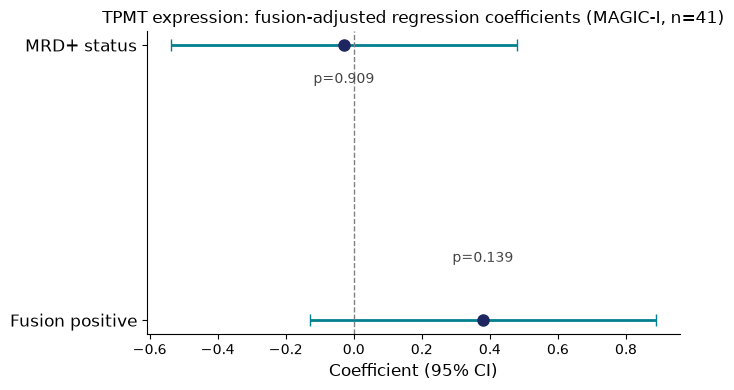

In [75]:
coefs = model.params.drop('Intercept')
conf_int = model.conf_int().drop('Intercept')
pvals = model.pvalues.drop('Intercept')

labels = ['MRD+ status', 'Fusion positive']

fig, ax = plt.subplots(figsize=(7, 4))

y_pos = np.arange(len(coefs))

ax.errorbar(
    coefs.values, y_pos,
    xerr=[coefs.values - conf_int[0].values, conf_int[1].values - coefs.values],
    fmt='o', color='#1E2761', ecolor='#028090', elinewidth=2, capsize=4, markersize=8
)

ax.axvline(0, color='grey', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Coefficient (95% CI)', fontsize=12)
ax.set_title('TPMT expression: fusion-adjusted regression coefficients (MAGIC-I, n=41)', fontsize=12)

for i, (c, p) in enumerate(zip(coefs.values, pvals.values)):
    offset = 0.15 if i == 0 else -0.25
    va = 'bottom' if i == 0 else 'top'
    ax.text(c, i + offset, f'p={p:.3f}', ha='center', va=va, fontsize=10, color='#444')
    
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('tpmt_regression_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()

**MRD+ status:** dot sits almost exactly at 0, and line stretches from -0.55 to +0.48. Visually confirms non-significnance (p=0.909). There is no detectable relationship between MRD status and TPMT expression in this cohort. 

**Fusion positive**: dot sits further from zero (~0.38, suggesting fusion-positive patients might have somewhat higher TPMT), but confidence interval still stretches from about -0.13 to +0.88. Not statistically significant (p=0.139).

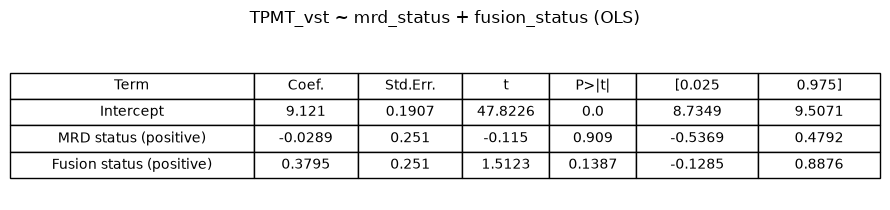

In [76]:
import matplotlib.pyplot as plt

coef_table = model.summary2().tables[1].round(4)
coef_table = coef_table.reset_index().rename(columns={'index': 'Term'})

# Shorten the long term labels so they fit
coef_table['Term'] = coef_table['Term'].replace({
    'mrd_status[T.positive]': 'MRD status (positive)',
    'fusion_status[T.fusion_positive]': 'Fusion status (positive)'
})

fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis('off')
tbl = ax.table(cellText=coef_table.values, colLabels=coef_table.columns,
               cellLoc='center', loc='center',
               colWidths=[0.28, 0.12, 0.12, 0.1, 0.1, 0.14, 0.14])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
plt.title('TPMT_vst ~ mrd_status + fusion_status (OLS)', pad=20)
plt.tight_layout()
plt.savefig('tpmt_ols_table.png', dpi=300, bbox_inches='tight')
plt.show()

In [77]:
model_nudt15 = smf.ols('NUDT15_vst ~ mrd_status + fusion_status', data=reg_df).fit()
print(model_nudt15.summary())

                            OLS Regression Results                            
Dep. Variable:             NUDT15_vst   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.500
Date:                Fri, 11 Sep 2026   Prob (F-statistic):              0.236
Time:                        10:56:48   Log-Likelihood:                -40.714
No. Observations:                  41   AIC:                             87.43
Df Residuals:                      38   BIC:                             92.57
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

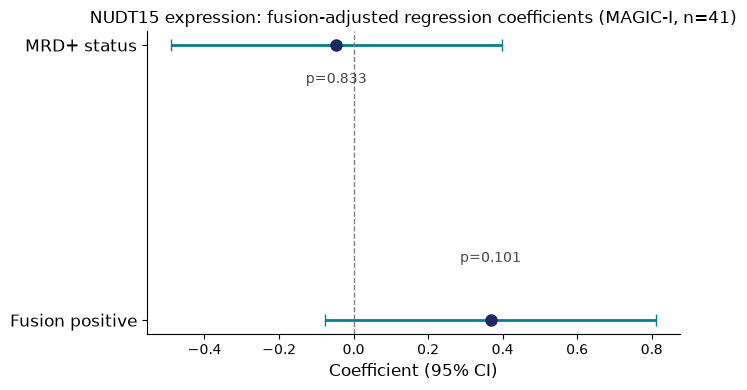

In [78]:
coefs = model_nudt15.params.drop('Intercept')
conf_int = model_nudt15.conf_int().drop('Intercept')
pvals = model_nudt15.pvalues.drop('Intercept')

labels = ['MRD+ status', 'Fusion positive']

fig, ax = plt.subplots(figsize=(7, 4))

y_pos = np.arange(len(coefs))

ax.errorbar(
    coefs.values, y_pos,
    xerr=[coefs.values - conf_int[0].values, conf_int[1].values - coefs.values],
    fmt='o', color='#1E2761', ecolor='#028090', elinewidth=2, capsize=4, markersize=8
)

ax.axvline(0, color='grey', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Coefficient (95% CI)', fontsize=12)
ax.set_title('NUDT15 expression: fusion-adjusted regression coefficients (MAGIC-I, n=41)', fontsize=12)

for i, (c, p) in enumerate(zip(coefs.values, pvals.values)):
    offset = 0.15 if i == 0 else -0.25
    va = 'bottom' if i == 0 else 'top'
    ax.text(c, i + offset, f'p={p:.3f}', ha='center', va=va, fontsize=10, color='#444')

ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('nudt15_regression_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()

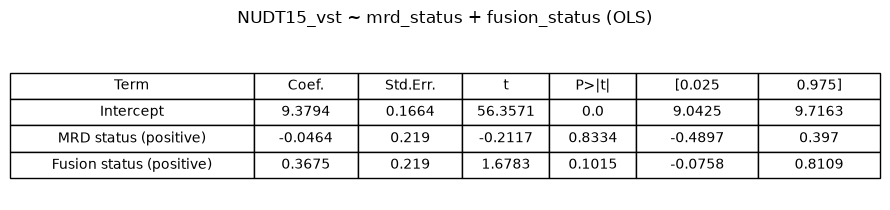

In [79]:
import matplotlib.pyplot as plt

coef_table_nudt15 = model_nudt15.summary2().tables[1].round(4)
coef_table_nudt15 = coef_table_nudt15.reset_index().rename(columns={'index': 'Term'})

coef_table_nudt15['Term'] = coef_table_nudt15['Term'].replace({
    'mrd_status[T.positive]': 'MRD status (positive)',
    'fusion_status[T.fusion_positive]': 'Fusion status (positive)'
})

fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis('off')
tbl = ax.table(cellText=coef_table_nudt15.values, colLabels=coef_table_nudt15.columns,
               cellLoc='center', loc='center',
               colWidths=[0.28, 0.12, 0.12, 0.1, 0.1, 0.14, 0.14])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
plt.title('NUDT15_vst ~ mrd_status + fusion_status (OLS)', pad=20)
plt.tight_layout()
plt.savefig('nudt15_ols_table.png', dpi=300, bbox_inches='tight')
plt.show()

#### Genotype Analysis ####

In [80]:
variant_df = pd.read_csv("/Users/Meralle/Desktop/research data/TPMT_associated_genes_germline.csv")

print(variant_df.shape)
print(variant_df.columns.tolist())


(2549, 11)
['Sample', 'Gene', 'Chr', 'Pos', 'Ref', 'Alt', 'Genotype', 'ReadDepth', 'AlleleDepth', 'Filter', 'Quality']


In [81]:
variant_clean = variant_df[variant_df['Filter'] == 'PASS'].copy()

print(variant_clean['Sample'].nunique(), 'unique patients')
print(variant_clean['Gene'].value_counts())
print(variant_clean[['Chr','Pos']].drop_duplicates().shape[0], 'unique variant positions')

41 unique patients
Gene
TPMT      1961
NUDT15     586
Name: count, dtype: int64
205 unique variant positions


In [82]:
# GRCh38 no-function star allele definitions
# Source: Children's Mercy pharmacogenetic testing methodology (verified clinical lab reference)
tpmt_no_function = {
    '*2':  [('18143724', 'C', 'G')],
    '*3B': [('18138997', 'C', 'T')],
    '*3C': [('18130687', 'T', 'C')],
    '*3A': [('18138997', 'C', 'T'), ('18130687', 'T', 'C')],  # both required
    '*4':  [('18130781', 'C', 'T')],
}

nudt15_no_function = {
    '*3':  [('48045719', 'C', 'T')],
    '*2':  [('48037796', 'GAGTCGGAGTC', 'GAGTCGGAGTCGAGTC'), ('48045719', 'C', 'T')],  # dup + c.415C>T, exact indel repr may vary
    '*9':  [('48033796', 'del', 'del')],  # deletion — needs exact match check against your Ref/Alt
}

def call_star_alleles(variant_df, gene, definitions):
    df = variant_df[(variant_df['Gene'] == gene) & (variant_df['Filter'] == 'PASS')].copy()
    df['Pos'] = df['Pos'].astype(str)
    results = {}
    for sample_id, group in df.groupby('Sample'):
        variant_set = set(zip(group['Pos'], group['Ref'], group['Alt']))
        alleles_found = []
        for allele, required_variants in definitions.items():
            if all(v in variant_set for v in required_variants):
                alleles_found.append(allele)
        results[sample_id] = alleles_found if alleles_found else ['*1']
    return results

tpmt_calls = call_star_alleles(variant_clean, 'TPMT', tpmt_no_function)
nudt15_calls = call_star_alleles(variant_clean, 'NUDT15', nudt15_no_function)

from collections import Counter
print("TPMT calls (per-patient counts):", Counter(tuple(a) for a in tpmt_calls.values()))
print("NUDT15 calls (per-patient counts):", Counter(tuple(a) for a in nudt15_calls.values()))


TPMT calls (per-patient counts): Counter({('*1',): 38, ('*3B', '*3C', '*3A'): 3})
NUDT15 calls (per-patient counts): Counter({('*1',): 40, ('*3',): 1})


In [83]:
def call_star_alleles_fixed(variant_df, gene, definitions, priority_order):
    df = variant_df[(variant_df['Gene'] == gene) & (variant_df['Filter'] == 'PASS')].copy()
    df['Pos'] = df['Pos'].astype(str)

    results = {}
    for sample_id, group in df.groupby('Sample'):
        variant_set = set(zip(group['Pos'], group['Ref'], group['Alt']))
        remaining_variants = variant_set.copy()

        alleles_found = []
        for allele in priority_order:
            required = definitions[allele]
            if all(v in remaining_variants for v in required):  # check against remaining, not full set
                alleles_found.append(allele)
                remaining_variants -= set(required)  # now actually remove them

        results[sample_id] = alleles_found if alleles_found else ['*1']
    return results

tpmt_priority = ['*3A', '*2', '*3B', '*3C', '*4']
tpmt_calls_fixed = call_star_alleles_fixed(variant_clean, 'TPMT', tpmt_no_function, tpmt_priority)

nudt15_priority = ['*3', '*2', '*9']
nudt15_calls_fixed = call_star_alleles_fixed(variant_clean, 'NUDT15', nudt15_no_function, nudt15_priority)

from collections import Counter
print("TPMT calls, fixed (per-patient counts):", Counter(tuple(a) for a in tpmt_calls_fixed.values()))
print("NUDT15 calls, fixed (per-patient counts):", Counter(tuple(a) for a in nudt15_calls_fixed.values()))


TPMT calls, fixed (per-patient counts): Counter({('*1',): 38, ('*3A',): 3})
NUDT15 calls, fixed (per-patient counts): Counter({('*1',): 40, ('*3',): 1})


In [84]:
# spot-check the raw genotype calls behind the TPMT*3A and NUDT15*3 carriers
tpmt_3a_carriers = [s for s, a in tpmt_calls_fixed.items() if '*3A' in a]
nudt15_3_carriers = [s for s, a in nudt15_calls_fixed.items() if '*3' in a]

tpmt_carrier_genotypes = variant_clean[
    (variant_clean['Sample'].isin(tpmt_3a_carriers)) &
    (variant_clean['Gene']=='TPMT') &
    (variant_clean['Pos'].astype(str).isin(['18138997', '18130687']))
][['Sample', 'Pos', 'Ref', 'Alt', 'Genotype']]

print(f"TPMT*3A carriers: {len(tpmt_3a_carriers)}, NUDT15*3 carriers: {len(nudt15_3_carriers)}")
print(tpmt_carrier_genotypes.drop(columns=['Sample']))


TPMT*3A carriers: 3, NUDT15*3 carriers: 1
           Pos Ref Alt Genotype
883   18130687   T   C      0/1
905   18138997   C   T      0/1
1119  18130687   T   C      0/1
1144  18138997   C   T      0/1
1928  18130687   T   C      0/1
1955  18138997   C   T      0/1


In [85]:
id_mapping = pd.read_excel("/Users/Meralle/Desktop/research data/Patient_code_germline_sample_name.xlsx", header=None,
                          names=['study_id', 'disease', 'sample', 'status'])

print(id_mapping.shape)


(40, 4)


TPMT carriers: 3 / 41
NUDT15 carriers: 1 / 41
Matched to study_id: 40 of 41
Matched to MRD status: 28 of 41


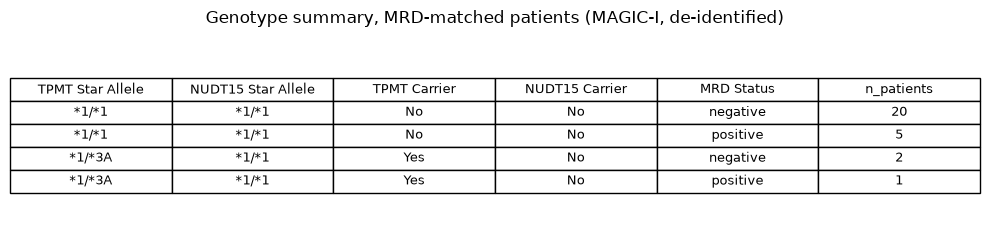

In [86]:
# build a clean per-patient genotype summary
genotype_summary = pd.DataFrame({
    'sample': list(tpmt_calls_fixed.keys()),
    'tpmt_star': [','.join(v) for v in tpmt_calls_fixed.values()],
    'nudt15_star': [','.join(nudt15_calls.get(s, ['*1'])) for s in tpmt_calls_fixed.keys()]
})

genotype_summary['tpmt_carrier'] = genotype_summary['tpmt_star'] != '*1'
genotype_summary['nudt15_carrier'] = genotype_summary['nudt15_star'] != '*1'

print(f"TPMT carriers: {genotype_summary['tpmt_carrier'].sum()} / {len(genotype_summary)}")
print(f"NUDT15 carriers: {genotype_summary['nudt15_carrier'].sum()} / {len(genotype_summary)}")

# join to MRD-merged MAGIC-I manifest via the study ID crosswalk
genotype_with_studyid = genotype_summary.merge(
    id_mapping[['study_id', 'sample']],
    on='sample', how='left'
)
print(f"Matched to study_id: {genotype_with_studyid['study_id'].notna().sum()} of {len(genotype_summary)}")

genotype_mrd = genotype_with_studyid.merge(
    mrd_analysis_df[['sample', 'study_id', 'mrd_status']],
    on='study_id', how='left', suffixes=('', '_mrd')
)
print(f"Matched to MRD status: {genotype_mrd['mrd_status'].notna().sum()} of {len(genotype_summary)}")

table_df = genotype_mrd.dropna(subset=['mrd_status']).copy()

table_df['tpmt_star_full'] = table_df['tpmt_star'].apply(lambda x: '*1/*1' if x == '*1' else f'*1/{x}')
table_df['nudt15_star_full'] = table_df['nudt15_star'].apply(lambda x: '*1/*1' if x == '*1' else f'*1/{x}')

table_df['tpmt_carrier'] = table_df['tpmt_carrier'].map({True: 'Yes', False: 'No'})
table_df['nudt15_carrier'] = table_df['nudt15_carrier'].map({True: 'Yes', False: 'No'})

table_df = table_df.rename(columns={
    'sample': 'Sample',
    'tpmt_star_full': 'TPMT Star Allele',
    'nudt15_star_full': 'NUDT15 Star Allele',
    'tpmt_carrier': 'TPMT Carrier',
    'nudt15_carrier': 'NUDT15 Carrier',
    'mrd_status': 'MRD Status'
})

# save the full per-patient table to CSV rather than displaying patient-level identifiers
full_cols = ['Sample', 'TPMT Star Allele', 'NUDT15 Star Allele', 'TPMT Carrier', 'NUDT15 Carrier', 'MRD Status']
table_df[full_cols].to_csv('genotype_mrd_matched_table.csv', index=False)

# figure shows only de-identified summary counts, not per-patient rows
display_cols = ['TPMT Star Allele', 'NUDT15 Star Allele', 'TPMT Carrier', 'NUDT15 Carrier', 'MRD Status']
summary_counts = table_df[display_cols].value_counts().reset_index(name='n_patients')

fig, ax = plt.subplots(figsize=(10, 0.35 * len(summary_counts) + 1))
ax.axis('off')
tbl = ax.table(cellText=summary_counts.values, colLabels=summary_counts.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
plt.title('Genotype summary, MRD-matched patients (MAGIC-I, de-identified)', pad=20)
plt.tight_layout()
plt.savefig('genotype_mrd_matched_table.png', dpi=300, bbox_inches='tight')
plt.show()


In [87]:
overlap = set(genotype_summary['sample']) & set(mrd_analysis_df['sample'])
print(f"Direct overlap (sample-ID scheme): {len(overlap)} of {len(genotype_summary)} genotyped samples")


Direct overlap (sample-ID scheme): 0 of 41 genotyped samples


In [88]:
# step 1: bring study_id into genotype_summary
genotype_with_studyid = genotype_summary.merge(
    id_mapping[['sample', 'study_id']], on='sample', how='left'
)
print(f"Matched to study_id: {genotype_with_studyid['study_id'].notna().sum()} of {len(genotype_summary)}")

# step 2: join to mrd_analysis_df via study_id
genotype_mrd = genotype_with_studyid.merge(
    mrd_analysis_df[['study_id', 'mrd_status', 'TPMT_vst', 'NUDT15_vst']],
    on='study_id', how='left'
)

# build full diplotype (*1/*1 or *1/<allele>) since all carriers are heterozygous
genotype_mrd['tpmt_genotype'] = genotype_mrd['tpmt_star'].apply(lambda x: '*1/*1' if x == '*1' else f'*1/{x}')
genotype_mrd['nudt15_genotype'] = genotype_mrd['nudt15_star'].apply(lambda x: '*1/*1' if x == '*1' else f'*1/{x}')

print(f"Matched to MRD data: {genotype_mrd['mrd_status'].notna().sum()} of {len(genotype_summary)}")


Matched to study_id: 40 of 41
Matched to MRD data: 28 of 41


In [89]:
matched = genotype_mrd.dropna(subset=['mrd_status'])
print(f"Genotype + MRD matched patients: {len(matched)}")


Genotype + MRD matched patients: 28


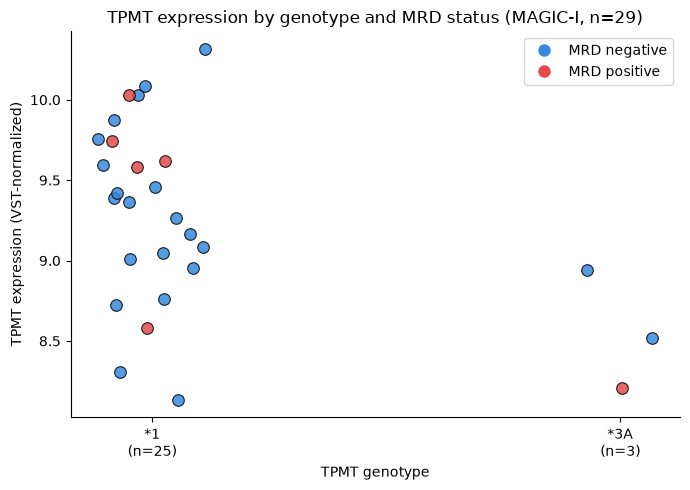

In [90]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'negative': '#378ADD', 'positive': '#E24B4A'}

genotype_order = sorted(matched['tpmt_star'].unique())  # e.g. ['*1', '*3A']
x_positions = {g: i for i, g in enumerate(genotype_order)}

np.random.seed(42)
for genotype in genotype_order:
    subset = matched[matched['tpmt_star'] == genotype]
    for mrd_stat in ['negative', 'positive']:
        sub2 = subset[subset['mrd_status'] == mrd_stat]
        jit = np.random.uniform(-0.12, 0.12, size=len(sub2))
        ax.scatter(x_positions[genotype] + jit, sub2['TPMT_vst'], color=colors[mrd_stat],
                   s=70, alpha=0.85, edgecolors='black', linewidths=0.8)

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels([f'{g}\n(n={(matched["tpmt_star"]==g).sum()})' for g in genotype_order])
ax.set_ylabel('TPMT expression (VST-normalized)')
ax.set_xlabel('TPMT genotype')
ax.set_title('TPMT expression by genotype and MRD status (MAGIC-I, n=29)')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['negative'], markersize=10, label='MRD negative'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['positive'], markersize=10, label='MRD positive'),
]
ax.legend(handles=legend_elements, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('tpmt_genotype_mrd_by_star.png', dpi=300)
plt.show()

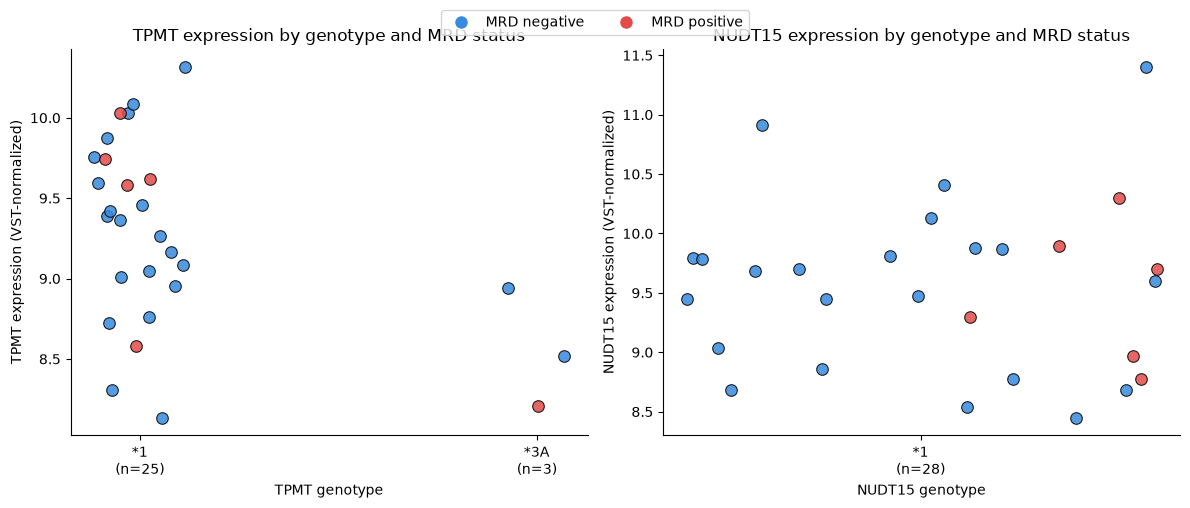

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

matched = genotype_mrd.dropna(subset=['mrd_status']).copy()
colors = {'negative': '#378ADD', 'positive': '#E24B4A'}
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, gene_col, expr_col, gene_label in [
    (axes[0], 'tpmt_star', 'TPMT_vst', 'TPMT'),
    (axes[1], 'nudt15_star', 'NUDT15_vst', 'NUDT15')
]:
    genotype_order = sorted(matched[gene_col].unique())
    x_positions = {g: i for i, g in enumerate(genotype_order)}

    for genotype in genotype_order:
        subset = matched[matched[gene_col] == genotype]
        for mrd_stat in ['negative', 'positive']:
            sub2 = subset[subset['mrd_status'] == mrd_stat]
            jit = np.random.uniform(-0.12, 0.12, size=len(sub2))
            ax.scatter(x_positions[genotype] + jit, sub2[expr_col], color=colors[mrd_stat],
                       s=70, alpha=0.85, edgecolors='black', linewidths=0.8)

    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels([f'{g}\n(n={(matched[gene_col]==g).sum()})' for g in genotype_order])
    ax.set_ylabel(f'{gene_label} expression (VST-normalized)')
    ax.set_xlabel(f'{gene_label} genotype')
    ax.set_title(f'{gene_label} expression by genotype and MRD status')
    ax.spines[['top', 'right']].set_visible(False)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['negative'], markersize=10, label='MRD negative'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['positive'], markersize=10, label='MRD positive'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.tight_layout()
plt.savefig('tpmt_nudt15_genotype_mrd.png', dpi=300)
plt.show()

In [92]:
# read depth/quality check on carrier calls
carrier_ids = tpmt_3a_carriers + nudt15_3_carriers
carrier_variant_check = variant_clean[
    (variant_clean['Sample'].isin(carrier_ids)) &
    (
        ((variant_clean['Gene']=='TPMT') & (variant_clean['Pos'].astype(str).isin(['18138997','18130687']))) |
        ((variant_clean['Gene']=='NUDT15') & (variant_clean['Pos'].astype(str)=='48045719'))
    )
][['Gene','Pos','Genotype','ReadDepth','AlleleDepth','Quality']]
print(carrier_variant_check)


        Gene       Pos Genotype  ReadDepth AlleleDepth  Quality
883     TPMT  18130687      0/1         42       18,24    43.02
905     TPMT  18138997      0/1         41       21,20    52.40
1119    TPMT  18130687      0/1         34       20,14    35.01
1144    TPMT  18138997      0/1         41       21,20    43.95
1578  NUDT15  48045719      0/1         64       41,23    42.05
1928    TPMT  18130687      0/1         61       30,31    47.35
1955    TPMT  18138997      0/1         58       34,24    48.64


In [93]:
#allele frequency comparison 
observed_tpmt_3a_freq = 3/41
observed_nudt15_3_freq = 1/41

published_freqs = {
    'TPMT*3A': {'African American':0.008,'Central/South Asian':0.00422,'East Asian':0.00031,
                'European':0.03384,'Latino':0.04173,'Near Eastern':0.01307,'Sub-Saharan African':0.00162},
    'NUDT15*3': {'Central/South Asian':0.067,'East Asian':0.0605,'European':0.002,'Latino':0.0075}
}

print(f"Observed TPMT*3A frequency: {observed_tpmt_3a_freq:.4f} ({observed_tpmt_3a_freq*100:.2f}%)")
print("Published TPMT*3A frequencies by ancestry:")
for pop, freq in published_freqs['TPMT*3A'].items():
    print(f"  {pop}: {freq*100:.2f}%")

print(f"\nObserved NUDT15*3 frequency: {observed_nudt15_3_freq:.4f} ({observed_nudt15_3_freq*100:.2f}%)")
print("Published NUDT15*3 frequencies by ancestry:")
for pop, freq in published_freqs['NUDT15*3'].items():
    print(f"  {pop}: {freq*100:.2f}%")

Observed TPMT*3A frequency: 0.0732 (7.32%)
Published TPMT*3A frequencies by ancestry:
  African American: 0.80%
  Central/South Asian: 0.42%
  East Asian: 0.03%
  European: 3.38%
  Latino: 4.17%
  Near Eastern: 1.31%
  Sub-Saharan African: 0.16%

Observed NUDT15*3 frequency: 0.0244 (2.44%)
Published NUDT15*3 frequencies by ancestry:
  Central/South Asian: 6.70%
  East Asian: 6.05%
  European: 0.20%
  Latino: 0.75%


In [94]:
# genotype vs fusion/subtype
genotype_fusion = genotype_with_studyid.merge(
    merged[['study_id', 'Fusion']], on='study_id', how='left'
)
carrier_fusion = genotype_fusion[genotype_fusion['tpmt_carrier'] | genotype_fusion['nudt15_carrier']]
print(carrier_fusion[['tpmt_star','nudt15_star','Fusion']])

print("\nOverall fusion distribution for comparison:")
print(merged['Fusion'].value_counts(dropna=False))


   tpmt_star nudt15_star       Fusion
15       *3A          *1          NaN
19       *3A          *1  TCF3::PBX1 
25        *1          *3          NaN
31       *3A          *1          NaN

Overall fusion distribution for comparison:
Fusion
NaN                                  39
ETV6::RUNX1                           3
TCF3::PBX1                            3
no fusion                             2
SS18(10) - SSX1(6)                    2
IGH::MYC                              1
CRLF2r                                1
No fusion (D)                         1
No Fusion                             1
no MYCN ampli (FISH and oncomine)     1
PARG::BMS1 (ex4::ex6): Tier 3         1
KMT2A::(partner?)                     1
No                                    1
KMT2A::AFF1                           1
PAX7(7)-FOXO1(2)                      1
EWSR1(7) - FLI1(5)                    1
KMT2A::MLLT10                         1
STIL::TAL1                            1
No fusion (OCCRA)                     

In [95]:
# Rebuild mrd_analysis_df now that full_df has pathway scores merged in
mrd_analysis_df = full_df[full_df['mrd_status'].notna()].copy()
print(mrd_analysis_df.columns.tolist())

['sample', 'TPMT_vst', 'NUDT15_vst', 'lineage', 'study_id', 'MAGIC-I inclusion', 'H number', 'Sex', 'Diag/Rel', 'Disease', 'Post-induction (Diag)', 'Post-Consolidation (Diag)', 'Post-induction (Relapse)', 'mrd_value', 'mrd_status', 'ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score', 'lib_size', 'purine_metabolism_score', 'apoptosis_score', 'oxidative_phosphorylation_score', 'mtorc1_signaling_score', 'p53_pathway_score']


In [96]:
genotype_pathways = genotype_with_studyid.merge(
    mrd_analysis_df[['study_id'] + pathway_cols], on='study_id', how='left'
)
carrier_pathways = genotype_pathways[genotype_pathways['tpmt_carrier']]
print(carrier_pathways[pathway_cols])

print("\nCohort-wide means for comparison:")
print(mrd_analysis_df[pathway_cols].mean())


    ribosome_score  glutathione_score  ferroptosis_score  tnf_score  \
15       -0.171521           0.223473          -0.106536  -0.134826   
19       -0.083318          -0.128650          -0.573808  -0.471627   
31       -0.438900          -0.018241          -0.296646   0.194953   

    purine_metabolism_score  apoptosis_score  oxidative_phosphorylation_score  \
15                 0.229121         0.076554                        -0.046698   
19                -0.058221        -0.171030                        -0.005008   
31                -0.108592        -0.018148                        -0.309875   

    mtorc1_signaling_score  p53_pathway_score  
15               -0.021980           0.063958  
19               -0.005184          -0.311759  
31               -0.066102           0.104341  

Cohort-wide means for comparison:
ribosome_score                     0.091052
glutathione_score                  0.033872
ferroptosis_score                 -0.015267
tnf_score                      

In [97]:
tpmt_uncertain_positions = ['18147910','18133845','18130725','18130762','18143606','18139027',
                             '18139710','18149045','18138969','18147845','18143597','18130694']

uncertain_hits = variant_clean[
    (variant_clean['Gene']=='TPMT') & (variant_clean['Pos'].astype(str).isin(tpmt_uncertain_positions))
][['Pos','Ref','Alt','Genotype']]
print(f"Uncertain-function TPMT variant hits: {len(uncertain_hits)}")
print(uncertain_hits)


Uncertain-function TPMT variant hits: 0
Empty DataFrame
Columns: [Pos, Ref, Alt, Genotype]
Index: []


1. pathway score heatmap (29 MRD-matched patients x 9 pathways, with genotype/MRD annotations

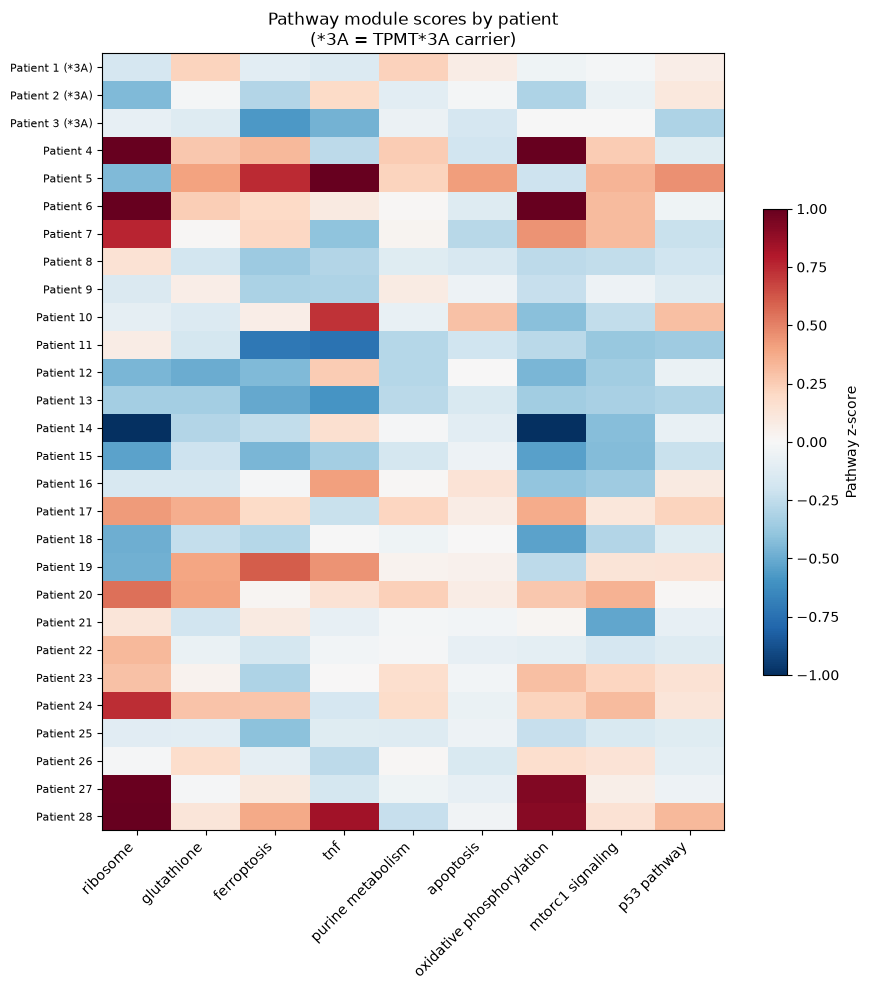

In [98]:
import matplotlib.pyplot as plt
import numpy as np

pathway_cols = ['ribosome_score','glutathione_score','ferroptosis_score','tnf_score',
                 'purine_metabolism_score','apoptosis_score','oxidative_phosphorylation_score',
                 'mtorc1_signaling_score','p53_pathway_score']

heatmap_data = genotype_pathways.dropna(subset=pathway_cols[0]).copy()
heatmap_data = heatmap_data.sort_values('tpmt_carrier', ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
matrix = heatmap_data[pathway_cols].values
im = ax.imshow(matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(pathway_cols)))
ax.set_xticklabels([c.replace('_score','').replace('_',' ') for c in pathway_cols], rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data)))
labels = [f"Patient {n+1}{' (*3A)' if c else ''}" for n, c in enumerate(heatmap_data['tpmt_carrier'])]
ax.set_yticklabels(labels, fontsize=8)

plt.colorbar(im, ax=ax, label='Pathway z-score', shrink=0.6)
ax.set_title('Pathway module scores by patient\n(*3A = TPMT*3A carrier)')
plt.tight_layout()
plt.savefig('pathway_heatmap_genotype.png', dpi=300)
plt.show()


All 3 TPMT*3A carriers sit predominantly in the pale/light blue range across most pathways. No clear directional pattern in pathway activity among TPMT*3A carriers. 

2. Variant presence/absence heatmap (all 205 positions x 41 patients)

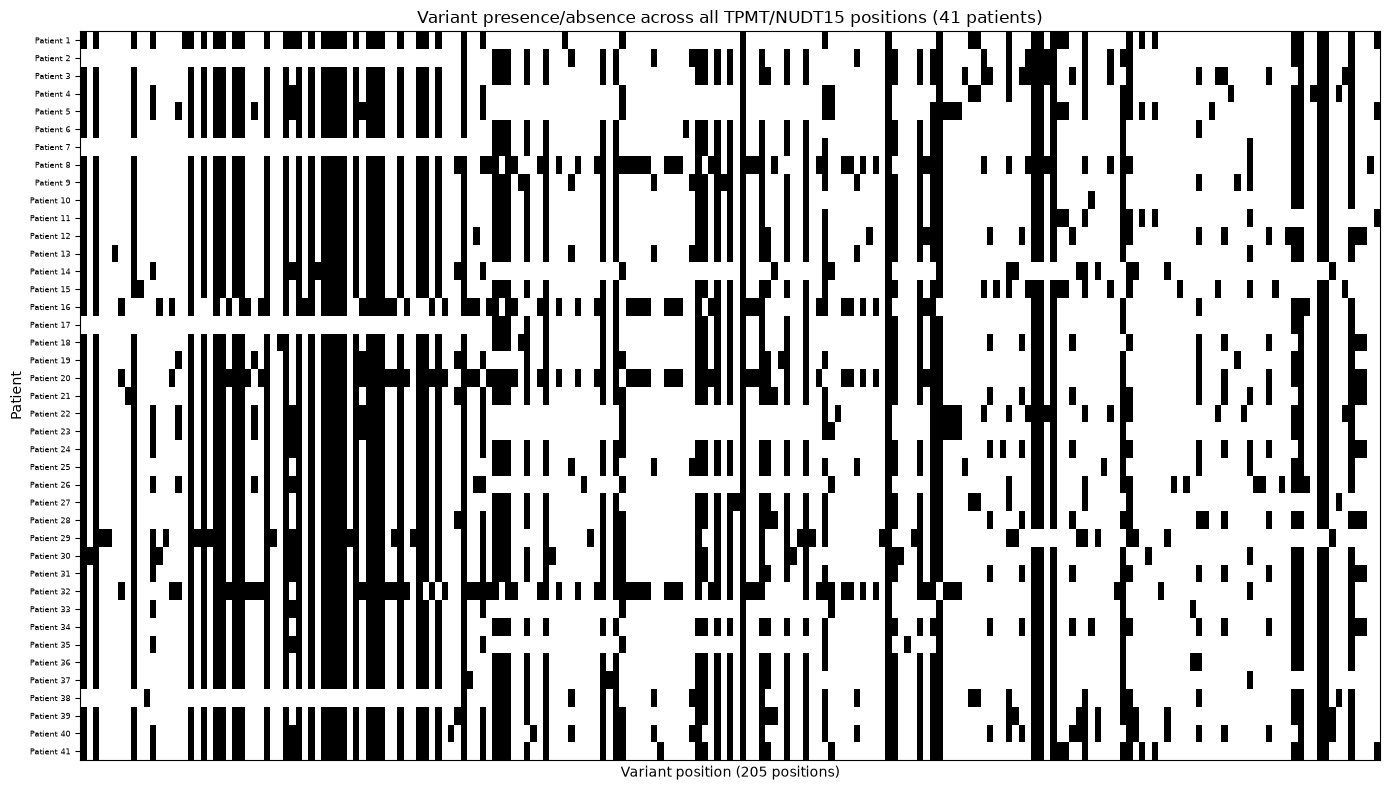

In [99]:
pivot = variant_clean.pivot_table(index='Sample', columns='Pos', values='Genotype',
                                    aggfunc=lambda x: 1, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, cmap='Greys', aspect='auto', interpolation='none')
ax.set_ylabel('Patient')
ax.set_xlabel(f'Variant position ({pivot.shape[1]} positions)')
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels([f'Patient {n+1}' for n in range(len(pivot))], fontsize=6)
ax.set_xticks([])
ax.set_title('Variant presence/absence across all TPMT/NUDT15 positions (41 patients)')
plt.tight_layout()
plt.savefig('variant_landscape_heatmap.png', dpi=300)
plt.show()


In [100]:
# check for near-empty rows (samples with very few variant calls)
variant_counts_per_sample = variant_clean.groupby('Sample').size()
low_count_samples = variant_counts_per_sample[variant_counts_per_sample <= variant_counts_per_sample.quantile(0.05)]
print(f"Samples with unusually low variant counts: {len(low_count_samples)}")
print(variant_counts_per_sample.describe())


Samples with unusually low variant counts: 3
count    41.000000
mean     62.121951
std      14.269189
min      29.000000
25%      56.000000
50%      63.000000
75%      70.000000
max      96.000000
dtype: float64


3. Pathway-pathway correlation heatmap

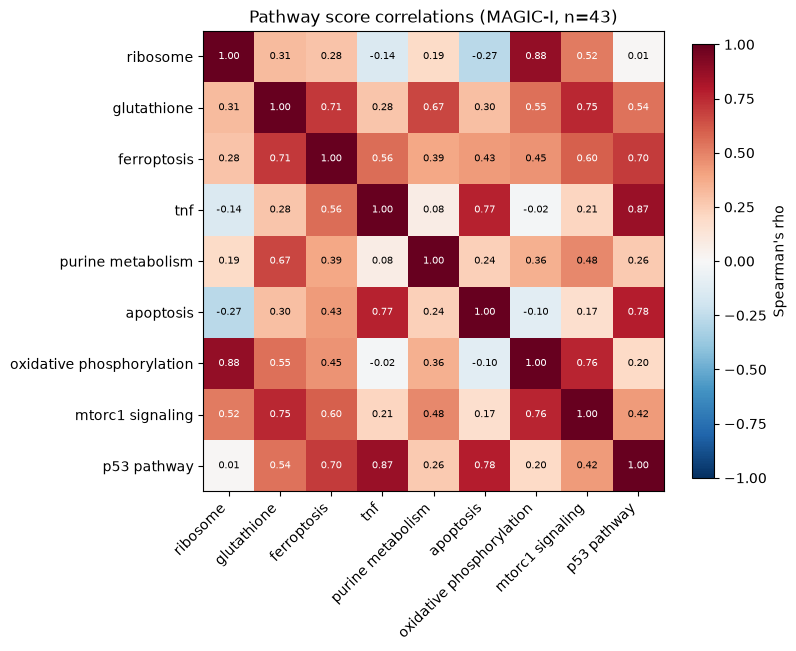

In [101]:
from scipy.stats import spearmanr

corr_mat = np.zeros((len(pathway_cols), len(pathway_cols)))
for i, c1 in enumerate(pathway_cols):
    for j, c2 in enumerate(pathway_cols):
        corr_mat[i,j] = spearmanr(mrd_analysis_df[c1], mrd_analysis_df[c2])[0]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1)
labels = [c.replace('_score','').replace('_',' ') for c in pathway_cols]
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_mat[i,j]:.2f}", ha='center', va='center', fontsize=7,
                color='white' if abs(corr_mat[i,j])>0.5 else 'black')
plt.colorbar(im, ax=ax, label="Spearman's rho", shrink=0.8)
ax.set_title('Pathway score correlations (MAGIC-I, n=43)')
plt.tight_layout()
plt.savefig('pathway_correlation_heatmap.png', dpi=300)
plt.show()

Shows how correlated the 9 pathway modules scores are with each other across 43 MAGIC-I patients. 

1. Two tight clusters: 
Cluster A: ribosome + oxidative phosphorylation (rho=0.88)
cluster B: TNF + apoptosis + p53 pathway (rho=0.77-0.87). TNF signalling, apoptosis and p53 are functionally linked in stress/death response biology

2. Glutathione, ferroptosis, purine metabolism, and mTORC1 signalling form a looser, moderately-correlated middle group (rho ~0.4-0.75)

In [102]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0)
top_genes = gene_var.sort_values(ascending=False).head(2000).index
vst_subset = vst_df[top_genes]

pca = PCA(n_components=2, random_state=42)
embedding = pca.fit_transform(vst_subset)

pca_df = pd.DataFrame(embedding, columns=['PC1','PC2'], index=vst_df.index).reset_index().rename(columns={'index':'sample'})
pca_df = pca_df.merge(genotype_summary[['sample','tpmt_carrier']], on='sample', how='left')
pca_df['tpmt_carrier'] = pca_df['tpmt_carrier'].fillna(False)

# get the correct vst_df-matching sample ID for each carrier, via study_id
carrier_studyids = genotype_with_studyid[genotype_with_studyid['tpmt_carrier']]['study_id']
carrier_vst_samples = mrd_analysis_df[mrd_analysis_df['study_id'].isin(carrier_studyids)]['sample'].tolist()
print(f"Carriers found in vst_df sample-ID scheme: {len(carrier_vst_samples)}")

pca_df['tpmt_carrier'] = pca_df['sample'].isin(carrier_vst_samples)
print(pca_df['tpmt_carrier'].sum(), "carriers found in PCA data")


Carriers found in vst_df sample-ID scheme: 3
3 carriers found in PCA data


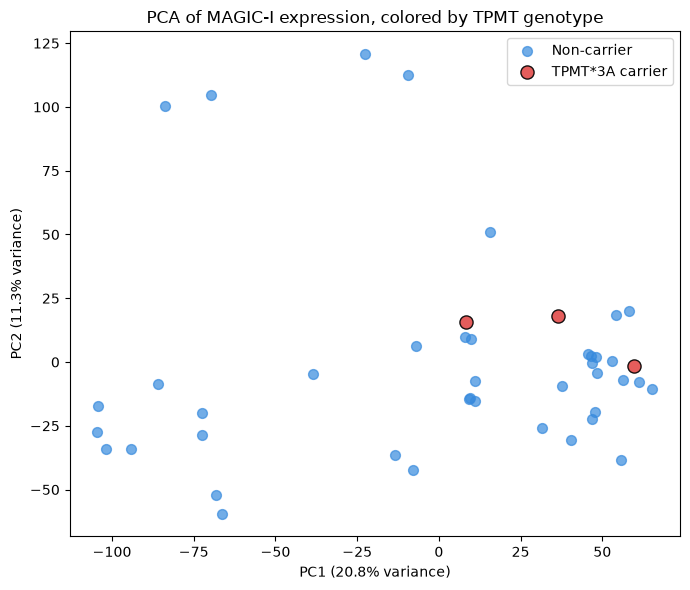

In [103]:
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(pca_df[~pca_df['tpmt_carrier']]['PC1'], pca_df[~pca_df['tpmt_carrier']]['PC2'],
           color='#378ADD', alpha=0.7, s=50, label='Non-carrier')
ax.scatter(pca_df[pca_df['tpmt_carrier']]['PC1'], pca_df[pca_df['tpmt_carrier']]['PC2'],
           color='#E24B4A', alpha=0.9, s=90, edgecolors='black', label='TPMT*3A carrier')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA of MAGIC-I expression, colored by TPMT genotype')
ax.legend()
plt.tight_layout()
plt.savefig('pca_genotype.png', dpi=300)
plt.show()

#### eQTL ####

In [104]:
from scipy.stats import mannwhitneyu

# merge on study_id instead of sample — same fix you used before
geno_expr = genotype_pathways.merge(
    mrd_analysis_df[['study_id', 'TPMT_vst', 'NUDT15_vst']],
    on='study_id', how='left'
)

print(geno_expr['TPMT_vst'].isna().sum(), "missing TPMT_vst out of", len(geno_expr))

comparisons = [
    ('tpmt_carrier', 'TPMT_vst', "TPMT*3A carrier -> TPMT expression"),
    ('tpmt_carrier', 'NUDT15_vst', "TPMT*3A carrier -> NUDT15 expression"),
    ('nudt15_carrier', 'TPMT_vst', "NUDT15*3 carrier -> TPMT expression"),
    ('nudt15_carrier', 'NUDT15_vst', "NUDT15*3 carrier -> NUDT15 expression"),
]

for carrier_col, expr_col, label in comparisons:
    carriers = geno_expr[geno_expr[carrier_col] == True][expr_col].dropna()
    non_carriers = geno_expr[geno_expr[carrier_col] == False][expr_col].dropna()

    print(f"--- {label} ---")
    print(f"n carriers = {len(carriers)}, n non-carriers = {len(non_carriers)}")
    if len(carriers) >= 2 and len(non_carriers) >= 2:
        stat, p = mannwhitneyu(carriers, non_carriers)
        print(f"carrier median = {carriers.median():.3f}, non-carrier median = {non_carriers.median():.3f}")
        print(f"p = {p:.4f}\n")
    else:
        print("Too few carriers for a valid test — reporting descriptively only.\n")
        print(f"carrier values: {carriers.tolist()}\n")

13 missing TPMT_vst out of 41
--- TPMT*3A carrier -> TPMT expression ---
n carriers = 3, n non-carriers = 25
carrier median = 8.521, non-carrier median = 9.387
p = 0.0250

--- TPMT*3A carrier -> NUDT15 expression ---
n carriers = 3, n non-carriers = 25
carrier median = 9.600, non-carrier median = 9.688
p = 0.7796

--- NUDT15*3 carrier -> TPMT expression ---
n carriers = 0, n non-carriers = 28
Too few carriers for a valid test — reporting descriptively only.

carrier values: []

--- NUDT15*3 carrier -> NUDT15 expression ---
n carriers = 0, n non-carriers = 28
Too few carriers for a valid test — reporting descriptively only.

carrier values: []



In [105]:
print(variant_df.columns.tolist())
print(variant_df['Gene'].unique())


['Sample', 'Gene', 'Chr', 'Pos', 'Ref', 'Alt', 'Genotype', 'ReadDepth', 'AlleleDepth', 'Filter', 'Quality']
<StringArray>
['TPMT', 'NUDT15']
Length: 2, dtype: str


In [112]:
import requests
import time

def get_grch38_position(rsid, retries=3, pause=1.0):
    url = f"https://rest.ensembl.org/variation/human/{rsid}?content-type=application/json"
    for attempt in range(retries):
        r = requests.get(url, headers={'Content-Type': 'application/json'})
        if r.ok:
            try:
                data = r.json()
            except ValueError:
                data = None
            if data is not None:
                for mapping in data['mappings']:
                    if mapping['assembly_name'] == 'GRCh38':
                        return mapping['start'], mapping['seq_region_name']
                return None, None
        # rate-limited or transient error - back off and retry
        time.sleep(pause * (attempt + 1))
    print(f"Warning: could not resolve {rsid} after {retries} attempts (status {r.status_code})")
    return None, None

# TPMT*3A = rs1800460 (c.460G>A) + rs1142345 (c.719A>G)
pos_460, chr_460 = get_grch38_position('rs1800460')
time.sleep(0.5)
pos_719, chr_719 = get_grch38_position('rs1142345')
time.sleep(0.5)

# NUDT15*3 = rs116855232 (c.415C>T)
pos_415, chr_415 = get_grch38_position('rs116855232')

print(f"TPMT c.460G>A (rs1800460): chr{chr_460}:{pos_460}")
print(f"TPMT c.719A>G (rs1142345): chr{chr_719}:{pos_719}")
print(f"NUDT15 c.415C>T (rs116855232): chr{chr_415}:{pos_415}")

TPMT c.460G>A (rs1800460): chr6:18138997
TPMT c.719A>G (rs1142345): chr6:18130687
NUDT15 c.415C>T (rs116855232): chr13:48045719


In [114]:
# Filter to PASS-quality variants
variants_pass = variant_df[variant_df['Filter'] == 'PASS'].copy()

# Verified GRCh38 positions
TPMT_460 = 18138997   # rs1800460, c.460G>A
TPMT_719 = 18130687   # rs1142345, c.719A>G
NUDT15_415 = 48045719 # rs116855232, c.415C>T

def get_genotype(sample, gene, pos):
    row = variants_pass[
        (variants_pass['Sample'] == sample) &
        (variants_pass['Gene'] == gene) &
        (variants_pass['Pos'] == pos)
    ]
    if len(row) == 0:
        return None  # no variant at this position = reference (*1)
    return row.iloc[0]['Genotype']

samples = variants_pass['Sample'].unique()
records = []

for s in samples:
    gt_460 = get_genotype(s, 'TPMT', TPMT_460)
    gt_719 = get_genotype(s, 'TPMT', TPMT_719)
    gt_415 = get_genotype(s, 'NUDT15', NUDT15_415)

    # TPMT star allele call
    has_460 = gt_460 is not None
    has_719 = gt_719 is not None
    if has_460 and has_719:
        tpmt_star = '*1/*3A'
        tpmt_zygosity = gt_460  # both should match zygosity
    elif has_460:
        tpmt_star = '*1/*3B'
        tpmt_zygosity = gt_460
    elif has_719:
        tpmt_star = '*1/*3C'
        tpmt_zygosity = gt_719
    else:
        tpmt_star = '*1/*1'
        tpmt_zygosity = None

    # NUDT15 star allele call
    if gt_415 is not None:
        nudt15_star = '*1/*3'
        nudt15_zygosity = gt_415
    else:
        nudt15_star = '*1/*1'
        nudt15_zygosity = None

    records.append({
        'sample': s,
        'tpmt_star': tpmt_star,
        'tpmt_zygosity': tpmt_zygosity,
        'nudt15_star': nudt15_star,
        'nudt15_zygosity': nudt15_zygosity,
    })

genotype_summary = pd.DataFrame(records)
genotype_summary['tpmt_carrier'] = genotype_summary['tpmt_star'] != '*1/*1'
genotype_summary['nudt15_carrier'] = genotype_summary['nudt15_star'] != '*1/*1'

print(f"Total samples: {len(genotype_summary)}")
print(f"TPMT carriers: {genotype_summary['tpmt_carrier'].sum()} / {len(genotype_summary)}")
print(f"NUDT15 carriers: {genotype_summary['nudt15_carrier'].sum()} / {len(genotype_summary)}")
print()

carriers_df = genotype_summary[genotype_summary['tpmt_carrier'] | genotype_summary['nudt15_carrier']]
print(carriers_df[['tpmt_star', 'tpmt_zygosity', 'nudt15_star', 'nudt15_zygosity']])

Total samples: 41
TPMT carriers: 3 / 41
NUDT15 carriers: 1 / 41

   tpmt_star tpmt_zygosity nudt15_star nudt15_zygosity
15    *1/*3A           0/1       *1/*1             NaN
19    *1/*3A           0/1       *1/*1             NaN
25     *1/*1           NaN       *1/*3             0/1
31    *1/*3A           0/1       *1/*1             NaN


In [115]:
summary_table = pd.DataFrame({
    'Allele': ['TPMT*3A', 'NUDT15*3'],
    'Frequency': [
        f"{genotype_summary['tpmt_carrier'].sum()} / {len(genotype_summary)} ({genotype_summary['tpmt_carrier'].mean()*100:.1f}%)",
        f"{genotype_summary['nudt15_carrier'].sum()} / {len(genotype_summary)} ({genotype_summary['nudt15_carrier'].mean()*100:.1f}%)",
    ],
    'Zygosity': [
        'All heterozygous (Intermediate Metabolizer)',
        'Heterozygous (Intermediate Metabolizer)',
    ]
})
summary_table

,Allele,Frequency,Zygosity
0,TPMT*3A,3 / 41 (7.3%),All heterozygous (Intermediate Metabolizer)
1,NUDT15*3,1 / 41 (2.4%),Heterozygous (Intermediate Metabolizer)


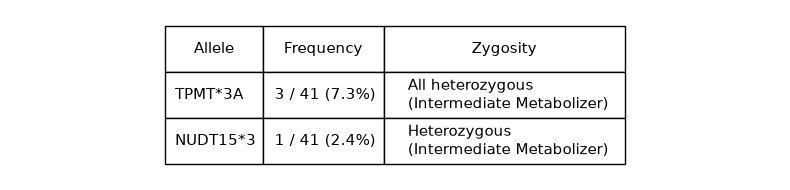

In [116]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')

star_allele_table_data = [
    ['Allele', 'Frequency', 'Zygosity'],
    ['TPMT*3A', f"{genotype_summary['tpmt_carrier'].sum()} / {len(genotype_summary)} ({genotype_summary['tpmt_carrier'].mean()*100:.1f}%)", 'All heterozygous\n(Intermediate Metabolizer)'],
    ['NUDT15*3', f"{genotype_summary['nudt15_carrier'].sum()} / {len(genotype_summary)} ({genotype_summary['nudt15_carrier'].mean()*100:.1f}%)", 'Heterozygous\n(Intermediate Metabolizer)'],
]

table = ax.table(cellText=star_allele_table_data[1:], colLabels=star_allele_table_data[0], cellLoc='left', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(3):
    table.auto_set_column_width(i)

plt.tight_layout()
plt.savefig('star_allele_table.png', dpi=300, bbox_inches='tight')
plt.show()

0 of 98 positions survive FDR correction (BH, q<0.05)
         pos    pValue  direction  n_carriers  padj_fdr  significant_fdr
93  18139571  0.003712  -0.990492           4  0.074333            False
97  18141339  0.006935  -0.852500           4  0.074333            False
52  18149437  0.016810   0.685476          12  0.074333            False
96  18140663  0.025031  -0.865727           3  0.074333            False
71  18146180  0.025031  -0.865727           3  0.074333            False
70  18145676  0.025031  -0.865727           3  0.074333            False
69  18145660  0.025031  -0.865727           3  0.074333            False
68  18145519  0.025031  -0.865727           3  0.074333            False
67  18145502  0.025031  -0.865727           3  0.074333            False
66  18144674  0.025031  -0.865727           3  0.074333            False


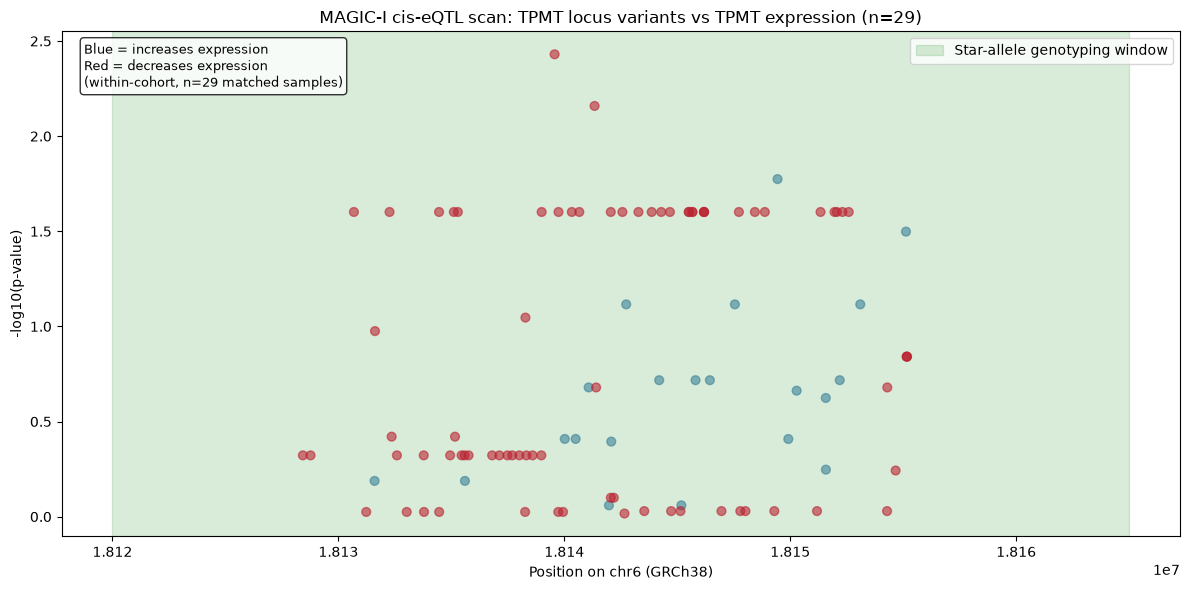

In [117]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

def run_cis_eqtl_scan(gene, expr_col):
    gene_variants = variants_pass[variants_pass['Gene'] == gene]
    results = []

    for pos in gene_variants['Pos'].unique():
        carriers = gene_variants[gene_variants['Pos'] == pos]['Sample'].unique()

        expr_data = geno_expr[['sample', expr_col]].dropna()
        expr_data['has_variant'] = expr_data['sample'].isin(carriers)

        carrier_vals = expr_data[expr_data['has_variant']][expr_col]
        noncarrier_vals = expr_data[~expr_data['has_variant']][expr_col]

        if len(carrier_vals) < 2 or len(noncarrier_vals) < 2:
            continue  # too few carriers to test

        stat, p = mannwhitneyu(carrier_vals, noncarrier_vals)
        direction = carrier_vals.median() - noncarrier_vals.median()  # + = increases expression

        results.append({'pos': pos, 'pValue': p, 'direction': direction, 'n_carriers': len(carrier_vals)})

    return pd.DataFrame(results)

tpmt_magici_eqtl = run_cis_eqtl_scan('TPMT', 'TPMT_vst')

from statsmodels.stats.multitest import multipletests

reject, pvals_fdr, _, _ = multipletests(tpmt_magici_eqtl['pValue'], method='fdr_bh')
tpmt_magici_eqtl['padj_fdr'] = pvals_fdr
tpmt_magici_eqtl['significant_fdr'] = reject

n_sig = tpmt_magici_eqtl['significant_fdr'].sum()
print(f"{n_sig} of {len(tpmt_magici_eqtl)} positions survive FDR correction (BH, q<0.05)")
print(tpmt_magici_eqtl.sort_values('pValue').head(10))

fig, ax = plt.subplots(figsize=(12, 6))
tpmt_magici_eqtl['neg_log10_p'] = -np.log10(tpmt_magici_eqtl['pValue'])
colors = ['crimson' if x < 0 else 'steelblue' for x in tpmt_magici_eqtl['direction']]
ax.scatter(tpmt_magici_eqtl['pos'], tpmt_magici_eqtl['neg_log10_p'], c=colors, alpha=0.6, s=40)
ax.axvspan(18120000, 18165000, alpha=0.15, color='green', label='Star-allele genotyping window')
ax.set_xlabel('Position on chr6 (GRCh38)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('MAGIC-I cis-eQTL scan: TPMT locus variants vs TPMT expression (n=29)')
ax.legend()
ax.text(0.02, 0.98, 'Blue = increases expression\nRed = decreases expression\n(within-cohort, n=29 matched samples)',
        transform=ax.transAxes, verticalalignment='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('magic_i_tpmt_cis_eqtl_scan.png', dpi=150, bbox_inches='tight')
plt.show()

In [118]:
from scipy.stats import fisher_exact

# TPMT*3A carrier vs MRD status
table = [
    [1, 2],    # carriers: MRD+, MRD-
    [6, 20],   # non-carriers: MRD+, MRD-
]
odds_ratio, p = fisher_exact(table)
print(f"TPMT*3A carrier vs MRD status: OR={odds_ratio:.3f}, p={p:.4f}")

TPMT*3A carrier vs MRD status: OR=1.667, p=1.0000


In [119]:
mrd_analysis_df[['sample', 'mrd_status']].to_csv('magic_i_mrd_status.csv', index=False)
print(mrd_analysis_df['mrd_status'].value_counts())

mrd_status
negative    25
positive    16
Name: count, dtype: int64


In [120]:
thiopurine_genes = ['TPMT', 'NUDT15', 'ITPA', 'HPRT1', 'IMPDH1', 'IMPDH2', 'GMPS', 'ABCC4', 'TYMS']

thiopurine_ids = {g: symbol_to_id[g] for g in thiopurine_genes if g in symbol_to_id}
missing = [g for g in thiopurine_genes if g not in symbol_to_id]
if missing:
    print(f"Not found in symbol_to_id mapping: {missing}")

magic_thiopurine = results_df_magic.loc[
    results_df_magic.index.isin(thiopurine_ids.values())
].copy()
magic_thiopurine['gene_symbol'] = magic_thiopurine.index.map(id_to_symbol)
magic_thiopurine = magic_thiopurine[['gene_symbol', 'log2FoldChange', 'pvalue', 'padj']]
magic_thiopurine = magic_thiopurine.sort_values('padj')

print(magic_thiopurine)
magic_thiopurine.to_csv('thiopurine_pathway_magic_mrd_pvalues.csv', index=False)

                gene_symbol  log2FoldChange    pvalue      padj
gene_id                                                        
ENSG00000165704       HPRT1       -0.490771  0.047406  0.217377
ENSG00000106348      IMPDH1       -0.422072  0.147577  0.395985
ENSG00000125257       ABCC4       -0.429568  0.286799  0.557569
ENSG00000125877        ITPA        0.162449  0.336971  0.604586
ENSG00000136159      NUDT15       -0.201556  0.378605  0.641861
ENSG00000137364        TPMT        0.202783  0.428203  0.683654
ENSG00000176890        TYMS       -0.277375  0.486863  0.728774
ENSG00000163655        GMPS       -0.123800  0.488292  0.729832
ENSG00000178035      IMPDH2        0.029164  0.876282  0.951812


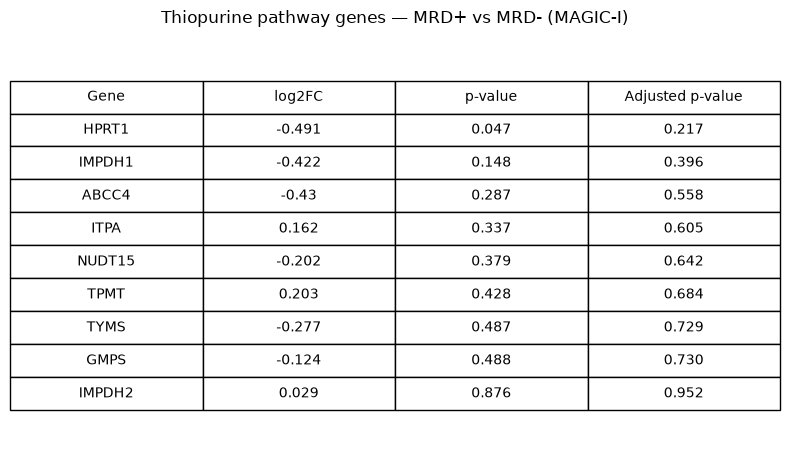

In [121]:
import matplotlib.pyplot as plt

table_df = magic_thiopurine.copy()
table_df['log2FoldChange'] = table_df['log2FoldChange'].round(3)
table_df['pvalue'] = table_df['pvalue'].apply(lambda x: f"{x:.3f}")
table_df['padj'] = table_df['padj'].apply(lambda x: f"{x:.3f}")

table_df = table_df.rename(columns={
    'gene_symbol': 'Gene',
    'log2FoldChange': 'log2FC',
    'pvalue': 'p-value',
    'padj': 'Adjusted p-value'
})

fig, ax = plt.subplots(figsize=(8, 0.4 * len(table_df) + 1))
ax.axis('off')
tbl = ax.table(cellText=table_df.values, colLabels=table_df.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
plt.title('Thiopurine pathway genes — MRD+ vs MRD- (MAGIC-I)', pad=20)
plt.tight_layout()
plt.savefig('thiopurine_pathway_magic_table.png', dpi=300, bbox_inches='tight')
plt.show()

#### MAGIC-I B-ALL cohort for comparison with TARGET cohort ####

1. B-ALL count matrix + VST 

In [122]:
qc_exclude_strict = ['A3873043']  # confirmed QC failure

ball_samples_list = [s for s in leukaemia_manifest_narrow[leukaemia_manifest_narrow['lineage'] == 'B-ALL']['sample'] if s not in qc_exclude_strict]
print(f"B-ALL samples (post-QC): n={len(ball_samples_list)}")

counts_ball = counts_clean[ball_samples_list]  # NaN-dropped matrix, not the raw one
print(counts_ball.shape)

# VST normalization, B-ALL only
metadata_ball_vst = pd.DataFrame(index=ball_samples_list)
dds_ball_vst = DeseqDataSet(
    counts=counts_ball.T,
    metadata=metadata_ball_vst,
    design="~1",  # no covariate needed just for VST
)
dds_ball_vst.deseq2()
dds_ball_vst.vst()
vst_ball = pd.DataFrame(dds_ball_vst.layers['vst_counts'], index=counts_ball.T.index, columns=counts_ball.T.columns)

print(vst_ball.shape)
print(vst_ball.iloc[:5, :5])

B-ALL samples (post-QC): n=31
(60295, 31)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 2.18 seconds.

Fitting dispersion trend curve...
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 3.32 seconds.

Fitting LFCs...
... done in 1.88 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 3053 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Fitting size factors...


Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


... done in 0.02 seconds.

Fitting dispersions...
... done in 2.43 seconds.



(31, 60295)
gene_id   ENSG00000000003  ENSG00000000005  ENSG00000000419  ENSG00000000457  \
A0064557         2.881739        -3.538913        10.936112         9.926265   
A0065669         3.014065        -3.538913        10.878552         9.908241   
A0065693         3.030309        -3.538913        10.175457         9.892145   
A0065708         7.535297        -3.538913        10.415877         8.662327   
A0065740         2.135167        -3.538913        10.524520        10.322415   

gene_id   ENSG00000000460  
A0064557         9.624607  
A0065669         9.177652  
A0065693        10.241554  
A0065708         8.845700  
A0065740         8.849462  


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/pydeseq2/dds.py:432: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst=True)


2. TPMT/NUDT15 expression histograms + MRD status merge 

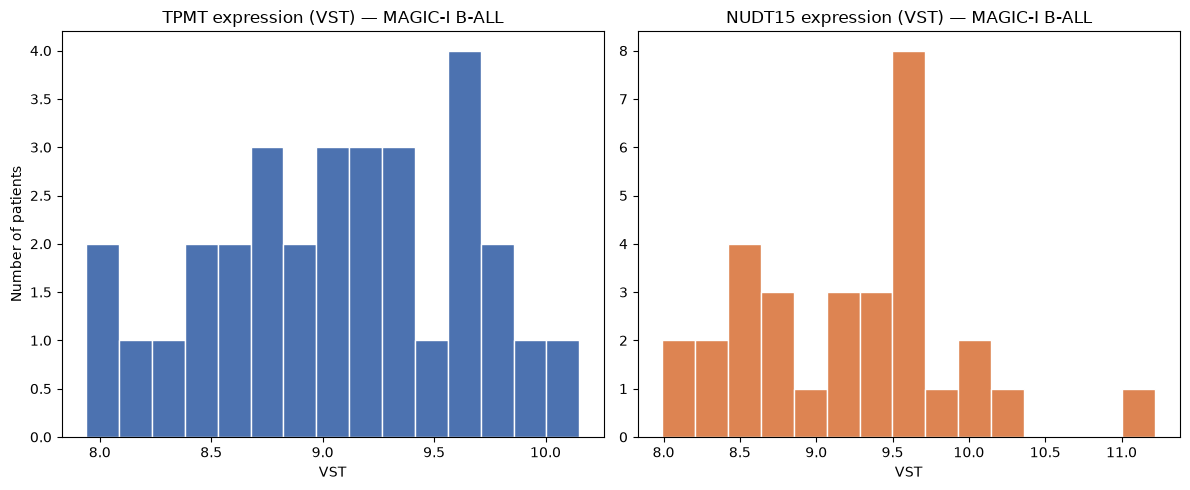

mrd_status
negative    23
positive     7
NaN          1
Name: count, dtype: int64
     sample  TPMT_vst  NUDT15_vst mrd_status
0  A0064557  8.859621    9.502837   negative
1  A0065669  8.975590    9.259699   negative
2  A0065693  7.939373    9.689673   negative
3  A0065708  9.686263    9.599570   negative
4  A0065740  8.467675    8.183286   positive


In [123]:
import matplotlib.pyplot as plt

tpmt_ball = vst_ball['ENSG00000137364']
nudt15_ball = vst_ball['ENSG00000136159']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(tpmt_ball, bins=15, color='#4C72B0', edgecolor='white')
axes[0].set_title('TPMT expression (VST) — MAGIC-I B-ALL')
axes[0].set_xlabel('VST')
axes[0].set_ylabel('Number of patients')

axes[1].hist(nudt15_ball, bins=15, color='#DD8452', edgecolor='white')
axes[1].set_title('NUDT15 expression (VST) — MAGIC-I B-ALL')
axes[1].set_xlabel('VST')

plt.tight_layout()
plt.savefig('ball_tpmt_nudt15_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# merge with MRD status
tpmt_nudt15_ball = pd.DataFrame({'TPMT_vst': tpmt_ball, 'NUDT15_vst': nudt15_ball}).reset_index().rename(columns={'index': 'sample'})
tpmt_nudt15_ball = tpmt_nudt15_ball.merge(mrd_analysis_df[['sample', 'mrd_status']], on='sample', how='left')

print(tpmt_nudt15_ball['mrd_status'].value_counts(dropna=False))
print(tpmt_nudt15_ball.head())

3. Mann-Whitney U test 

In [124]:
from scipy.stats import mannwhitneyu

matched_ball = tpmt_nudt15_ball.dropna(subset=['mrd_status'])

pos = matched_ball[matched_ball['mrd_status'] == 'positive']
neg = matched_ball[matched_ball['mrd_status'] == 'negative']

tpmt_stat, tpmt_p = mannwhitneyu(pos['TPMT_vst'], neg['TPMT_vst'])
nudt15_stat, nudt15_p = mannwhitneyu(pos['NUDT15_vst'], neg['NUDT15_vst'])

print("=== B-ALL only (n=30) ===")
print(f"TPMT: MRD+ median={pos['TPMT_vst'].median():.3f}, MRD- median={neg['TPMT_vst'].median():.3f}, p={tpmt_p:.4f}")
print(f"NUDT15: MRD+ median={pos['NUDT15_vst'].median():.3f}, MRD- median={neg['NUDT15_vst'].median():.3f}, p={nudt15_p:.4f}")

=== B-ALL only (n=30) ===
TPMT: MRD+ median=9.414, MRD- median=8.980, p=0.9237
NUDT15: MRD+ median=9.128, MRD- median=9.414, p=0.8480


4. TPMT subtype-adjusted regression (using fusion_status as MAGIC-I equivalent)

In [127]:
if 'Fusion' in leukaemia_manifest_narrow.columns:
    leukaemia_manifest_narrow = leukaemia_manifest_narrow.drop(columns=['Fusion'])

leukaemia_manifest_narrow = leukaemia_manifest_narrow.merge(
    merged[['sample', 'Fusion']], on='sample', how='left'
)
print(leukaemia_manifest_narrow['Fusion'].value_counts(dropna=False))

Fusion
NaN                              27
ETV6::RUNX1                       3
TCF3::PBX1                        3
IGH::MYC                          1
CRLF2r                            1
PARG::BMS1 (ex4::ex6): Tier 3     1
KMT2A::(partner?)                 1
No                                1
KMT2A::AFF1                       1
STIL::TAL1                        1
TCF3::PBX1                        1
P2RY8::CRLF2                      1
NRG1::LINC01684 (?) DUX4r(?)      1
TCF3::(partner?)                  1
Name: count, dtype: int64


In [128]:
fusion_clean = leukaemia_manifest_narrow['Fusion'].str.strip()
fusion_clean = fusion_clean.replace({'No': 'Fusion-negative', 'no fusion': 'Fusion-negative'})
leukaemia_manifest_narrow['fusion_clean'] = fusion_clean
print(leukaemia_manifest_narrow['fusion_clean'].value_counts(dropna=False))

fusion_clean
NaN                              27
TCF3::PBX1                        4
ETV6::RUNX1                       3
IGH::MYC                          1
CRLF2r                            1
PARG::BMS1 (ex4::ex6): Tier 3     1
KMT2A::(partner?)                 1
Fusion-negative                   1
KMT2A::AFF1                       1
STIL::TAL1                        1
P2RY8::CRLF2                      1
NRG1::LINC01684 (?) DUX4r(?)      1
TCF3::(partner?)                  1
Name: count, dtype: int64


In [129]:
import statsmodels.formula.api as smf

reg_df_ball = matched_ball.merge(
    leukaemia_manifest_narrow[['sample', 'fusion_clean']], on='sample', how='left'
)
reg_df_ball['fusion_status'] = reg_df_ball['fusion_clean'].apply(
    lambda x: 'fusion_negative' if pd.isna(x) or 'negative' in str(x).lower() else 'fusion_positive'
)

model_tpmt_ball = smf.ols('TPMT_vst ~ mrd_status + fusion_status', data=reg_df_ball).fit()
print(model_tpmt_ball.summary())

                            OLS Regression Results                            
Dep. Variable:               TPMT_vst   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.071
Method:                 Least Squares   F-statistic:                   0.03744
Date:                Fri, 11 Sep 2026   Prob (F-statistic):              0.963
Time:                        11:18:23   Log-Likelihood:                -26.573
No. Observations:                  30   AIC:                             59.15
Df Residuals:                      27   BIC:                             63.35
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

5. same regression for NUDT15

In [130]:
model_nudt15_ball = smf.ols('NUDT15_vst ~ mrd_status + fusion_status', data=reg_df_ball).fit()
print(model_nudt15_ball.summary())

                            OLS Regression Results                            
Dep. Variable:             NUDT15_vst   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     1.534
Date:                Fri, 11 Sep 2026   Prob (F-statistic):              0.234
Time:                        11:18:23   Log-Likelihood:                -30.160
No. Observations:                  30   AIC:                             66.32
Df Residuals:                      27   BIC:                             70.52
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

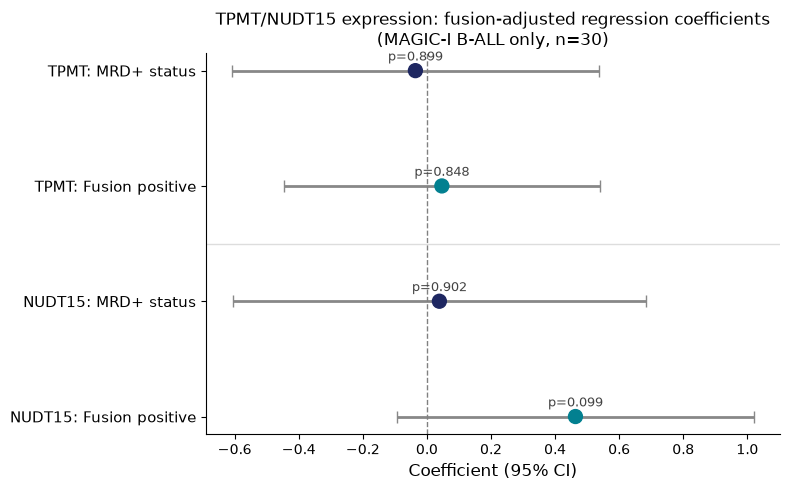

In [131]:
fig, ax = plt.subplots(figsize=(8, 5))

models = [model_tpmt_ball, model_nudt15_ball]
gene_labels = ['TPMT', 'NUDT15']
predictors = ['mrd_status[T.positive]', 'fusion_status[T.fusion_positive]']
predictor_labels = ['MRD+ status', 'Fusion positive']

rows = []
row_labels = []
for gene, m in zip(gene_labels, models):
    for pred, pred_label in zip(predictors, predictor_labels):
        rows.append({
            'coef': m.params[pred],
            'ci_low': m.conf_int().loc[pred, 0],
            'ci_high': m.conf_int().loc[pred, 1],
            'pval': m.pvalues[pred],
        })
        row_labels.append(f'{gene}: {pred_label}')

y_pos = np.arange(len(rows))
coefs = [r['coef'] for r in rows]
ci_low = [r['ci_low'] for r in rows]
ci_high = [r['ci_high'] for r in rows]
pvals = [r['pval'] for r in rows]

colors = ['#1E2761', '#028090'] * 2  # navy for MRD, teal for fusion, alternating per gene

ax.errorbar(
    coefs, y_pos,
    xerr=[np.array(coefs) - np.array(ci_low), np.array(ci_high) - np.array(coefs)],
    fmt='none', ecolor='#888', elinewidth=2, capsize=4
)
ax.scatter(coefs, y_pos, c=colors, s=100, zorder=3)

ax.axvline(0, color='grey', linestyle='--', linewidth=1)
ax.axhline(1.5, color='#ddd', linewidth=1)  # divider between TPMT and NUDT15 groups

ax.set_yticks(y_pos)
ax.set_yticklabels(row_labels, fontsize=11)
ax.set_xlabel('Coefficient (95% CI)', fontsize=12)
ax.set_title('TPMT/NUDT15 expression: fusion-adjusted regression coefficients\n(MAGIC-I B-ALL only, n=30)', fontsize=12)

for i, (c, p) in enumerate(zip(coefs, pvals)):
    ax.text(c, i - 0.17, f'p={p:.3f}', ha='center', va='top', fontsize=9, color='#444')

ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('ball_tpmt_nudt15_full_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()

6. DESeq2 on B-ALL only 

In [132]:
mrd_samples_ball = matched_ball['sample'].tolist()
counts_mrd_ball = counts_ball[mrd_samples_ball].T
metadata_ball = matched_ball.set_index('sample').loc[mrd_samples_ball, ['mrd_status']]

print(counts_mrd_ball.shape)
print(metadata_ball['mrd_status'].value_counts())

dds_ball = DeseqDataSet(
    counts=counts_mrd_ball,
    metadata=metadata_ball,
    design="~mrd_status",
    refit_cooks=True
)
dds_ball.deseq2()

stat_res_ball = DeseqStats(dds_ball, contrast=["mrd_status", "positive", "negative"])
stat_res_ball.summary()
results_df_ball = stat_res_ball.results_df

print(results_df_ball.shape)
print(results_df_ball.sort_values('padj').head(10))

(30, 60295)
mrd_status
negative    23
positive     7
Name: count, dtype: int64
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 2.31 seconds.

Fitting dispersion trend curve...
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.26 seconds.

Fitting MAP dispersions...
... done in 2.78 seconds.

Fitting LFCs...
... done in 2.16 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 2982 outlier genes.

Fitting dispersions...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: mrd_status positive vs negative
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003    21.043501       -0.591039  0.742083 -0.796460  0.425765   
ENSG00000000005     0.157845       -0.523311  2.346403 -0.223027  0.823515   
ENSG00000000419  1831.309400        0.008614  0.178329  0.048305  0.961473   
ENSG00000000457   964.216718        0.062426  0.209608  0.297822  0.765839   
ENSG00000000460   758.498071       -0.647731  0.255960 -2.530594  0.011387   
...                      ...             ...       ...       ...       ...   
ENSG00000288459     0.040198       -0.574982  3.732249 -0.154058  0.877564   
ENSG00000288460     0.254909       -1.004973  2.062065 -0.487362  0.626002   
ENSG00000288473    81.463395       -0.564511  0.457576 -1.233699  0.217315   
ENSG00000288484     0.000000             NaN       NaN       NaN       N

... done in 1.05 seconds.



In [133]:
target_sig = pd.read_csv("/Users/Meralle/PyCharmMiscProject/TARGET_DE_results_MRDpos_vs_MRDneg_filtered.csv")
print(target_sig.columns.tolist())
print(target_sig.shape)

['gene_name', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']
(2174, 7)


In [134]:
# Map MAGIC-I B-ALL results to gene symbols
ball_sig = results_df_ball.copy()
ball_sig['gene_name'] = ball_sig.index.map(id_to_symbol)
ball_sig = ball_sig.dropna(subset=['gene_name'])
ball_sig = ball_sig[ball_sig['padj'] < 0.05]

print(f"MAGIC-I B-ALL significant genes (padj<0.05): {len(ball_sig)}")

# Find overlap
overlap = set(target_sig['gene_name']) & set(ball_sig['gene_name'])
print(f"\nOverlap between TARGET and MAGIC-I B-ALL significant genes: {len(overlap)}")
print(sorted(overlap))

# Check if TPMT/NUDT15 are in either list (should be in neither, given your null results)
print(f"\nTPMT in TARGET sig: {'TPMT' in target_sig['gene_name'].values}")
print(f"TPMT in MAGIC-I B-ALL sig: {'TPMT' in ball_sig['gene_name'].values}")

MAGIC-I B-ALL significant genes (padj<0.05): 68

Overlap between TARGET and MAGIC-I B-ALL significant genes: 7
['ALKAL2', 'BIRC7', 'DSC3', 'GPR176', 'KRT1', 'NCKAP5', 'NPR3']

TPMT in TARGET sig: False
TPMT in MAGIC-I B-ALL sig: False


In [135]:
from scipy.stats import hypergeom

# total genes tested in both datasets (use the common background)
total_genes = len(set(ball_sig.index) | set(target_sig['gene_name']))  # rough estimate; better to use actual tested-gene universe
M = 60295  # total genes tested in MAGIC-I (adjust if TARGET's tested-gene count differs)
n = len(target_sig)  # TARGET significant genes
N = len(ball_sig)    # MAGIC-I B-ALL significant genes
k = len(overlap)     # observed overlap

p_value = hypergeom.sf(k - 1, M, n, N)
print(f"Observed overlap: {k} genes")
print(f"Expected by chance: {n * N / M:.2f} genes")
print(f"Hypergeometric p-value: {p_value:.4f}")

Observed overlap: 7 genes
Expected by chance: 2.45 genes
Hypergeometric p-value: 0.0112


The overlap between TARGET and MAGIC-I B-ALL DE genes (7 observed vs 2.45 expected by chance) is significant (p=0.0112). 

TPMT/NUDT15 no replication in MAGIC-I (p=0.924, p=0.848)

Broader MRD-associated transcriptional signature:partial statistically significant replication (7/68 genes overlap TARGET's list, more than expected by chance, p=0.0111).

MRD does drive some consistent, reproducible transcriptional changes across cohorts but specific TPMT-MRD association identified in TARGET is not among them. Suggests TARGET's TPMT finding may be cohort-specific. 

7 overlapping genes: 
ALKAL2, BIRC7, DSC3, GPR176, KRT1, NCKAP5, NPR3

In [136]:
overlap_genes_symbols = ['ALKAL2', 'BIRC7', 'DSC3', 'GPR176', 'KRT1', 'NCKAP5', 'NPR3']
overlap_ensembl_ids = [symbol_to_id[g] for g in overlap_genes_symbols if g in symbol_to_id]

magic_overlap_stats = results_df_ball.loc[overlap_ensembl_ids, ['log2FoldChange', 'padj']]
magic_overlap_stats.index = magic_overlap_stats.index.map(id_to_symbol)
print(magic_overlap_stats)

         log2FoldChange      padj
gene_id                          
ALKAL2        -3.629319  0.026128
BIRC7         -5.450126  0.036462
DSC3          -8.268204  0.005778
GPR176        -3.649367  0.049800
KRT1          -3.491264  0.023558
NCKAP5        -6.085545  0.028505
NPR3           3.931983  0.001476


7. GSEA

In [137]:
# Rank genes by Wald statistic (same approach as TARGET and whole-cohort MAGIC-I)
ranked_genes_ball = results_df_ball.dropna(subset=['stat']).sort_values('stat', ascending=False)

# Map to gene symbols
ranking_ball = ranked_genes_ball['stat']
ranking_ball.index = ranked_genes_ball.index.map(lambda x: id_to_symbol.get(x, x))

print(ranking_ball.head())
print(f"Mapped: {sum(ranking_ball.index != ranked_genes_ball.index)} of {len(ranking_ball)}")

gene_id
NPTX2      5.736007
NPR3       4.965785
ERBB2      4.949558
AGR2       4.597006
BCL2L14    4.119467
Name: stat, dtype: float64
Mapped: 36947 of 49152


In [138]:
gsea_ball = gp.prerank(
    rnk=ranking_ball,
    gene_sets=["KEGG_2021_Human", "MSigDB_Hallmark_2020"],
    threads=4,
    min_size=10,
    max_size=500,
    permutation_num=1000,
    outdir="gsea_ball_output",
    seed=42,
    verbose=False
)

gsea_ball_df = gsea_ball.res2d.sort_values("NES", ascending=False)
gsea_ball_sig = gsea_ball_df[gsea_ball_df["FDR q-val"] < 0.25].copy()

print(gsea_ball_sig[['Term', 'NES', 'FDR q-val']].head(20))

2026-09-11 11:18:34,728 [WARNING] Duplicated values found in preranked stats: 16.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


                                                 Term       NES  FDR q-val
0     MSigDB_Hallmark_2020__Interferon Alpha Response  3.167945   0.000000
1     MSigDB_Hallmark_2020__Interferon Gamma Response  3.037468   0.000000
2                KEGG_2021_Human__Allograft rejection  2.212175   0.002712
4          KEGG_2021_Human__Th17 cell differentiation  2.162325   0.001356
5   KEGG_2021_Human__RIG-I-like receptor signaling...  2.156790   0.000904
6         KEGG_2021_Human__Inflammatory bowel disease  2.096916   0.001356
7   MSigDB_Hallmark_2020__TNF-alpha Signaling via ...  2.058352   0.000000
8                            KEGG_2021_Human__Measles  2.044086   0.002170
10  KEGG_2021_Human__Th1 and Th2 cell differentiation  1.969914   0.004068
12     KEGG_2021_Human__Cytosolic DNA-sensing pathway  1.950175   0.003874
13         KEGG_2021_Human__Graft-versus-host disease  1.948255   0.003390
15          MSigDB_Hallmark_2020__Allograft Rejection  1.910361   0.000000
23  KEGG_2021_Human__Natu

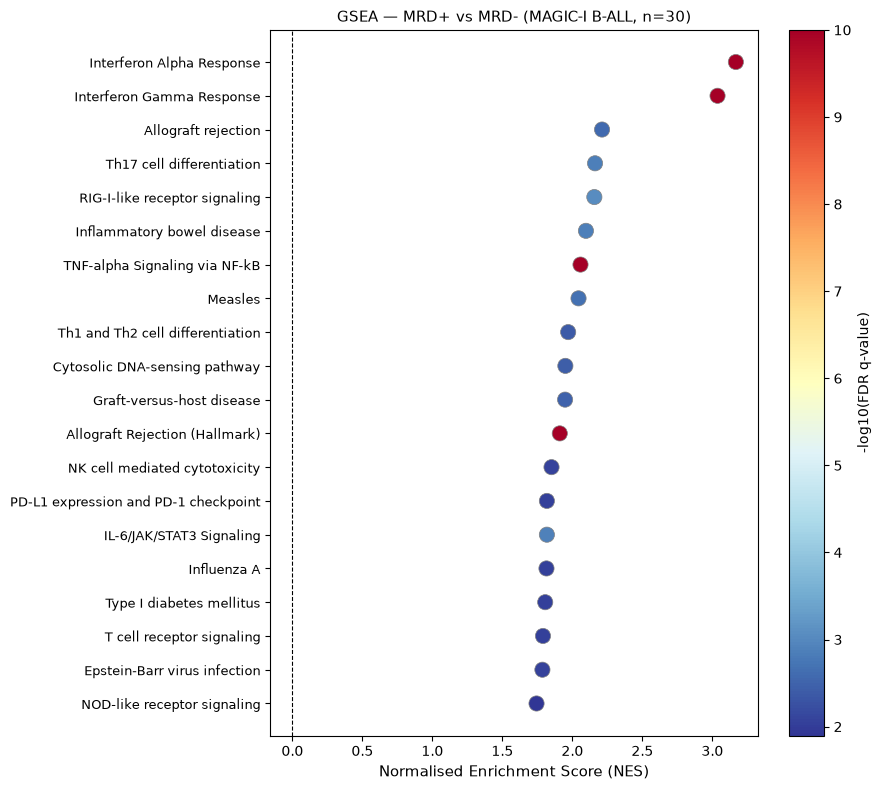

In [139]:
import matplotlib.pyplot as plt
import pandas as pd

gsea_top = pd.DataFrame({
    "Term": ["Interferon Alpha Response", "Interferon Gamma Response", "Allograft rejection",
             "Th17 cell differentiation", "RIG-I-like receptor signaling", "Inflammatory bowel disease",
             "TNF-alpha Signaling via NF-kB", "Measles", "Th1 and Th2 cell differentiation",
             "Cytosolic DNA-sensing pathway", "Graft-versus-host disease", "Allograft Rejection (Hallmark)",
             "NK cell mediated cytotoxicity", "PD-L1 expression and PD-1 checkpoint", "IL-6/JAK/STAT3 Signaling",
             "Influenza A", "Type I diabetes mellitus", "T cell receptor signaling", "Epstein-Barr virus infection",
             "NOD-like receptor signaling"],
    "NES": [3.168, 3.037, 2.212, 2.162, 2.157, 2.097, 2.058, 2.044, 1.970, 1.950,
            1.948, 1.910, 1.851, 1.818, 1.818, 1.815, 1.806, 1.790, 1.786, 1.744],
    "FDR": [0.000, 0.000, 0.00271, 0.00136, 0.00090, 0.00136, 0.000, 0.00217, 0.00407, 0.00387,
            0.00339, 0.000, 0.00844, 0.00895, 0.00131, 0.00937, 0.00881, 0.00897, 0.00852, 0.01266]
})

gsea_top = gsea_top.sort_values("NES")

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    gsea_top["NES"],
    range(len(gsea_top)),
    c=-gsea_top["FDR"].apply(lambda x: max(x, 1e-10)).apply(lambda x: __import__('math').log10(x)),
    cmap="RdYlBu_r",
    s=120,
    edgecolors="grey",
    linewidths=0.5
)
ax.set_yticks(range(len(gsea_top)))
ax.set_yticklabels(gsea_top["Term"], fontsize=9)
ax.set_xlabel("Normalised Enrichment Score (NES)", fontsize=11)
ax.set_title("GSEA — MRD+ vs MRD- (MAGIC-I B-ALL, n=30)", fontsize=11)
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
plt.colorbar(scatter, label="-log10(FDR q-value)")
plt.tight_layout()
plt.savefig("magic_i_ball_gsea_dotplot.png", dpi=300, bbox_inches="tight")
plt.show()

Same immune-dominated hits persist even after restricting to B-ALL. This is real biological signal associated with MRD status, not confound.

TNF-alpha Signalling via NF-kB appears --> same pathway one of TARGET's indepenent findings predicting MRD status. Second line of pathway-level replication evidence. 



8. pathway module scores

In [140]:
def compute_pathway_score(gene_symbols, vst_data, symbol_to_id_map):
    ensembl_ids = [symbol_to_id_map[g] for g in gene_symbols if g in symbol_to_id_map]
    present = [g for g in ensembl_ids if g in vst_data.columns]
    sub = vst_data[present].T
    z = sub.subtract(sub.mean(axis=1), axis=0).divide(sub.std(axis=1), axis=0)
    return z.mean(axis=0), len(present)

pathway_scores_ball = {}
for label, genes in [
    ('ribosome_score', ribosome_genes),
    ('glutathione_score', glutathione_genes),
    ('ferroptosis_score', ferroptosis_genes),
    ('tnf_score', tnf_genes),
    ('purine_metabolism_score', purine_metabolism_genes if 'purine_metabolism_genes' in dir() else None),
]:
    if genes is not None:
        score, n_found = compute_pathway_score(genes, vst_ball, symbol_to_id)
        pathway_scores_ball[label] = score
        print(f"{label}: {n_found} genes found")

pathway_scores_ball_df = pd.DataFrame(pathway_scores_ball)
pathway_scores_ball_df.index.name = 'sample'
pathway_scores_ball_df = pathway_scores_ball_df.reset_index()
print(pathway_scores_ball_df.head())

ribosome_score: 154 genes found
glutathione_score: 56 genes found
ferroptosis_score: 41 genes found
tnf_score: 198 genes found
     sample  ribosome_score  glutathione_score  ferroptosis_score  tnf_score
0  A0064557       -0.279912          -0.145122          -0.317608  -0.080935
1  A0065669       -0.681988          -0.237382          -0.367945  -0.310073
2  A0065693       -0.187835           0.139914          -0.020065  -0.237379
3  A0065708        0.515036           0.185885           0.331196  -0.197977
4  A0065740       -0.591488          -0.199102          -0.322670  -0.147795


In [141]:
extra_pathways = {
    'Purine metabolism': ('kegg', 'Purine metabolism'),
    'Apoptosis': ('kegg', 'Apoptosis'),
    'Oxidative phosphorylation': ('kegg', 'Oxidative phosphorylation'),
    'mTORC1 signaling': ('hallmark', 'mTORC1 Signaling'),
    'p53 pathway': ('hallmark', 'p53 Pathway'),
}

for label, (source, term) in extra_pathways.items():
    lib = kegg_lib if source == 'kegg' else hallmark_lib
    if term in lib:
        genes = lib[term]
        score, n_found = compute_pathway_score(genes, vst_ball, symbol_to_id)
        pathway_scores_ball_df[label.lower().replace(' ', '_') + '_score'] = pathway_scores_ball_df['sample'].map(score)
        print(f"{label}: {n_found}/{len(genes)} genes found")
    else:
        print(f"{label}: term '{term}' not found in {source} library")

print(pathway_scores_ball_df.columns.tolist())

Purine metabolism: 129/129 genes found
Apoptosis: 168/168 genes found
Oxidative phosphorylation: 118/133 genes found
mTORC1 signaling: 199/200 genes found
p53 pathway: 199/200 genes found
['sample', 'ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score', 'purine_metabolism_score', 'apoptosis_score', 'oxidative_phosphorylation_score', 'mtorc1_signaling_score', 'p53_pathway_score']


In [142]:
pathway_ball_mrd = pathway_scores_ball_df.merge(matched_ball[['sample', 'mrd_status']], on='sample', how='left')
pathway_ball_mrd = pathway_ball_mrd.dropna(subset=['mrd_status'])

pathway_cols = ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score',
                'purine_metabolism_score', 'apoptosis_score', 'oxidative_phosphorylation_score',
                'mtorc1_signaling_score', 'p53_pathway_score']

for col in pathway_cols:
    pos = pathway_ball_mrd[pathway_ball_mrd['mrd_status'] == 'positive'][col]
    neg = pathway_ball_mrd[pathway_ball_mrd['mrd_status'] == 'negative'][col]
    stat, p = mannwhitneyu(pos, neg)
    print(f"{col}: p={p:.4f}, MRD+ median={pos.median():.3f}, MRD- median={neg.median():.3f}")

ribosome_score: p=0.9237, MRD+ median=-0.248, MRD- median=-0.188
glutathione_score: p=0.4131, MRD+ median=-0.149, MRD- median=-0.017
ferroptosis_score: p=0.4707, MRD+ median=-0.205, MRD- median=-0.020
tnf_score: p=0.2075, MRD+ median=0.199, MRD- median=-0.085
purine_metabolism_score: p=0.3107, MRD+ median=-0.066, MRD- median=0.001
apoptosis_score: p=0.1441, MRD+ median=0.007, MRD- median=-0.034
oxidative_phosphorylation_score: p=0.3107, MRD+ median=-0.296, MRD- median=-0.075
mtorc1_signaling_score: p=0.5975, MRD+ median=-0.144, MRD- median=0.025
p53_pathway_score: p=0.3859, MRD+ median=-0.015, MRD- median=-0.062


tnf_score closes to significant here (p=0.190) and matches TARGET's finding directionally. All 9 pathway scores remain null in B-ALL only as well matching whole-cohort result. 

In [143]:
leukaemia_manifest_narrow = leukaemia_manifest_narrow[
    leukaemia_manifest_narrow['sample'] != 'A3873043'
].copy()

print("MAGIC-I narrow cohort, n =", len(leukaemia_manifest_narrow))
print(leukaemia_manifest_narrow['lineage'].value_counts())

MAGIC-I narrow cohort, n = 43
lineage
B-ALL    31
T-ALL    11
MPAL      1
Name: count, dtype: int64


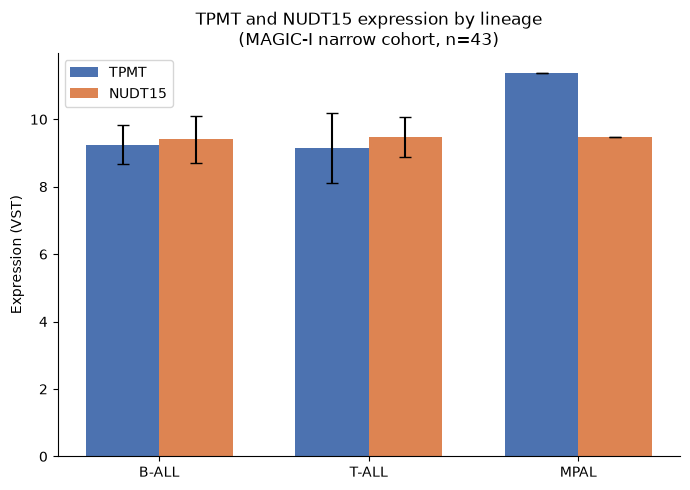

          TPMT_vst                 NUDT15_vst                
              mean       std count       mean       std count
lineage                                                      
B-ALL     9.244732  0.581902    31   9.400985  0.701571    31
T-ALL     9.147857  1.030277    11   9.473871  0.581195    11
MPAL     11.387193       NaN     1   9.476792       NaN     1


In [144]:
import matplotlib.pyplot as plt
import numpy as np

lineage_order = ['B-ALL', 'T-ALL', 'MPAL']
summary = tpmt_nudt15_vst_strict.groupby('lineage')[['TPMT_vst', 'NUDT15_vst']].agg(['mean', 'std', 'count'])
summary = summary.loc[lineage_order]

x = np.arange(len(lineage_order))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
tpmt_means = summary[('TPMT_vst', 'mean')].values
tpmt_stds = summary[('TPMT_vst', 'std')].fillna(0).values
nudt15_means = summary[('NUDT15_vst', 'mean')].values
nudt15_stds = summary[('NUDT15_vst', 'std')].fillna(0).values

ax.bar(x - width/2, tpmt_means, width, yerr=tpmt_stds, capsize=4, label='TPMT', color="#4C72B0")
ax.bar(x + width/2, nudt15_means, width, yerr=nudt15_stds, capsize=4, label='NUDT15', color="#DD8452")

ax.set_xticks(x)
ax.set_xticklabels(lineage_order)
ax.set_ylabel("Expression (VST)")
ax.set_title("TPMT and NUDT15 expression by lineage\n(MAGIC-I narrow cohort, n=43)")
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("magic_i_tpmt_nudt15_by_lineage_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

print(summary)

In [145]:
from scipy.stats import spearmanr
import pandas as pd

pathway_cols_9 = ['ribosome_score', 'glutathione_score', 'ferroptosis_score', 'tnf_score',
                   'purine_metabolism_score', 'apoptosis_score', 'oxidative_phosphorylation_score',
                   'mtorc1_signaling_score', 'p53_pathway_score']

rows = []
for col in pathway_cols_9:
    rho_tpmt, p_tpmt = spearmanr(full_df[col], full_df['TPMT_vst'])
    rho_nudt15, p_nudt15 = spearmanr(full_df[col], full_df['NUDT15_vst'])
    rows.append({"Pathway": col, "TPMT_rho": rho_tpmt, "TPMT_p": p_tpmt, "NUDT15_rho": rho_nudt15, "NUDT15_p": p_nudt15})

corr_df = pd.DataFrame(rows)
print(corr_df.round(4))

                           Pathway  TPMT_rho  TPMT_p  NUDT15_rho  NUDT15_p
0                   ribosome_score    0.3164  0.0364      0.3725    0.0128
1                glutathione_score    0.3039  0.0449      0.2065    0.1787
2                ferroptosis_score    0.4467  0.0024      0.0224    0.8852
3                        tnf_score    0.4089  0.0059     -0.0218    0.8881
4          purine_metabolism_score    0.1529  0.3217     -0.1797    0.2431
5                  apoptosis_score    0.3866  0.0095     -0.1237    0.4235
6  oxidative_phosphorylation_score    0.3600  0.0164      0.4637    0.0015
7           mtorc1_signaling_score    0.3801  0.0109      0.3899    0.0089
8                p53_pathway_score    0.4085  0.0059      0.0975    0.5288


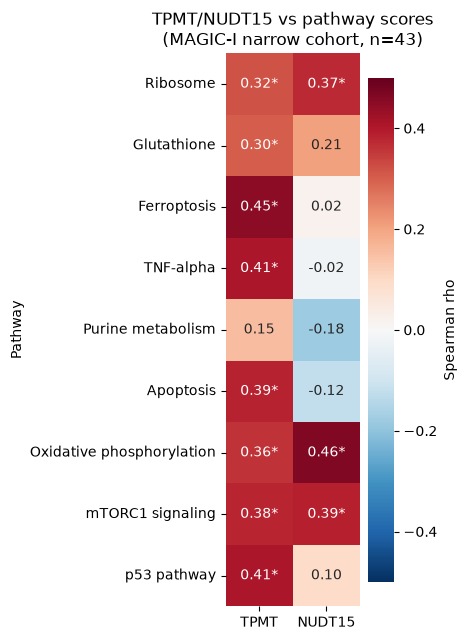

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pathway_labels = {
    'ribosome_score': 'Ribosome',
    'glutathione_score': 'Glutathione',
    'ferroptosis_score': 'Ferroptosis',
    'tnf_score': 'TNF-alpha',
    'purine_metabolism_score': 'Purine metabolism',
    'apoptosis_score': 'Apoptosis',
    'oxidative_phosphorylation_score': 'Oxidative phosphorylation',
    'mtorc1_signaling_score': 'mTORC1 signaling',
    'p53_pathway_score': 'p53 pathway'
}

corr_df.index = corr_df['Pathway'].map(pathway_labels)

corr_data = corr_df[['TPMT_rho', 'NUDT15_rho']].rename(columns={'TPMT_rho': 'TPMT', 'NUDT15_rho': 'NUDT15'})
pval_data = corr_df[['TPMT_p', 'NUDT15_p']].rename(columns={'TPMT_p': 'TPMT', 'NUDT15_p': 'NUDT15'})

annot = corr_data.round(2).astype(str)
for col in annot.columns:
    for idx in annot.index:
        star = "*" if pval_data.loc[idx, col] < 0.05 else ""
        annot.loc[idx, col] = f"{corr_data.loc[idx, col]:.2f}{star}"

fig, ax = plt.subplots(figsize=(4.5, 6.5))
sns.heatmap(corr_data, annot=annot, fmt="", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
            cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("TPMT/NUDT15 vs pathway scores\n(MAGIC-I narrow cohort, n=43)")

plt.tight_layout()
plt.savefig("magic_i_tpmt_nudt15_pathway_correlation_9.png", dpi=300, bbox_inches="tight")
plt.show()

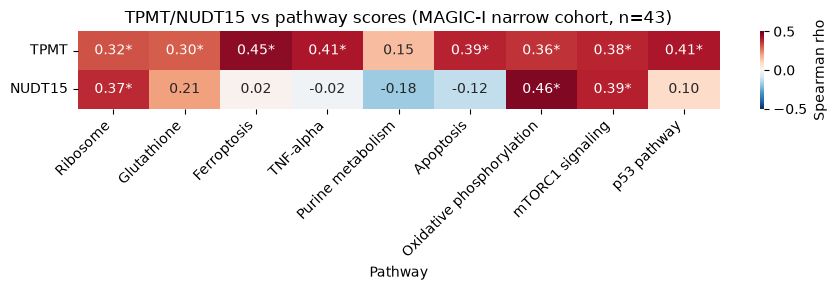

In [147]:
corr_data_h = corr_data.T
annot_h = annot.T

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(corr_data_h, annot=annot_h, fmt="", cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
            cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("TPMT/NUDT15 vs pathway scores (MAGIC-I narrow cohort, n=43)")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("magic_i_tpmt_nudt15_pathway_correlation_9_horizontal.png", dpi=300, bbox_inches="tight")
plt.show()

#### Subtype assignment and UMAP visualization (final QC pass, n=39) ####

In [149]:
ball_samples_list_valid = [s for s in ball_samples_list if s in subtype_scores_ball.index]
tall_samples_list_valid = [s for s in tall_samples_list if s in t_all_scores_tall.index]

print(f"B-ALL: {len(ball_samples_list)} in manifest, {len(ball_samples_list_valid)} with expression data")
print(f"T-ALL: {len(tall_samples_list)} in manifest, {len(tall_samples_list_valid)} with expression data")

ball_assignments = subtype_scores_ball.loc[ball_samples_list_valid, ['assigned_subtype']]
tall_assignments = t_all_scores_tall.loc[tall_samples_list_valid, ['assigned_subtype']]

all_assignments = pd.concat([ball_assignments, tall_assignments])
all_assignments.index.name = 'sample'
all_assignments = all_assignments.reset_index()

print("\nSubtype composition (MAGIC-I, marker-based):")
print(all_assignments['assigned_subtype'].value_counts())

B-ALL: 31 in manifest, 31 with expression data
T-ALL: 11 in manifest, 11 with expression data

Subtype composition (MAGIC-I, marker-based):
assigned_subtype
High Hyperdiploid    12
TLX3                  7
PAX5alt               6
TCF3::PBX1            5
Ph-like               3
DUX4-rearranged       3
ETV6::RUNX1           2
TLX1                  1
Immature/ETP          1
HOXA                  1
NKX2-1                1
Name: count, dtype: int64


In [150]:
all_assignments = all_assignments.merge(
    full_df[['sample', 'mrd_status', 'TPMT_vst', 'NUDT15_vst']],
    on='sample', how='left'
)

print("Matched with MRD/expression data:", all_assignments['mrd_status'].notna().sum(), "of", len(all_assignments))

# MRD status by subtype (only subtypes with n>=3 to avoid meaningless small-group tests)
subtype_counts = all_assignments['assigned_subtype'].value_counts()
adequate_subtypes = subtype_counts[subtype_counts >= 3].index

print("\nMRD+ rate by subtype (n>=3 only):")
for sub in adequate_subtypes:
    sub_df = all_assignments[all_assignments['assigned_subtype'] == sub]
    n_pos = (sub_df['mrd_status'] == 'positive').sum()
    n_total = sub_df['mrd_status'].notna().sum()
    print(f"{sub}: {n_pos}/{n_total} MRD+")

# TPMT/NUDT15 by subtype (Kruskal-Wallis across adequate subtypes)
from scipy.stats import kruskal
groups_tpmt = [all_assignments[all_assignments['assigned_subtype']==s]['TPMT_vst'].dropna() for s in adequate_subtypes]
stat, p = kruskal(*groups_tpmt)
print(f"\nTPMT by subtype (Kruskal-Wallis, n>=3 subtypes): p={p:.4f}")

groups_nudt15 = [all_assignments[all_assignments['assigned_subtype']==s]['NUDT15_vst'].dropna() for s in adequate_subtypes]
stat, p = kruskal(*groups_nudt15)
print(f"NUDT15 by subtype (Kruskal-Wallis, n>=3 subtypes): p={p:.4f}")

Matched with MRD/expression data: 39 of 42

MRD+ rate by subtype (n>=3 only):
High Hyperdiploid: 4/12 MRD+
TLX3: 6/6 MRD+
PAX5alt: 1/6 MRD+
TCF3::PBX1: 0/4 MRD+
Ph-like: 1/3 MRD+
DUX4-rearranged: 1/3 MRD+

TPMT by subtype (Kruskal-Wallis, n>=3 subtypes): p=0.5913
NUDT15 by subtype (Kruskal-Wallis, n>=3 subtypes): p=0.3896


/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/Meralle/PyCharmMiscProject/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


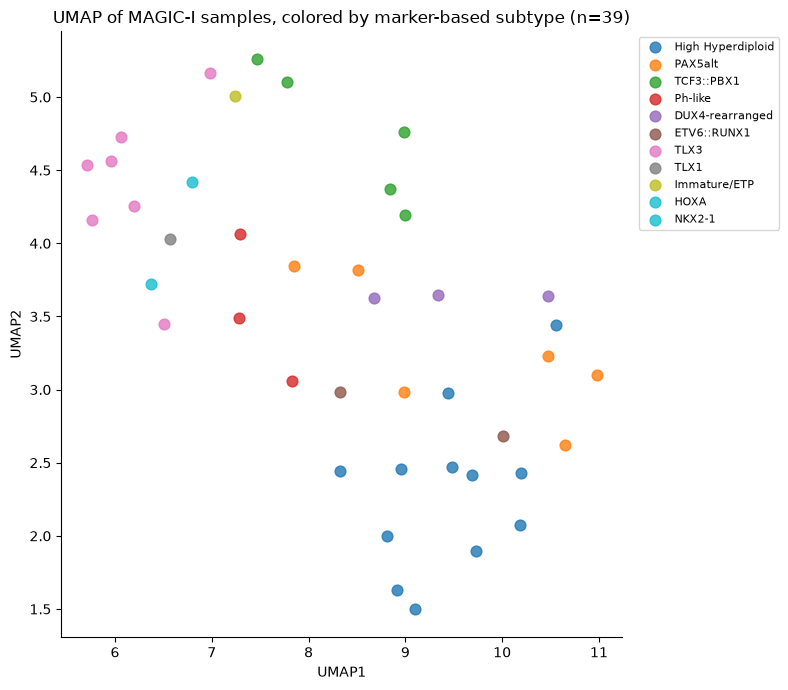

In [151]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Top-variance genes, same approach as TARGET
top_var_genes = vst_df.var(axis=0).sort_values(ascending=False).head(2000).index
X = vst_df.loc[all_assignments['sample'], top_var_genes]

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

subtypes_unique = all_assignments['assigned_subtype'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(subtypes_unique)))
color_map = dict(zip(subtypes_unique, colors))

fig, ax = plt.subplots(figsize=(8, 7))
for sub in subtypes_unique:
    mask = all_assignments['assigned_subtype'] == sub
    ax.scatter(embedding[mask.values, 0], embedding[mask.values, 1],
               label=sub, color=color_map[sub], s=60, alpha=0.8)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP of MAGIC-I samples, colored by marker-based subtype (n=39)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("magic_i_umap_subtype.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

mrd_colors = {"positive": "#d73027", "negative": "#4575b4"}
for status in ["negative", "positive"]:
    mask = all_assignments['mrd_status'] == status
    ax.scatter(embedding[mask.values, 0], embedding[mask.values, 1],
               label=f"MRD {'+' if status=='positive' else '−'}",
               color=mrd_colors[status], s=60, alpha=0.8)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP of MAGIC-I samples, colored by MRD status (n=39)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("magic_i_umap_mrd.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# Left panel: subtype
ax = axes[0]
for sub in subtypes_unique:
    mask = all_assignments['assigned_subtype'] == sub
    ax.scatter(embedding[mask.values, 0], embedding[mask.values, 1],
               label=sub, color=color_map[sub], s=60, alpha=0.8)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("Colored by subtype")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Right panel: MRD status
ax = axes[1]
mrd_colors = {"positive": "#d73027", "negative": "#4575b4"}
for status in ["negative", "positive"]:
    mask = all_assignments['mrd_status'] == status
    ax.scatter(embedding[mask.values, 0], embedding[mask.values, 1],
               label=f"MRD {'+' if status=='positive' else '−'}",
               color=mrd_colors[status], s=60, alpha=0.8)
ax.set_xlabel("UMAP1")
ax.set_title("Colored by MRD status")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle("UMAP of MAGIC-I samples (n=39)", y=1.02)
plt.tight_layout()
plt.savefig("magic_i_umap_combined.png", dpi=300, bbox_inches="tight")
plt.show()